In [12]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [13]:

import pandas as pd
import pandas_gbq
from google.oauth2 import service_account

from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = 'google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'coral-bucksaw-482803-p2'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [14]:

# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [ 
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    IsRootEvent,
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401
  AND IsRootEvent = 1
  AND ActionGeo_Type IN (3, 4, 5)
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})

"""
df = pandas_gbq.read_gbq(
    query,
    project_id=project_id,
    credentials=credentials,
    progress_bar_type='tqdm'   # 진행률 표시
)

print(f"총 {len(df):,}건 수집 완료")
display(df.head())


Downloading: 100%|██████████|
총 11,937건 수집 완료


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20230121,1,192,-9.5,10,-0.840336,4,39.9289,116.3880,https://www.shanghaisun.com/news/273404777/tai...
1,20220612,1,192,-9.5,2,-5.449190,4,39.9289,116.3880,https://www.news24.com/news24/World/News/we-wi...
2,20220612,1,190,-10.0,8,-4.689480,3,38.8951,-77.0364,https://www.mvariety.com/news/us-and-allies-tr...
3,20220612,1,202,-10.0,8,-6.225681,4,39.9044,116.3910,https://focustaiwan.tw/society/202206120012
4,20220612,1,190,-10.0,10,-3.930717,4,39.9289,116.3880,https://www.sbs.com.au/news/article/richard-ma...


In [15]:
import pandas as pd

# 기본 파악
print("shape:", df.shape)
print("\n결측값 비율(%)")
print((df.isnull().mean() * 100).round(2))

# 날짜 변환
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
print("\n날짜 범위:", df['SQLDATE'].min(), "~", df['SQLDATE'].max())

# 연도별 분포
df['year'] = df['SQLDATE'].dt.year
print("\n연도별 이벤트 수")
print(df['year'].value_counts().sort_index())

shape: (11937, 10)

결측값 비율(%)
SQLDATE           0.0
IsRootEvent       0.0
EventCode         0.0
GoldsteinScale    0.0
NumMentions       0.0
AvgTone           0.0
ActionGeo_Type    0.0
ActionGeo_Lat     0.0
ActionGeo_Long    0.0
SOURCEURL         0.0
dtype: float64

날짜 범위: 2013-04-01 00:00:00 ~ 2026-05-12 00:00:00

연도별 이벤트 수
year
2013      68
2014     375
2015     481
2016     509
2017     435
2018     705
2019     540
2020    1055
2021    1279
2022    2126
2023    1758
2024    1314
2025    1040
2026     252
Name: count, dtype: int64


### 결과 분석
-----------------------------
#### 데이터 크기 변화
- 필터링 전  →  493,109개
- 필터링 후  →   11,897개

약 41분의 1로 줄어듦

=> 이게 왜 좋은 거냐면
    - 493,109개  →  군사/비군사 이벤트 전부 섞여있음
    - 11,897개  →  실제 위성 촬영이 필요한 고위험 군사 이벤트만
노이즈 없이 핵심만 남은 상태!

-------------------------
####  결측값
모든 컬럼 0.0%  →  완벽한 데이터 품질 ✅
ActionGeo_Lat/Long도 0%  →  전체 좌표 사용 가능!

=> ActionGeo_Type을 3,4,5로 필터링한 덕분이에요. 좌표가 특정된 이벤트만 남겼으니까



연도별 이벤트 수 보기 — 전체를 못 봤음


In [16]:
# 전체 연도 다 보기
print(df['year'].value_counts().sort_index().to_string())

year
2013      68
2014     375
2015     481
2016     509
2017     435
2018     705
2019     540
2020    1055
2021    1279
2022    2126
2023    1758
2024    1314
2025    1040
2026     252


In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지

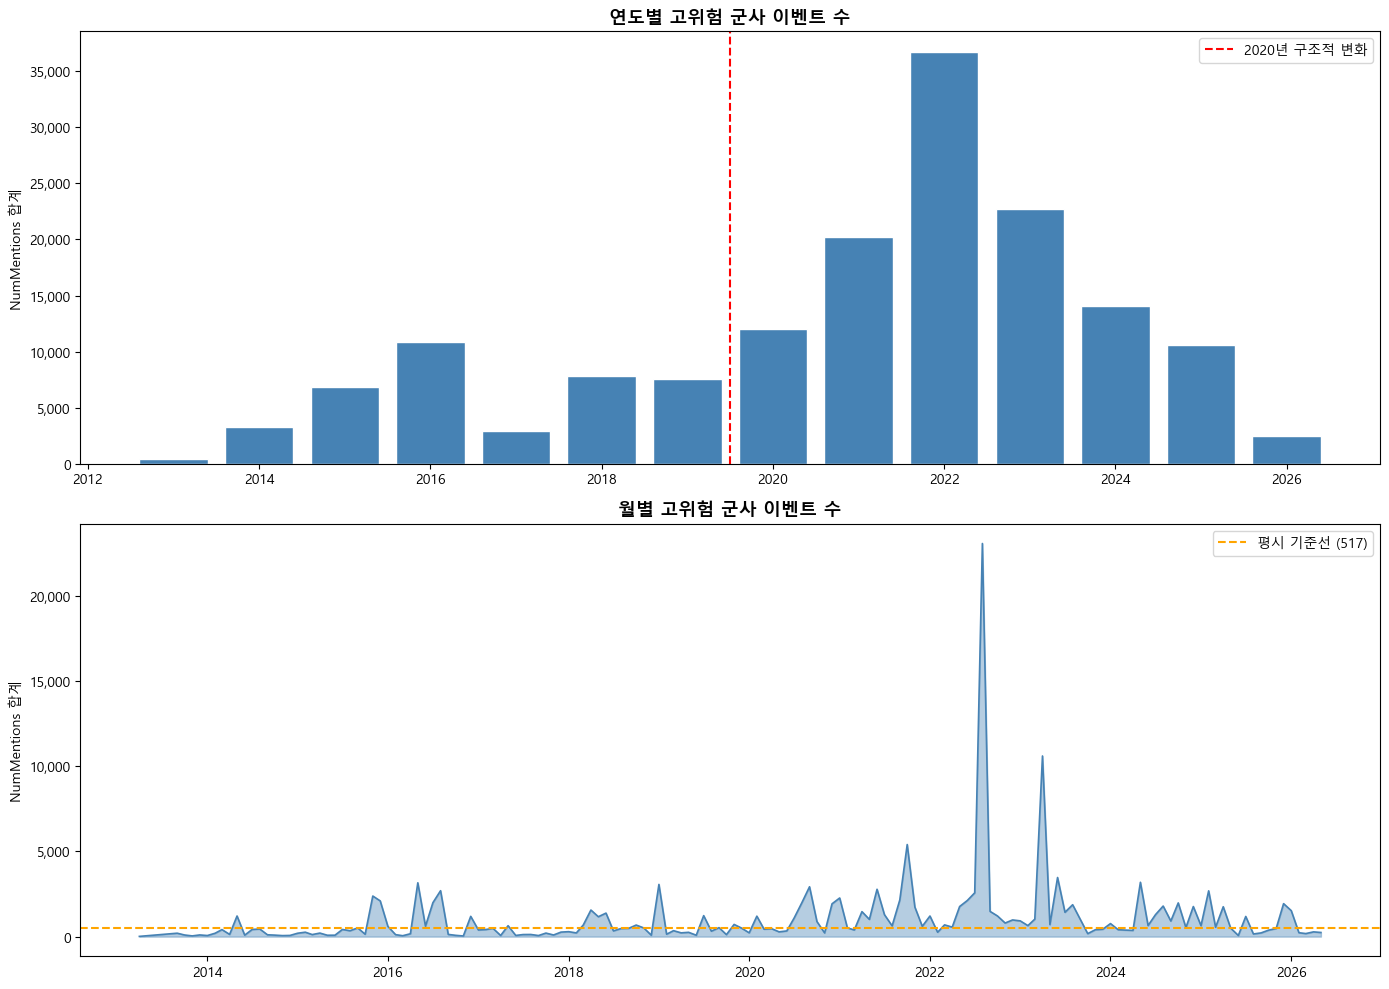

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 연도별 막대그래프
yearly = df.groupby('year')['NumMentions'].sum()
axes[0].bar(yearly.index, yearly.values, color='steelblue', edgecolor='white')
axes[0].set_title('연도별 고위험 군사 이벤트 수', fontsize=13, fontweight='bold')
axes[0].set_ylabel('NumMentions 합계')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2020년 변곡점 표시
axes[0].axvline(2019.5, color='red', linestyle='--', linewidth=1.5,
                label='2020년 구조적 변화')
axes[0].legend()

# 월별 추이
monthly = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    event_count=('NumMentions', 'sum'),
    avg_tone=('AvgTone', 'mean'),
    avg_goldstein=('GoldsteinScale', 'mean')
).reset_index()
monthly['SQLDATE'] = monthly['SQLDATE'].dt.to_timestamp()

axes[1].fill_between(monthly['SQLDATE'], monthly['event_count'],
                     alpha=0.4, color='steelblue')
axes[1].plot(monthly['SQLDATE'], monthly['event_count'],
             color='steelblue', linewidth=1.2)
axes[1].set_title('월별 고위험 군사 이벤트 수', fontsize=13, fontweight='bold')
axes[1].set_ylabel('NumMentions 합계')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 평시 베이스라인
baseline = monthly[monthly['SQLDATE'].dt.year <= 2019]['event_count'].mean()
axes[1].axhline(baseline, color='orange', linestyle='--',
                linewidth=1.5, label=f'평시 기준선 ({baseline:,.0f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('yearly_monthly_military.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# 시기별 기준선 분리
baseline_평시 = monthly[monthly['SQLDATE'].dt.year <= 2019]['event_count'].mean()
baseline_고긴장 = monthly[monthly['SQLDATE'].dt.year >= 2020]['event_count'].mean()

print(f"평시 기준선    (2013~2019): {baseline_평시:,.0f}")
print(f"고긴장 기준선  (2020~현재): {baseline_고긴장:,.0f}")

평시 기준선    (2013~2019): 517
고긴장 기준선  (2020~현재): 1,542


In [20]:
#스파이크 구간 상위 달 뽑아서 실제 사건과 매칭
spike_months = monthly.nlargest(10, 'event_count')[
    ['SQLDATE', 'event_count', 'avg_tone', 'avg_goldstein']
]
print(spike_months.to_string())

       SQLDATE  event_count  avg_tone  avg_goldstein
108 2022-08-01        23078 -3.142868      -8.612011
116 2023-04-01        10605 -2.522508      -8.611544
98  2021-10-01         5406 -3.036479      -8.756319
118 2023-06-01         3470 -1.677170      -8.512903
129 2024-05-01         3190 -3.218391      -8.297585
33  2016-05-01         3160 -2.250831      -9.128889
65  2019-01-01         3065 -2.123305      -9.176471
85  2020-09-01         2927 -3.248840      -8.956710
94  2021-06-01         2780 -2.396139      -8.727619
36  2016-08-01         2696 -2.292392      -9.522034


In [21]:
# 기준선 적용
baseline_평시   = 517
baseline_고긴장 = 1538

monthly['baseline'] = monthly['SQLDATE'].apply(
    lambda x: baseline_평시 if x.year <= 2019 else baseline_고긴장
)
monthly['spike_ratio'] = monthly['event_count'] / monthly['baseline']

def classify_spike(ratio):
    if ratio >= 5:   return '🔴 위험 (5배 이상)'
    elif ratio >= 3: return '🟠 경계 (3~5배)'
    elif ratio >= 2: return '🟡 주의 (2~3배)'
    else:            return '🟢 정상'

monthly['spike_grade'] = monthly['spike_ratio'].apply(classify_spike)

# spike_ratio 기준 상위 15개
print(monthly.nlargest(15, 'spike_ratio')[[
    'SQLDATE', 'event_count', 'baseline',
    'spike_ratio', 'spike_grade',
    'avg_tone', 'avg_goldstein'
]].to_string())

       SQLDATE  event_count  baseline  spike_ratio   spike_grade  avg_tone  avg_goldstein
108 2022-08-01        23078      1538    15.005202  🔴 위험 (5배 이상) -3.142868      -8.612011
116 2023-04-01        10605      1538     6.895319  🔴 위험 (5배 이상) -2.522508      -8.611544
33  2016-05-01         3160       517     6.112186  🔴 위험 (5배 이상) -2.250831      -9.128889
65  2019-01-01         3065       517     5.928433  🔴 위험 (5배 이상) -2.123305      -9.176471
36  2016-08-01         2696       517       5.2147  🔴 위험 (5배 이상) -2.292392      -9.522034
27  2015-11-01         2383       517     4.609284   🟠 경계 (3~5배) -1.043371      -9.700000
28  2015-12-01         2097       517     4.056093   🟠 경계 (3~5배) -2.160084      -8.942697
35  2016-07-01         1992       517     3.852998   🟠 경계 (3~5배) -4.125726      -9.697638
98  2021-10-01         5406      1538     3.514954   🟠 경계 (3~5배) -3.036479      -8.756319
56  2018-04-01         1561       517     3.019342   🟠 경계 (3~5배) -2.433789      -8.237037
58  2018-0

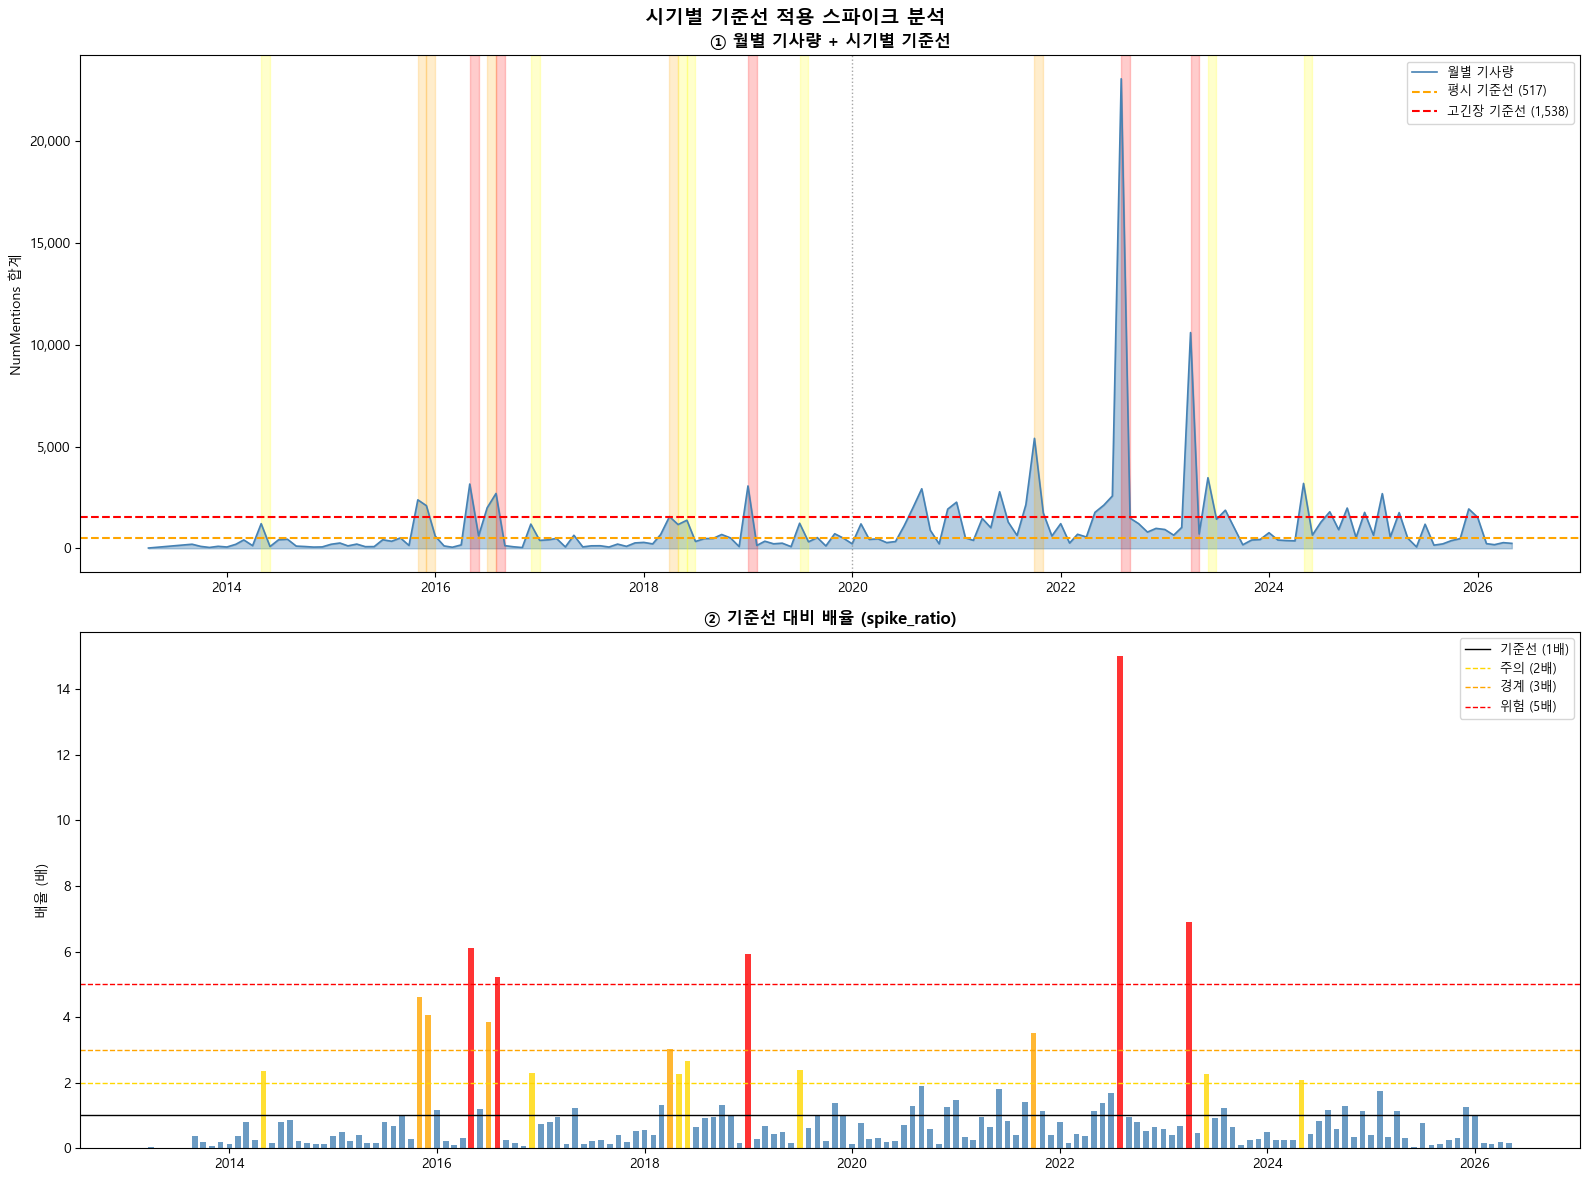

In [22]:
# ── 시각화 ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('시기별 기준선 적용 스파이크 분석', fontsize=14, fontweight='bold')

# 그래프 ① 기사량 + 시기별 기준선
ax = axes[0]
ax.fill_between(monthly['SQLDATE'], monthly['event_count'],
                alpha=0.4, color='steelblue')
ax.plot(monthly['SQLDATE'], monthly['event_count'],
        color='steelblue', linewidth=1.2, label='월별 기사량')

# 평시 기준선
ax.axhline(baseline_평시, color='orange', linestyle='--',
           linewidth=1.5, label=f'평시 기준선 ({baseline_평시:,})')

# 고긴장 기준선 (2020년부터)
ax.axvline(pd.Timestamp('2020-01-01'), color='gray',
           linestyle=':', linewidth=1, alpha=0.7)
ax.axhline(baseline_고긴장, color='red', linestyle='--',
           linewidth=1.5, label=f'고긴장 기준선 ({baseline_고긴장:,})')

# 스파이크 등급별 색상 표시
colors = {
    '🔴 위험 (5배 이상)': 'red',
    '🟠 경계 (3~5배)':   'orange',
    '🟡 주의 (2~3배)':   'yellow',
}
for _, row in monthly[monthly['spike_grade'] != '🟢 정상'].iterrows():
    color = colors.get(row['spike_grade'], 'gray')
    ax.axvspan(row['SQLDATE'],
               row['SQLDATE'] + pd.DateOffset(months=1),
               alpha=0.2, color=color)

ax.set_title('① 월별 기사량 + 시기별 기준선', fontweight='bold')
ax.set_ylabel('NumMentions 합계')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)

# 그래프 ② 기준선 대비 배율
ax = axes[1]
bar_colors = monthly['spike_grade'].apply(lambda x:
    'red'    if '위험' in x else
    'orange' if '경계' in x else
    'gold'   if '주의' in x else
    'steelblue'
)
ax.bar(monthly['SQLDATE'], monthly['spike_ratio'],
       color=bar_colors, width=20, alpha=0.8)
ax.axhline(1, color='black', linewidth=1, label='기준선 (1배)')
ax.axhline(2, color='gold',   linestyle='--', linewidth=1, label='주의 (2배)')
ax.axhline(3, color='orange', linestyle='--', linewidth=1, label='경계 (3배)')
ax.axhline(5, color='red',    linestyle='--', linewidth=1, label='위험 (5배)')

ax.set_title('② 기준선 대비 배율 (spike_ratio)', fontweight='bold')
ax.set_ylabel('배율 (배)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('spike_grade_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
may_2014 = df[df['SQLDATE'].dt.to_period('M') == '2014-05'][[
    'SQLDATE', 'EventCode', 'NumMentions',
    'AvgTone', 'GoldsteinScale', 'SOURCEURL'
]].sort_values('NumMentions', ascending=False)
print(may_2014.head(10).to_string())

         SQLDATE EventCode  NumMentions   AvgTone  GoldsteinScale                                                                                                                                                                                                      SOURCEURL
7824  2014-05-15       193          274  0.894269           -10.0                                                                                                         http://www.nation.com.pk/international/16-May-2014/up-to-21-dead-as-anti-china-riots-spread-in-vietnam
9077  2014-05-15       190          100  1.833158           -10.0                                                                                                                              http://www.geo.tv/article-147747-China-issues-Vietnam-tourist-warning-after-riots
7859  2014-05-16       190           94  1.942392           -10.0                                                                                              http://www.vancouversu

In [24]:
import matplotlib.pyplot as plt
import scipy.stats as sp_stats
import numpy as np
import seaborn as sns

# ── 데이터 준비 ──────────────────────────────────
# 월별 집계
monthly = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    event_count=('NumMentions', 'sum'),
    avg_tone=('AvgTone', 'mean'),
    avg_goldstein=('GoldsteinScale', 'mean')
).reset_index()
monthly['SQLDATE'] = monthly['SQLDATE'].dt.to_timestamp()
monthly['tone_delta'] = monthly['avg_tone'].diff()  # Tone 변화량

# ── 상관계수 출력 ─────────────────────────────────
pairs = [
    ('event_count', 'avg_tone',      '기사량 vs Tone'),
    ('event_count', 'avg_goldstein', '기사량 vs Goldstein'),
    ('avg_tone',    'avg_goldstein', 'Tone vs Goldstein'),
    ('event_count', 'tone_delta',    '기사량 vs Tone변화량'),
]

print("=" * 55)
print(f"{'조합':<25} {'상관계수':>8}  {'p-value':>10}  {'해석'}")
print("=" * 55)
for x_col, y_col, label in pairs:
    data = monthly[[x_col, y_col]].dropna()
    corr, p = sp_stats.pearsonr(data[x_col], data[y_col])
    
    # 해석
    if abs(corr) >= 0.6:
        interpret = "강한 상관 ⚠️"
    elif abs(corr) >= 0.3:
        interpret = "중간 상관"
    else:
        interpret = "약한 상관 ✅"
    
    sig = "유의" if p < 0.05 else "비유의"
    print(f"{label:<25} {corr:>8.3f}  {p:>10.4f}  {interpret} ({sig})")
print("=" * 55)

조합                            상관계수     p-value  해석
기사량 vs Tone                 -0.165      0.0406  약한 상관 ✅ (유의)
기사량 vs Goldstein             0.197      0.0146  약한 상관 ✅ (유의)
Tone vs Goldstein           -0.440      0.0000  중간 상관 (유의)
기사량 vs Tone변화량               0.005      0.9510  약한 상관 ✅ (비유의)


c:\Users\user\.conda\envs\sia_wevengers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Temp\ipykernel_378132\1772894448.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
c:\Users\user\.conda\envs\sia_wevengers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


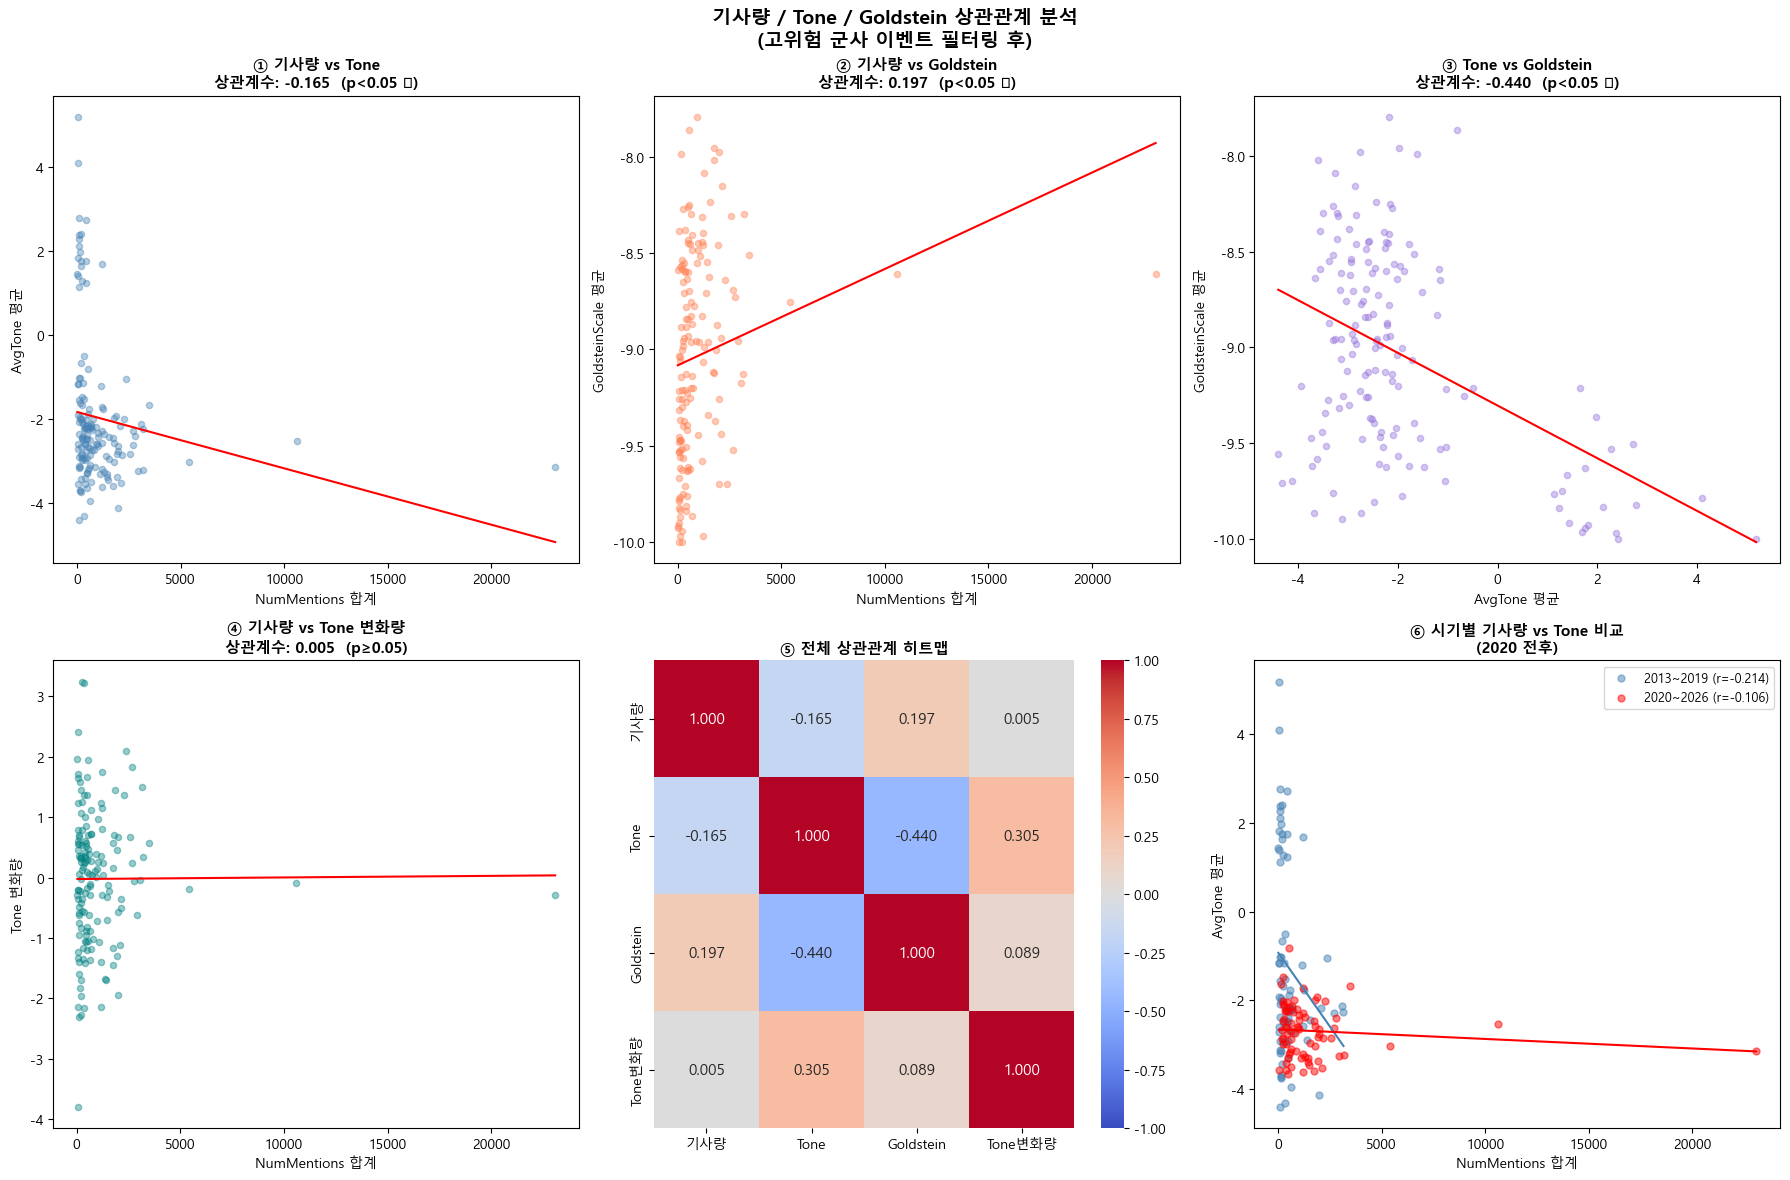

In [25]:
# ── 시각화 ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('기사량 / Tone / Goldstein 상관관계 분석\n(고위험 군사 이벤트 필터링 후)',
             fontsize=14, fontweight='bold')

plot_pairs = [
    # (x컬럼, y컬럼, x축 라벨, y축 라벨, 제목, 색상)
    ('event_count', 'avg_tone',
     'NumMentions 합계', 'AvgTone 평균',
     '① 기사량 vs Tone', 'steelblue'),

    ('event_count', 'avg_goldstein',
     'NumMentions 합계', 'GoldsteinScale 평균',
     '② 기사량 vs Goldstein', 'coral'),

    ('avg_tone', 'avg_goldstein',
     'AvgTone 평균', 'GoldsteinScale 평균',
     '③ Tone vs Goldstein', 'mediumpurple'),

    ('event_count', 'tone_delta',
     'NumMentions 합계', 'Tone 변화량',
     '④ 기사량 vs Tone 변화량', 'teal'),
]

for idx, (x_col, y_col, xlabel, ylabel, title, color) in enumerate(plot_pairs):
    row, col = divmod(idx, 3)
    ax = axes[row, col]

    data = monthly[[x_col, y_col]].dropna()
    corr, p = sp_stats.pearsonr(data[x_col], data[y_col])

    # 산점도
    ax.scatter(data[x_col], data[y_col],
               alpha=0.4, s=20, color=color)

    # 회귀선
    slope, intercept, *_ = sp_stats.linregress(data[x_col], data[y_col])
    x_line = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='red', linewidth=1.5)

    # 상관계수 표시
    sig_mark = "p<0.05 ✅" if p < 0.05 else "p≥0.05"
    ax.set_title(f'{title}\n상관계수: {corr:.3f}  ({sig_mark})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# ── 히트맵 (전체 상관관계 한눈에) ────────────────
ax = axes[1, 1]
corr_matrix = monthly[['event_count', 'avg_tone',
                        'avg_goldstein', 'tone_delta']].corr()
corr_matrix.index = ['기사량', 'Tone', 'Goldstein', 'Tone변화량']
corr_matrix.columns = ['기사량', 'Tone', 'Goldstein', 'Tone변화량']

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 11})
ax.set_title('⑤ 전체 상관관계 히트맵', fontsize=11, fontweight='bold')

# ── 시기별 상관관계 비교 (2020 전후) ─────────────
ax = axes[1, 2]
before = monthly[monthly['SQLDATE'].dt.year < 2020][['event_count', 'avg_tone']].dropna()
after  = monthly[monthly['SQLDATE'].dt.year >= 2020][['event_count', 'avg_tone']].dropna()

corr_before, _ = sp_stats.pearsonr(before['event_count'], before['avg_tone'])
corr_after,  _ = sp_stats.pearsonr(after['event_count'],  after['avg_tone'])

ax.scatter(before['event_count'], before['avg_tone'],
           alpha=0.5, s=25, color='steelblue', label=f'2013~2019 (r={corr_before:.3f})')
ax.scatter(after['event_count'],  after['avg_tone'],
           alpha=0.5, s=25, color='red',       label=f'2020~2026 (r={corr_after:.3f})')

# 각 시기별 회귀선
for data, color in [(before, 'steelblue'), (after, 'red')]:
    slope, intercept, *_ = sp_stats.linregress(data['event_count'], data['avg_tone'])
    x_line = np.linspace(data['event_count'].min(), data['event_count'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=1.5)

ax.set_title('⑥ 시기별 기사량 vs Tone 비교\n(2020 전후)', fontsize=11, fontweight='bold')
ax.set_xlabel('NumMentions 합계')
ax.set_ylabel('AvgTone 평균')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
spike_months = monthly.nlargest(10, 'event_count')[
    ['SQLDATE', 'event_count', 'avg_tone', 'avg_goldstein']
]
print(spike_months.to_string())

       SQLDATE  event_count  avg_tone  avg_goldstein
108 2022-08-01        23078 -3.142868      -8.612011
116 2023-04-01        10605 -2.522508      -8.611544
98  2021-10-01         5406 -3.036479      -8.756319
118 2023-06-01         3470 -1.677170      -8.512903
129 2024-05-01         3190 -3.218391      -8.297585
33  2016-05-01         3160 -2.250831      -9.128889
65  2019-01-01         3065 -2.123305      -9.176471
85  2020-09-01         2927 -3.248840      -8.956710
94  2021-06-01         2780 -2.396139      -8.727619
36  2016-08-01         2696 -2.292392      -9.522034


In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ── 1. GeoWeight 매핑 ──────────────────────────────────────────────
GEO_WEIGHT_MAP = {
    # (lat_rounded, lon_rounded): weight
    (25.0, 121.5): 1.0,   # 타이베이 (총통부 인근)
    (24.0, 121.0): 1.0,   # 대만 본섬 중심 (난터우)
    (24.0, 119.0): 0.9,   # 대만해협 중간선
    (24.4, 118.3): 1.0,   # 진먼다오 (금문도)
    (21.4, 121.5): 0.8,   # 바시 해협 (대만 남단)
    (25.0, 121.3): 0.9,   # 타오위안 (국제공항 인근)
    (26.5, 117.8): 0.7,   # 푸젠성 (싼밍 인근)
    (24.1, 113.0): 0.7,   # 광둥성 칭위안
    (39.9, 116.4): 0.5,   # 베이징 (중남해)
    (31.2, 121.5): 0.5,   # 상하이
    (41.0, 123.0): 0.4,   # 랴오닝성 (안산/랴오양)
    (38.9, -77.0): 0.3,   # 워싱턴 D.C. (백악관)
    (35.7, 139.8): 0.2,   # 도쿄
    (15.0, 115.0): 0.5,   # 남중국해 중심부
}
DEFAULT_GEO_WEIGHT = 0.1

def get_geo_weight(lat, lon, precision=1):
    key = (round(lat, precision), round(lon, precision))
    return GEO_WEIGHT_MAP.get(key, DEFAULT_GEO_WEIGHT)

# ── 2. 피처 전처리 ────────────────────────────────────────────────
def preprocess_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Volume: log 변환 (0건 포함 대응)
    df["vol_log"] = np.log1p(df["NumMentions"])

    # Goldstein: 음수=강경 → 절댓값 (범위 약 0~10)
    df["gold_abs"] = df["GoldsteinScale"].abs()

    # AvgTone: 부정=적대적 → 절댓값
    df["tone_abs"] = df["AvgTone"].abs()

    # GeoWeight: 좌표 기반 매핑
    df["geo_weight"] = df.apply(
        lambda r: get_geo_weight(r["ActionGeo_Lat"], r["ActionGeo_Long"]),
        axis=1,
    )
    return df

# ── 3. MinMax 정규화 ──────────────────────────────────────────────
FEATURE_COLS = ["vol_log", "gold_abs", "tone_abs", "geo_weight"]

def normalize_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    scaler = MinMaxScaler()
    df[FEATURE_COLS] = scaler.fit_transform(df[FEATURE_COLS])
    return df

# ── 4. 가중합 스코어 산출 ─────────────────────────────────────────
WEIGHTS = {
    "vol_log":    0.40,   # Volume 가중치
    "gold_abs":   0.20,   # Goldstein 가중치
    "tone_abs":   0.20,   # AvgTone 가중치
    "geo_weight": 0.20,   # GeoWeight 가중치
}

def compute_importance_score(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["importance_score"] = sum(
        WEIGHTS[col] * df[col] for col in FEATURE_COLS
    )
    return df

# ── 5. Volume Floor 필터 ─────────────────────────────────────────
VOLUME_FLOOR = 100  # 상위 약 5% (EDA 분위수 기준)

def apply_volume_floor(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["NumMentions"] >= VOLUME_FLOOR].copy()

# ── 6. 전체 파이프라인 ────────────────────────────────────────────
def score_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    df = preprocess_features(df)
    df = normalize_features(df)
    df = compute_importance_score(df)
    df = apply_volume_floor(df)
    return df.sort_values("importance_score", ascending=False)

① Goldstein Scale 분포 (필터된 데이터 기준)

총 11,937건
count    11937.000
mean        -8.821
std          1.344
min        -10.000
25%        -10.000
50%        -10.000
75%         -7.200
max         -7.200

[분위수]
    1%: -10.000
    5%: -10.000
   10%: -10.000
   25%: -10.000
   50%: -10.000
   75%:  -7.200
   90%:  -7.200
   95%:  -7.200
   99%:  -7.200

IQR: 2.800  /  전체 범위: 2.800
IQR/Range = 100.00%  → 낮을수록 분포가 좁게 몰려 있음

[CAMEO 그룹별 Goldstein 평균·std]
                mean    std  count
cameo_group                       
교전 (190s)     -9.922  0.181   7047
군사 태세 (150s)  -7.200  0.000   4831
대규모 폭력 (200s) -9.983  0.091     59


C:\Users\user\AppData\Local\Temp\ipykernel_378132\1760132464.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(group_data, labels=[g.split("(")[0].strip() for g in group_order],


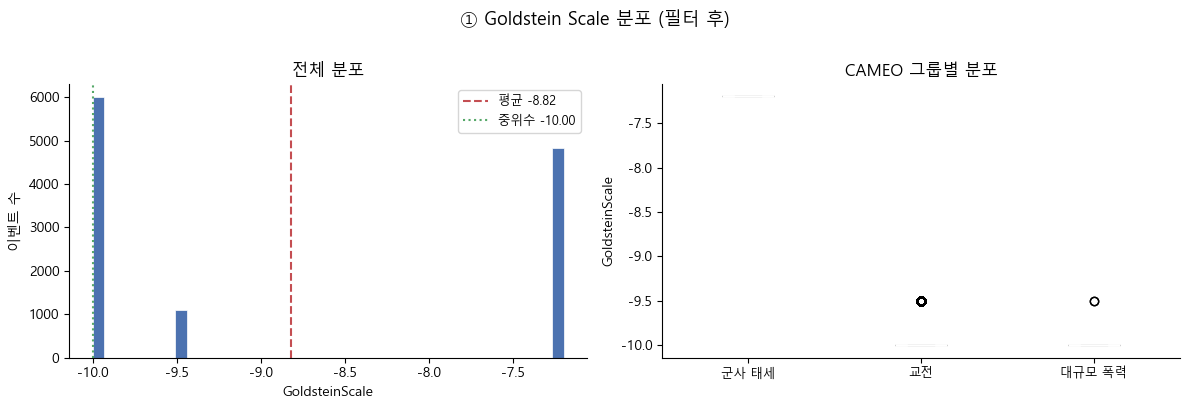

→ validate_01_goldstein_dist.png 저장

② Goldstein vs AvgTone 독립성 (필터 후 상관관계)

  Pearson  r = 0.0242  (p = 0.0082)
  Spearman r = 0.0395  (p = 0.0000)

  판정: ✓ 약한 상관 (|r|<0.3) → 두 피처 독립적, 스코어링에 함께 사용 근거 있음

[CAMEO 그룹별 Pearson r]
  군사 태세 (150s): r = nan  (p = nan, n=4,831)
  교전 (190s): r = 0.0290  (p = 0.0150, n=7,047)
  대규모 폭력 (200s): r = -0.0116  (p = 0.9302, n=59)


C:\Users\user\AppData\Local\Temp\ipykernel_378132\1760132464.py:162: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(sub["GoldsteinScale"], sub["AvgTone"])
C:\Users\user\AppData\Local\Temp\ipykernel_378132\1760132464.py:205: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(sub["GoldsteinScale"], sub["AvgTone"])


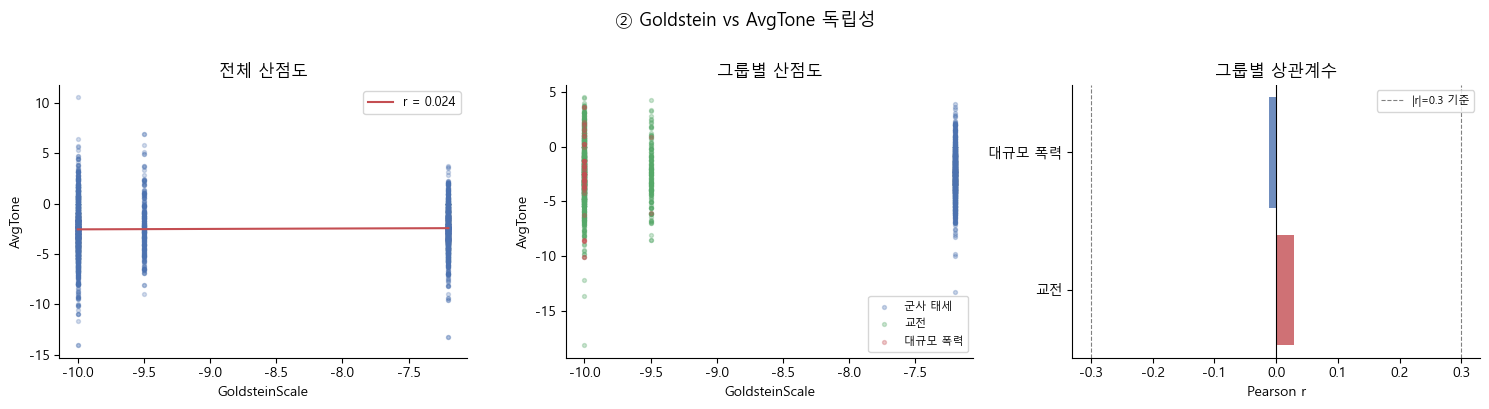

→ validate_02_correlation.png 저장

③ AvgTone 방향성 — CAMEO 코드 그룹별 분포

[CAMEO 그룹별 AvgTone 통계]
                mean  median    std  count
cameo_group                               
교전 (190s)     -2.548  -2.604  2.587   7047
군사 태세 (150s)  -2.442  -2.418  1.945   4831
대규모 폭력 (200s) -2.378  -2.535  3.135     59

[그룹별 부정 논조(AvgTone < 0) 비율]
  군사 태세 (150s): 88.9% 음수  |  음수일 때 평균 Tone: -2.850
  교전 (190s): 84.0% 음수  |  음수일 때 평균 Tone: -3.317
  대규모 폭력 (200s): 74.6% 음수  |  음수일 때 평균 Tone: -3.684

[EventCode별 AvgTone 평균 (군사 행동 세분화)]
  190: n=3,984  AvgTone 평균= -2.442  중위수= -2.457  Goldstein중위=-10.0
  191: n=  136  AvgTone 평균= -2.104  중위수= -2.902  Goldstein중위=-9.5
  192: n=  963  AvgTone 평균= -2.411  중위수= -2.416  Goldstein중위=-9.5
  193: n=  671  AvgTone 평균= -3.038  중위수= -3.592  Goldstein중위=-10.0
  194: n=  755  AvgTone 평균= -2.789  중위수= -2.929  Goldstein중위=-10.0
  195: n=  538  AvgTone 평균= -2.735  중위수= -2.572  Goldstein중위=-10.0
  201: n=    2  AvgTone 평균= -2.572  중위수= -2.572  Goldstein중위=-9.5
  202: n=   

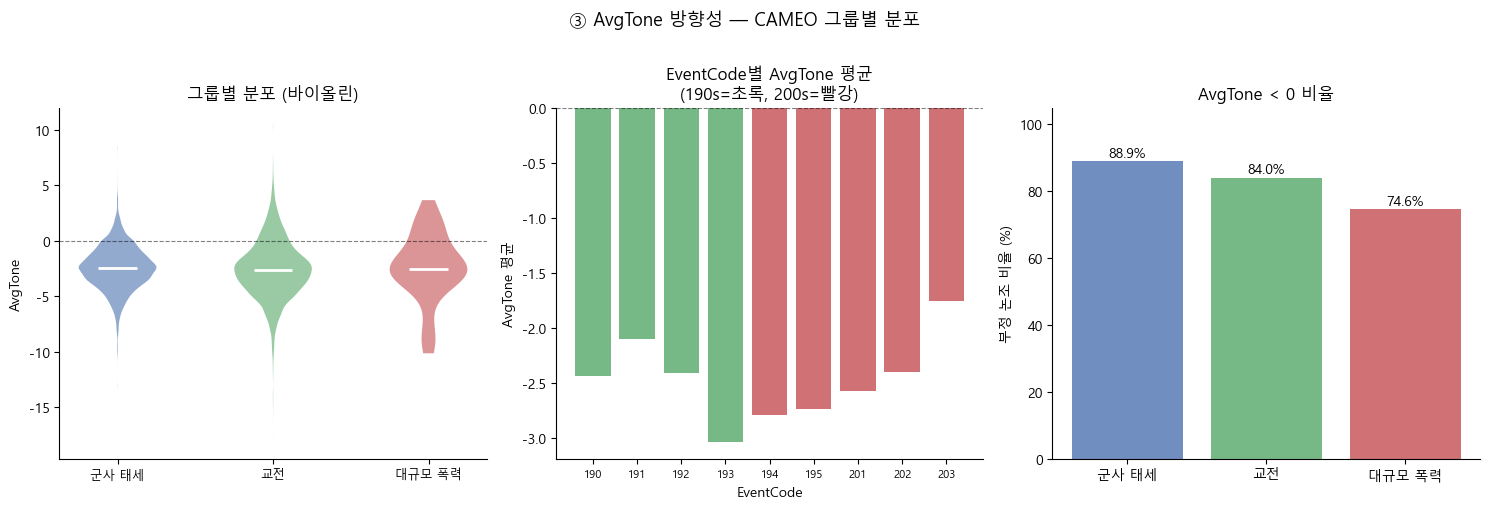

→ validate_03_tone_direction.png 저장

종합 판단 요약

① Goldstein 변별력
   - IQR/Range 비율이 작으면(<30%) 분포가 좁게 몰려 있어
     MinMax 정규화 전 log 또는 구간화(binning) 고려 필요

② Goldstein·Tone 독립성
   - |r| < 0.3 → 둘 다 스코어링 피처로 사용 정당
   - |r| ≥ 0.3 → 가중치를 한쪽에 더 줄 필요 있음

③ AvgTone 방향성
   - 단조 감소 확인 시: max(0, -AvgTone) 변환으로 부정 논조만 반영
   - 단조 감소 미확인 시: Goldstein 가중치 ↑, Tone 가중치 ↓ 조정 권고



In [28]:
"""
Goldstein·Tone 스코어링 피처 검증
df가 로컬에 있는 상태에서 바로 실행 가능

확인 항목
  ① Goldstein 변별력 — 필터된 데이터 안 분포
  ② Goldstein vs AvgTone 독립성 — 필터 후 상관관계
  ③ AvgTone 방향성 — CAMEO 코드 그룹별 Tone 분포
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
from scipy import stats

# ── 한글 폰트 설정 ───────────────────────────────────────────────
# Windows: 맑은 고딕 경로 직접 등록
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",       # Windows 맑은 고딕
    "C:/Windows/Fonts/NanumGothic.ttf",  # 나눔고딕 설치된 경우
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue

if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    # 폰트 파일을 못 찾으면 시스템에 등록된 한글 폰트 중 첫 번째 사용
    _kor_fonts = [f.name for f in fm.fontManager.ttflist
                  if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor_fonts:
        plt.rcParams["font.family"] = _kor_fonts[0]
    else:
        print("[경고] 한글 폰트를 찾지 못했습니다. 폰트 경로를 _FONT_CANDIDATES에 추가하세요.")

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# ── CAMEO 그룹 정의 ──────────────────────────────────────────────
CAMEO_GROUPS = {
    "군사 태세 (150s)": ["150", "151", "152", "153", "154", "155"],
    "교전 (190s)": ["190", "191", "192", "193", "194", "195", "196"],
    "대규모 폭력 (200s)": ["200", "201", "202", "203", "204"],
}

# EventCode를 str로 통일
df["EventCode"] = df["EventCode"].astype(str)

def assign_group(code):
    for grp, codes in CAMEO_GROUPS.items():
        if code in codes:
            return grp
    return "기타"

df["cameo_group"] = df["EventCode"].apply(assign_group)

# ════════════════════════════════════════════════════════════════
# ① Goldstein 변별력 — 분포 확인
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("① Goldstein Scale 분포 (필터된 데이터 기준)")
print("=" * 60)

gs = df["GoldsteinScale"].dropna()
print(f"\n총 {len(gs):,}건")
print(gs.describe().round(3).to_string())

q_vals = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print("\n[분위수]")
for q in q_vals:
    print(f"  {int(q*100):>3}%: {gs.quantile(q):>7.3f}")

# 변별력 지표: IQR 대비 전체 범위
iqr = gs.quantile(0.75) - gs.quantile(0.25)
total_range = gs.max() - gs.min()
print(f"\nIQR: {iqr:.3f}  /  전체 범위: {total_range:.3f}")
print(f"IQR/Range = {iqr/total_range:.2%}  → 낮을수록 분포가 좁게 몰려 있음")

# CAMEO 그룹별 Goldstein 통계
print("\n[CAMEO 그룹별 Goldstein 평균·std]")
print(
    df.groupby("cameo_group")["GoldsteinScale"]
    .agg(["mean", "std", "count"])
    .round(3)
    .to_string()
)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("① Goldstein Scale 분포 (필터 후)", fontsize=13, y=1.01)

# 전체 히스토그램
axes[0].hist(gs, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0].axvline(gs.mean(), color="#C44E52", linewidth=1.5, linestyle="--",
                label=f"평균 {gs.mean():.2f}")
axes[0].axvline(gs.median(), color="#55A868", linewidth=1.5, linestyle=":",
                label=f"중위수 {gs.median():.2f}")
axes[0].set_xlabel("GoldsteinScale")
axes[0].set_ylabel("이벤트 수")
axes[0].set_title("전체 분포")
axes[0].legend(fontsize=9)

# 그룹별 박스플롯
group_order = list(CAMEO_GROUPS.keys())
group_data = [df[df["cameo_group"] == g]["GoldsteinScale"].dropna()
              for g in group_order]
bp = axes[1].boxplot(group_data, labels=[g.split("(")[0].strip() for g in group_order],
                     patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
colors = ["#4C72B0", "#55A868", "#C44E52"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("GoldsteinScale")
axes[1].set_title("CAMEO 그룹별 분포")
axes[1].tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig("validate_01_goldstein_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ validate_01_goldstein_dist.png 저장\n")


# ════════════════════════════════════════════════════════════════
# ② Goldstein vs AvgTone 독립성
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("② Goldstein vs AvgTone 독립성 (필터 후 상관관계)")
print("=" * 60)

valid = df[["GoldsteinScale", "AvgTone"]].dropna()
r_pearson, p_pearson = stats.pearsonr(valid["GoldsteinScale"], valid["AvgTone"])
r_spearman, p_spearman = stats.spearmanr(valid["GoldsteinScale"], valid["AvgTone"])

print(f"\n  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.4f})")
print(f"  Spearman r = {r_spearman:.4f}  (p = {p_spearman:.4f})")

# 판정
threshold = 0.3
if abs(r_pearson) < threshold:
    verdict = f"✓ 약한 상관 (|r|<{threshold}) → 두 피처 독립적, 스코어링에 함께 사용 근거 있음"
else:
    verdict = f"△ 중간 이상 상관 (|r|≥{threshold}) → 중복 정보 가능성, 가중치 조정 필요"
print(f"\n  판정: {verdict}")

# 그룹별 상관도 추가 확인
print("\n[CAMEO 그룹별 Pearson r]")
for grp in group_order:
    sub = df[df["cameo_group"] == grp][["GoldsteinScale", "AvgTone"]].dropna()
    if len(sub) < 10:
        print(f"  {grp}: 데이터 부족 ({len(sub)}건)")
        continue
    r, p = stats.pearsonr(sub["GoldsteinScale"], sub["AvgTone"])
    print(f"  {grp}: r = {r:.4f}  (p = {p:.4f}, n={len(sub):,})")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("② Goldstein vs AvgTone 독립성", fontsize=13, y=1.01)

colors_grp = {"군사 태세 (150s)": "#4C72B0",
              "교전 (190s)": "#55A868",
              "대규모 폭력 (200s)": "#C44E52",
              "기타": "#888888"}

# 전체 산점도
sample = valid.sample(min(3000, len(valid)), random_state=42)
axes[0].scatter(sample["GoldsteinScale"], sample["AvgTone"],
                alpha=0.25, s=8, color="#4C72B0")
# 회귀선
m, b = np.polyfit(valid["GoldsteinScale"], valid["AvgTone"], 1)
x_line = np.linspace(valid["GoldsteinScale"].min(), valid["GoldsteinScale"].max(), 100)
axes[0].plot(x_line, m * x_line + b, color="#C44E52", linewidth=1.5,
             label=f"r = {r_pearson:.3f}")
axes[0].set_xlabel("GoldsteinScale")
axes[0].set_ylabel("AvgTone")
axes[0].set_title("전체 산점도")
axes[0].legend(fontsize=9)

# 그룹별 산점도
for grp in group_order:
    sub = df[df["cameo_group"] == grp].sample(
        min(1000, len(df[df["cameo_group"] == grp])), random_state=42)
    axes[1].scatter(sub["GoldsteinScale"], sub["AvgTone"],
                    alpha=0.3, s=8, color=colors_grp.get(grp, "#888"),
                    label=grp.split("(")[0].strip())
axes[1].set_xlabel("GoldsteinScale")
axes[1].set_ylabel("AvgTone")
axes[1].set_title("그룹별 산점도")
axes[1].legend(fontsize=8)

# 그룹별 상관계수 막대
grp_r = []
for grp in group_order:
    sub = df[df["cameo_group"] == grp][["GoldsteinScale", "AvgTone"]].dropna()
    if len(sub) >= 10:
        r, _ = stats.pearsonr(sub["GoldsteinScale"], sub["AvgTone"])
        grp_r.append((grp.split("(")[0].strip(), r))
labels_r, vals_r = zip(*grp_r)
bar_colors = ["#C44E52" if v >= 0 else "#4C72B0" for v in vals_r]
axes[2].barh(labels_r, vals_r, color=bar_colors, alpha=0.8)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].axvline(0.3, color="gray", linewidth=0.8, linestyle="--", label="|r|=0.3 기준")
axes[2].axvline(-0.3, color="gray", linewidth=0.8, linestyle="--")
axes[2].set_xlabel("Pearson r")
axes[2].set_title("그룹별 상관계수")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("validate_02_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ validate_02_correlation.png 저장\n")


# ════════════════════════════════════════════════════════════════
# ③ AvgTone 방향성 — CAMEO 그룹별 Tone 분포
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("③ AvgTone 방향성 — CAMEO 코드 그룹별 분포")
print("=" * 60)

# 그룹별 기술통계
print("\n[CAMEO 그룹별 AvgTone 통계]")
tone_stats = (
    df.groupby("cameo_group")["AvgTone"]
    .agg(["mean", "median", "std", "count"])
    .round(3)
)
print(tone_stats.to_string())

# 음수 비율 (부정 논조 비율)
print("\n[그룹별 부정 논조(AvgTone < 0) 비율]")
for grp in group_order:
    sub = df[df["cameo_group"] == grp]["AvgTone"].dropna()
    neg_ratio = (sub < 0).mean()
    mean_neg = sub[sub < 0].mean()
    print(f"  {grp}: {neg_ratio:.1%} 음수  |  음수일 때 평균 Tone: {mean_neg:.3f}")

# 개별 EventCode별 Tone (190s, 200s 세분화)
print("\n[EventCode별 AvgTone 평균 (군사 행동 세분화)]")
detail_codes = [c for c in df["EventCode"].unique()
                if c in [str(i) for i in range(190, 205)]]
detail_codes.sort()
for code in detail_codes:
    sub = df[df["EventCode"] == code]["AvgTone"].dropna()
    if len(sub) == 0:
        continue
    gs_val = df[df["EventCode"] == code]["GoldsteinScale"].median()
    print(f"  {code}: n={len(sub):>5,}  AvgTone 평균={sub.mean():>7.3f}  "
          f"중위수={sub.median():>7.3f}  Goldstein중위={gs_val:.1f}")

# 판정: Tone이 강도를 따라가는가
print("\n[판정: AvgTone이 군사 행동 강도를 따라가는가]")
group_mean_tone = {
    grp: df[df["cameo_group"] == grp]["AvgTone"].mean()
    for grp in group_order
}
tone_vals = list(group_mean_tone.values())
is_monotone = tone_vals[0] > tone_vals[1] > tone_vals[2]  # 위협 > 군사 > 무력
print(f"  군사 태세 평균: {tone_vals[0]:.3f}")
print(f"  교전 평균: {tone_vals[1]:.3f}")
print(f"  대규모 폭력 평균: {tone_vals[2]:.3f}")
if is_monotone:
    print("  ✓ 단조 감소 → Tone이 행동 강도를 따라가는 경향 있음, 스코어링 근거 확보")
else:
    print("  △ 단조 감소 아님 → Tone 단독 사용보다 Goldstein 병용 권고")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("③ AvgTone 방향성 — CAMEO 그룹별 분포", fontsize=13, y=1.01)

# 그룹별 바이올린 플롯
tone_data = [df[df["cameo_group"] == g]["AvgTone"].dropna() for g in group_order]
vp = axes[0].violinplot(tone_data, positions=range(len(group_order)),
                         showmedians=True, showextrema=False)
for i, (pc, color) in enumerate(zip(vp["bodies"], colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
vp["cmedians"].set_color("white")
vp["cmedians"].set_linewidth(2)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
axes[0].set_xticks(range(len(group_order)))
axes[0].set_xticklabels([g.split("(")[0].strip() for g in group_order], fontsize=9)
axes[0].set_ylabel("AvgTone")
axes[0].set_title("그룹별 분포 (바이올린)")

# EventCode별 평균 Tone (190s~204)
code_tone = []
for code in detail_codes:
    sub = df[df["EventCode"] == code]["AvgTone"].dropna()
    if len(sub) > 0:
        code_tone.append((code, sub.mean(), len(sub)))
codes_x, tones_y, sizes = zip(*code_tone)
bar_c = ["#55A868" if c in ["190","191","192","193"] else "#C44E52"
         for c in codes_x]
axes[1].bar(codes_x, tones_y, color=bar_c, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
axes[1].set_xlabel("EventCode")
axes[1].set_ylabel("AvgTone 평균")
axes[1].set_title("EventCode별 AvgTone 평균\n(190s=초록, 200s=빨강)")
axes[1].tick_params(axis="x", labelsize=8)

# 음수 논조 비율
neg_ratios = []
for grp in group_order:
    sub = df[df["cameo_group"] == grp]["AvgTone"].dropna()
    neg_ratios.append((sub < 0).mean() * 100)
bars = axes[2].bar([g.split("(")[0].strip() for g in group_order],
                   neg_ratios, color=colors, alpha=0.8)
for bar, val in zip(bars, neg_ratios):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5, f"{val:.1f}%",
                 ha="center", va="bottom", fontsize=10)
axes[2].set_ylabel("부정 논조 비율 (%)")
axes[2].set_title("AvgTone < 0 비율")
axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.savefig("validate_03_tone_direction.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ validate_03_tone_direction.png 저장\n")


# ════════════════════════════════════════════════════════════════
# 종합 판단 요약
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("종합 판단 요약")
print("=" * 60)
print("""
① Goldstein 변별력
   - IQR/Range 비율이 작으면(<30%) 분포가 좁게 몰려 있어
     MinMax 정규화 전 log 또는 구간화(binning) 고려 필요

② Goldstein·Tone 독립성
   - |r| < 0.3 → 둘 다 스코어링 피처로 사용 정당
   - |r| ≥ 0.3 → 가중치를 한쪽에 더 줄 필요 있음

③ AvgTone 방향성
   - 단조 감소 확인 시: max(0, -AvgTone) 변환으로 부정 논조만 반영
   - 단조 감소 미확인 시: Goldstein 가중치 ↑, Tone 가중치 ↓ 조정 권고
""")

② Vol 상위 날짜 vs Tone 상위 날짜 — 겹침 분석

  상위 30일 기준
  Vol·Tone 동시 상위:    0일  (0.0%)
  Vol만 상위:           30일
  Tone만 상위:          30일

[판정]
  ✓ 겹침 0% → Tone이 Vol과 다른 날을 포착, 독립 신호 있음

[Tone만 상위 30에 드는 날 — Vol은 낮은데 Tone이 강한 날]
   SQLDATE  NumMentions    AvgTone  threat_score  vol_norm  tone_norm
2016-09-11            8 -14.525140           0.6  0.194330   1.000000
2018-11-23            5 -14.012739           0.6  0.141943   0.964723
2016-07-05           10 -12.195122           0.6  0.220258   0.839587
2026-04-23           18 -10.328524           0.5  0.290872   0.711079
2019-07-23           14 -10.219780           0.6  0.260330   0.703593
2020-06-07           24 -10.127971           1.0  0.326330   0.697272
2025-09-22            1  -9.824561           0.6  0.000000   0.676383
2017-08-19           10  -9.593023           0.6  0.220258   0.660443
2023-10-08            4  -9.340659           0.6  0.118387   0.643068
2017-04-23           10  -9.328358           0.6  0.220258   0.642222

[Vol만 상위 

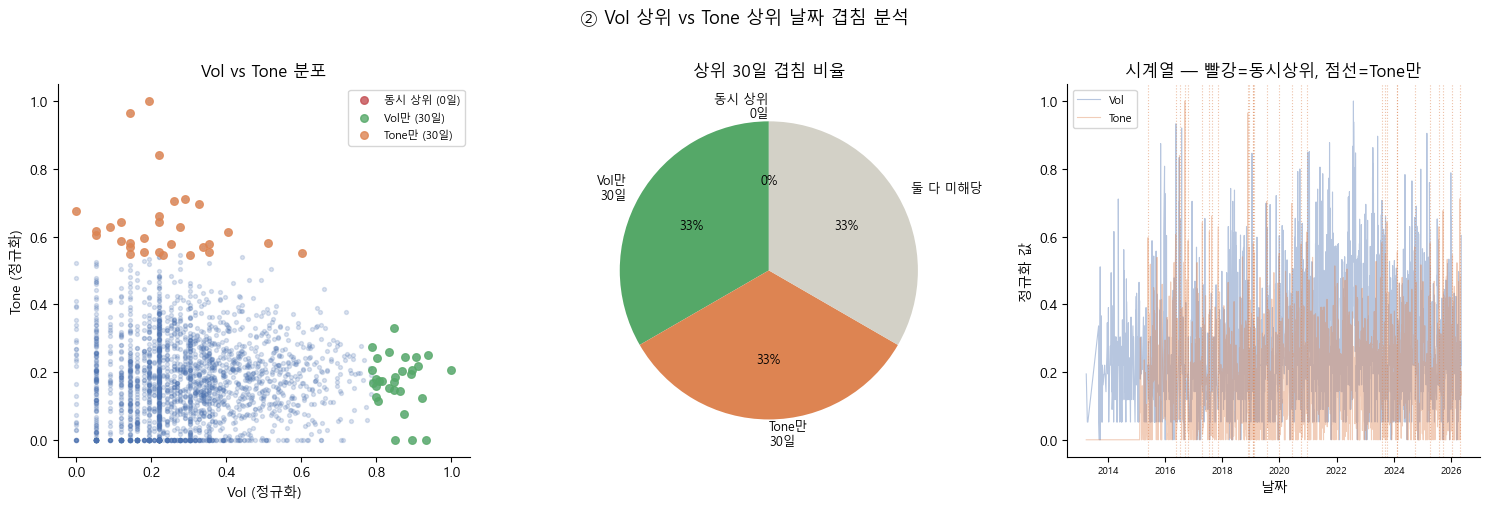

→ validate_tone_02_overlap.png 저장

③ Tone 유무에 따른 스코어 상위 날짜 순위 변화

[Tone 포함 스코어 상위 30일]
   SQLDATE  NumMentions    AvgTone  threat_score  score_no_tone  score_with_tone  rank_no_tone  rank_with_tone  rank_change
2016-07-01         1263  -3.755478      0.825000       0.650981         0.619370             1               1            0
2024-08-20          740  -2.583954      0.900000       0.644607         0.603764             3               2            1
2025-02-27         2197  -3.534473      0.703125       0.641020         0.599217             4               3            1
2022-08-31         1402  -4.777973      0.693103       0.608260         0.589380            11               4            7
2022-08-04         4595  -2.999587      0.586275       0.644853         0.586155             2               5           -3
2019-01-16         1391  -2.135421      0.775000       0.638462         0.583298             5               6           -1
2021-05-04          613  -1.269817      0.900

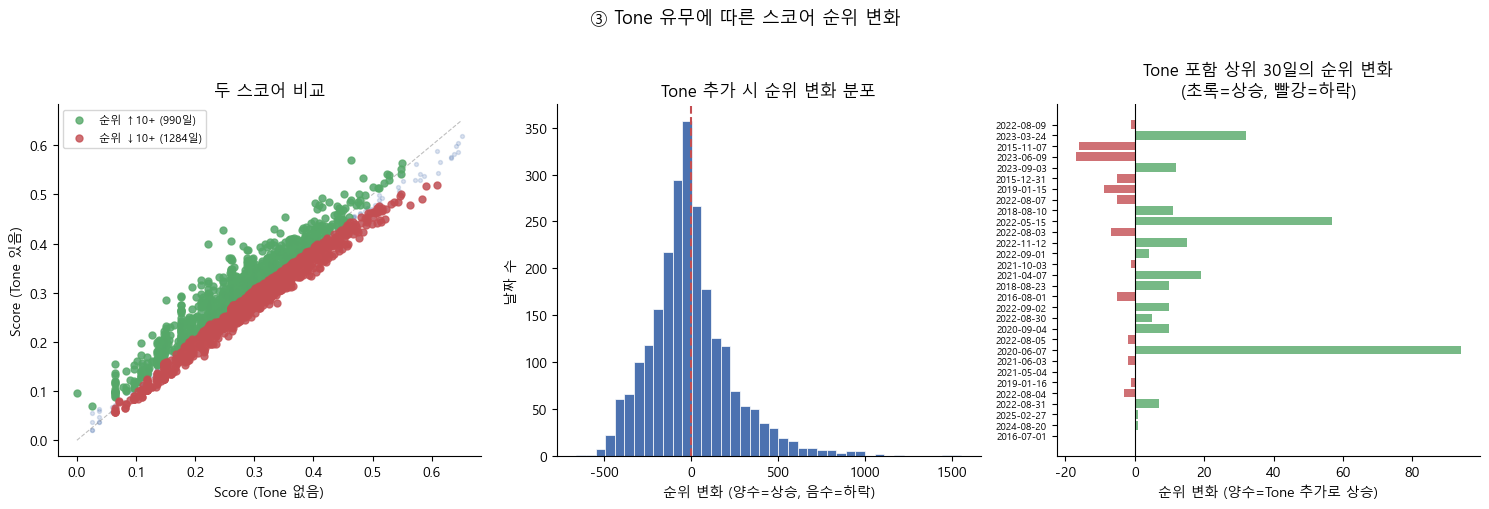

→ validate_tone_03_rank_change.png 저장

종합 판단 요약

② Vol·Tone 겹침 분석
   - 겹침 비율 낮음 (<40%) → Tone이 독립 신호, 넣는 게 맞음
   - 겹침 비율 높음 (>70%) → Tone은 Vol의 중복, 제거 고려
   - "Tone만 상위" 날들의 AvgTone·NumMentions 패턴 확인 필요

③ 순위 변화 분석
   - Jaccard 높음 (>0.85) → Tone 기여 미미, 가중치 낮추거나 제거
   - Jaccard 낮음 (<0.65) → Tone이 상위 목록 바꿈, 유의미한 기여
   - 순위 크게 상승한 날 = "기사는 적은데 Tone이 강한 날" 확인
     → 이 케이스가 실제 군사 이벤트와 일치하면 Tone 유지 근거
     → 노이즈성 날짜라면 Tone 제거 또는 가중치 0.1로 축소 권고



In [29]:
"""
AvgTone 필요성 검증
df가 로컬에 있는 상태에서 바로 실행 가능

확인 항목
  ② Vol 상위 날짜 vs Tone 상위 날짜 — 겹치는가 (독립 신호인가)
  ③ Tone 유무에 따른 스코어 상위 날짜 순위 변화 — 실질 기여 측정
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.preprocessing import MinMaxScaler

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue

if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor_fonts = [f.name for f in fm.fontManager.ttflist
                  if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor_fonts:
        plt.rcParams["font.family"] = _kor_fonts[0]

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# ── CAMEO threat_score 매핑 ──────────────────────────────────────
CAMEO_THREAT_SCORE = {
    "150": 0.3, "151": 0.2, "152": 0.4,
    "153": 0.3, "154": 0.5, "155": 0.2,
    "190": 0.6, "191": 0.6, "192": 0.7,
    "193": 0.9, "194": 0.9, "195": 0.8, "196": 0.7,
    "200": 0.8, "201": 0.7, "202": 1.0,
    "203": 1.0, "204": 1.0,
}

df["EventCode"] = df["EventCode"].astype(str)
df["threat_score_raw"] = df["EventCode"].map(CAMEO_THREAT_SCORE).fillna(0.3)

# ── 일별 집계 ────────────────────────────────────────────────────

daily = df.groupby("SQLDATE").agg(
    NumMentions=("NumMentions", "sum"),
    AvgTone=("AvgTone", "mean"),
    threat_score=("threat_score_raw", "mean"),
).reset_index()

# ── 피처 정규화 ──────────────────────────────────────────────────
scaler = MinMaxScaler()

daily["vol_norm"]     = scaler.fit_transform(
    np.log1p(daily["NumMentions"]).values.reshape(-1, 1))

daily["tone_neg"]     = daily["AvgTone"].clip(upper=0).abs()
daily["tone_norm"]    = scaler.fit_transform(
    daily["tone_neg"].values.reshape(-1, 1))

daily["threat_norm"]  = scaler.fit_transform(
    daily["threat_score"].values.reshape(-1, 1))

TOP_N = 30   # 상위 N일 기준

# ════════════════════════════════════════════════════════════════
# ② Vol 상위 날짜 vs Tone 상위 날짜 — 겹침 분석
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("② Vol 상위 날짜 vs Tone 상위 날짜 — 겹침 분석")
print("=" * 60)

top_vol  = set(daily.nlargest(TOP_N, "vol_norm")["SQLDATE"])
top_tone = set(daily.nlargest(TOP_N, "tone_norm")["SQLDATE"])

overlap     = top_vol & top_tone
only_vol    = top_vol  - top_tone
only_tone   = top_tone - top_vol
overlap_pct = len(overlap) / TOP_N * 100

print(f"\n  상위 {TOP_N}일 기준")
print(f"  Vol·Tone 동시 상위:  {len(overlap):>3}일  ({overlap_pct:.1f}%)")
print(f"  Vol만 상위:          {len(only_vol):>3}일")
print(f"  Tone만 상위:         {len(only_tone):>3}일")

print(f"\n[판정]")
if overlap_pct >= 70:
    print(f"  △ 겹침 {overlap_pct:.0f}% → Tone이 Vol과 유사한 날을 잡음, 독립 신호 약함")
elif overlap_pct >= 40:
    print(f"  → 부분 겹침 {overlap_pct:.0f}% → Tone이 일부 독립 신호 제공")
else:
    print(f"  ✓ 겹침 {overlap_pct:.0f}% → Tone이 Vol과 다른 날을 포착, 독립 신호 있음")

# Tone만 잡는 날 — 어떤 날인가
print(f"\n[Tone만 상위 {TOP_N}에 드는 날 — Vol은 낮은데 Tone이 강한 날]")
tone_only_df = daily[daily["SQLDATE"].isin(only_tone)].sort_values(
    "tone_norm", ascending=False).head(10)
print(tone_only_df[["SQLDATE", "NumMentions", "AvgTone",
                     "threat_score", "vol_norm", "tone_norm"]].to_string(index=False))

print(f"\n[Vol만 상위 {TOP_N}에 드는 날 — 기사는 많은데 Tone이 약한 날]")
vol_only_df = daily[daily["SQLDATE"].isin(only_vol)].sort_values(
    "vol_norm", ascending=False).head(10)
print(vol_only_df[["SQLDATE", "NumMentions", "AvgTone",
                   "threat_score", "vol_norm", "tone_norm"]].to_string(index=False))

# 시각화 ①
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("② Vol 상위 vs Tone 상위 날짜 겹침 분석", fontsize=13, y=1.01)

# 산점도: Vol vs Tone
axes[0].scatter(daily["vol_norm"], daily["tone_norm"],
                alpha=0.2, s=8, color="#4C72B0")
axes[0].scatter(
    daily[daily["SQLDATE"].isin(overlap)]["vol_norm"],
    daily[daily["SQLDATE"].isin(overlap)]["tone_norm"],
    alpha=0.8, s=30, color="#C44E52", label=f"동시 상위 ({len(overlap)}일)", zorder=3)
axes[0].scatter(
    daily[daily["SQLDATE"].isin(only_vol)]["vol_norm"],
    daily[daily["SQLDATE"].isin(only_vol)]["tone_norm"],
    alpha=0.8, s=30, color="#55A868", label=f"Vol만 ({len(only_vol)}일)", zorder=3)
axes[0].scatter(
    daily[daily["SQLDATE"].isin(only_tone)]["vol_norm"],
    daily[daily["SQLDATE"].isin(only_tone)]["tone_norm"],
    alpha=0.8, s=30, color="#DD8452", label=f"Tone만 ({len(only_tone)}일)", zorder=3)
axes[0].set_xlabel("Vol (정규화)")
axes[0].set_ylabel("Tone (정규화)")
axes[0].set_title("Vol vs Tone 분포")
axes[0].legend(fontsize=8)

# 파이 차트: 겹침 비율
sizes  = [len(overlap), len(only_vol), len(only_tone),
          TOP_N * 3 - len(overlap) * 2 - len(only_vol) - len(only_tone)]
labels = [f"동시 상위\n{len(overlap)}일",
          f"Vol만\n{len(only_vol)}일",
          f"Tone만\n{len(only_tone)}일",
          "둘 다 미해당"]
colors_pie = ["#C44E52", "#55A868", "#DD8452", "#D3D1C7"]
axes[1].pie(sizes, labels=labels, colors=colors_pie,
            autopct="%1.0f%%", startangle=90,
            textprops={"fontsize": 9})
axes[1].set_title(f"상위 {TOP_N}일 겹침 비율")

# 시계열: Vol·Tone 상위 날짜 표시
axes[2].plot(daily["SQLDATE"], daily["vol_norm"],
             color="#4C72B0", alpha=0.4, linewidth=0.8, label="Vol")
axes[2].plot(daily["SQLDATE"], daily["tone_norm"],
             color="#DD8452", alpha=0.4, linewidth=0.8, label="Tone")
for dt in overlap:
    axes[2].axvline(dt, color="#C44E52", alpha=0.6, linewidth=0.8)
for dt in only_tone:
    axes[2].axvline(dt, color="#DD8452", alpha=0.5, linewidth=0.8, linestyle=":")
axes[2].set_xlabel("날짜")
axes[2].set_ylabel("정규화 값")
axes[2].set_title("시계열 — 빨강=동시상위, 점선=Tone만")
axes[2].legend(fontsize=8)
axes[2].tick_params(axis="x", labelsize=7)

plt.tight_layout()
plt.savefig("validate_tone_02_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ validate_tone_02_overlap.png 저장\n")


# ════════════════════════════════════════════════════════════════
# ③ Tone 유무에 따른 스코어 순위 변화
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("③ Tone 유무에 따른 스코어 상위 날짜 순위 변화")
print("=" * 60)

# 두 가지 스코어 계산
# A: Vol + threat (Tone 없음)
daily["score_no_tone"]   = (0.5 * daily["vol_norm"]
                           + 0.3 * daily["threat_norm"]
                           + 0.2 * 0)  # GeoWeight 생략 (일별 집계라 의미 없음)

# B: Vol + threat + Tone
daily["score_with_tone"] = (0.4 * daily["vol_norm"]
                           + 0.3 * daily["threat_norm"]
                           + 0.2 * daily["tone_norm"]
                           + 0.1 * 0)

# 순위 부여 (1=최고)
daily["rank_no_tone"]   = daily["score_no_tone"].rank(ascending=False).astype(int)
daily["rank_with_tone"] = daily["score_with_tone"].rank(ascending=False).astype(int)
daily["rank_change"]    = daily["rank_no_tone"] - daily["rank_with_tone"]
# rank_change 양수 = Tone 추가로 순위 상승 (더 중요하게 평가됨)
# rank_change 음수 = Tone 추가로 순위 하락

# 상위 30일 비교
top30_with = daily.nlargest(TOP_N, "score_with_tone")[
    ["SQLDATE", "NumMentions", "AvgTone", "threat_score",
     "score_no_tone", "score_with_tone", "rank_no_tone", "rank_with_tone", "rank_change"]
].copy()

print(f"\n[Tone 포함 스코어 상위 {TOP_N}일]")
print(top30_with.to_string(index=False))

# Tone 추가로 크게 순위 바뀐 날
print(f"\n[Tone 추가로 순위 10계단 이상 상승한 날 — Tone이 독립 기여한 케이스]")
big_up = daily[daily["rank_change"] >= 10].sort_values("rank_change", ascending=False).head(15)
print(big_up[["SQLDATE", "NumMentions", "AvgTone", "threat_score",
              "rank_no_tone", "rank_with_tone", "rank_change"]].to_string(index=False))

print(f"\n[Tone 추가로 순위 10계단 이상 하락한 날 — Tone이 다른 날을 밀어낸 케이스]")
big_down = daily[daily["rank_change"] <= -10].sort_values("rank_change").head(15)
print(big_down[["SQLDATE", "NumMentions", "AvgTone", "threat_score",
                "rank_no_tone", "rank_with_tone", "rank_change"]].to_string(index=False))

# 순위 변화 통계
top50_no_tone   = set(daily.nlargest(50, "score_no_tone")["SQLDATE"])
top50_with_tone = set(daily.nlargest(50, "score_with_tone")["SQLDATE"])
set_overlap_50  = top50_no_tone & top50_with_tone
print(f"\n[상위 50일 집합 유사도]")
print(f"  Tone 없음 상위 50 ∩ Tone 있음 상위 50 = {len(set_overlap_50)}일")
print(f"  Tone 추가로 새로 진입: {len(top50_with_tone - top50_no_tone)}일")
print(f"  Tone 추가로 밀려남:    {len(top50_no_tone - top50_with_tone)}일")

jaccard = len(set_overlap_50) / len(top50_no_tone | top50_with_tone)
print(f"  Jaccard 유사도: {jaccard:.3f}  (1.0 = 완전 동일, 낮을수록 Tone 기여 큼)")

print(f"\n[판정]")
if jaccard >= 0.85:
    print(f"  △ Jaccard {jaccard:.2f} → Tone 유무로 상위 목록 거의 안 바뀜, 기여 낮음")
elif jaccard >= 0.65:
    print(f"  → Jaccard {jaccard:.2f} → Tone이 일부 순위 변화 유발, 보조 신호로 활용 가능")
else:
    print(f"  ✓ Jaccard {jaccard:.2f} → Tone이 상위 목록을 유의미하게 바꿈, 독립 기여 확인")

# 시각화 ③
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("③ Tone 유무에 따른 스코어 순위 변화", fontsize=13, y=1.01)

# 산점도: 두 스코어 비교
axes[0].scatter(daily["score_no_tone"], daily["score_with_tone"],
                alpha=0.2, s=8, color="#4C72B0")
# 순위 많이 바뀐 날 강조
highlight_up   = daily[daily["rank_change"] >= 10]
highlight_down = daily[daily["rank_change"] <= -10]
axes[0].scatter(highlight_up["score_no_tone"],   highlight_up["score_with_tone"],
                alpha=0.8, s=25, color="#55A868",
                label=f"순위 ↑10+ ({len(highlight_up)}일)", zorder=3)
axes[0].scatter(highlight_down["score_no_tone"], highlight_down["score_with_tone"],
                alpha=0.8, s=25, color="#C44E52",
                label=f"순위 ↓10+ ({len(highlight_down)}일)", zorder=3)
lim_min = min(daily["score_no_tone"].min(), daily["score_with_tone"].min())
lim_max = max(daily["score_no_tone"].max(), daily["score_with_tone"].max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max],
             color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
axes[0].set_xlabel("Score (Tone 없음)")
axes[0].set_ylabel("Score (Tone 있음)")
axes[0].set_title("두 스코어 비교")
axes[0].legend(fontsize=8)

# 순위 변화 히스토그램
axes[1].hist(daily["rank_change"], bins=40, color="#4C72B0",
             edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="#C44E52", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("순위 변화 (양수=상승, 음수=하락)")
axes[1].set_ylabel("날짜 수")
axes[1].set_title("Tone 추가 시 순위 변화 분포")

# 상위 30일 순위 변화 비교 (범프 차트 스타일)
top30_sorted = top30_with.sort_values("rank_with_tone")
y_pos = range(len(top30_sorted))
axes[2].barh(y_pos, top30_sorted["rank_change"],
             color=["#55A868" if v >= 0 else "#C44E52"
                    for v in top30_sorted["rank_change"]],
             alpha=0.8)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(
    [d.strftime("%Y-%m-%d") for d in top30_sorted["SQLDATE"]], fontsize=7)
axes[2].set_xlabel("순위 변화 (양수=Tone 추가로 상승)")
axes[2].set_title(f"Tone 포함 상위 {TOP_N}일의 순위 변화\n(초록=상승, 빨강=하락)")

plt.tight_layout()
plt.savefig("validate_tone_03_rank_change.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ validate_tone_03_rank_change.png 저장\n")


# ════════════════════════════════════════════════════════════════
# 종합 판단 요약
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("종합 판단 요약")
print("=" * 60)
print(f"""
② Vol·Tone 겹침 분석
   - 겹침 비율 낮음 (<40%) → Tone이 독립 신호, 넣는 게 맞음
   - 겹침 비율 높음 (>70%) → Tone은 Vol의 중복, 제거 고려
   - "Tone만 상위" 날들의 AvgTone·NumMentions 패턴 확인 필요

③ 순위 변화 분석
   - Jaccard 높음 (>0.85) → Tone 기여 미미, 가중치 낮추거나 제거
   - Jaccard 낮음 (<0.65) → Tone이 상위 목록 바꿈, 유의미한 기여
   - 순위 크게 상승한 날 = "기사는 적은데 Tone이 강한 날" 확인
     → 이 케이스가 실제 군사 이벤트와 일치하면 Tone 유지 근거
     → 노이즈성 날짜라면 Tone 제거 또는 가중치 0.1로 축소 권고
""")

In [30]:
"""
Tone 순위 변화 케이스 — 실제 이벤트 확인 (기사 링크 포함)

앞선 검증에서 확인된 케이스:
  - Tone 덕분에 크게 상승한 날 (rank_change >= 10)
  - Tone 때문에 하락한 핵심 날 (2022-08-04 등)
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ── CAMEO threat_score 매핑 ──────────────────────────────────────
CAMEO_THREAT_SCORE = {
    "150": 0.3, "151": 0.2, "152": 0.4,
    "153": 0.3, "154": 0.5, "155": 0.2,
    "190": 0.6, "191": 0.6, "192": 0.7,
    "193": 0.9, "194": 0.9, "195": 0.8, "196": 0.7,
    "200": 0.8, "201": 0.7, "202": 1.0,
    "203": 1.0, "204": 1.0,
}

df["EventCode"]       = df["EventCode"].astype(str)
df["threat_score_raw"] = df["EventCode"].map(CAMEO_THREAT_SCORE).fillna(0.3)


# ── 일별 집계 ────────────────────────────────────────────────────
daily = df.groupby("SQLDATE").agg(
    NumMentions  = ("NumMentions",   "sum"),
    AvgTone      = ("AvgTone",       "mean"),
    threat_score = ("threat_score_raw", "mean"),
).reset_index()

scaler = MinMaxScaler()
daily["vol_norm"]    = scaler.fit_transform(np.log1p(daily["NumMentions"]).values.reshape(-1,1))
daily["tone_neg"]    = daily["AvgTone"].clip(upper=0).abs()
daily["tone_norm"]   = scaler.fit_transform(daily["tone_neg"].values.reshape(-1,1))
daily["threat_norm"] = scaler.fit_transform(daily["threat_score"].values.reshape(-1,1))

daily["score_no_tone"]   = 0.5 * daily["vol_norm"] + 0.3 * daily["threat_norm"]
daily["score_with_tone"] = 0.4 * daily["vol_norm"] + 0.3 * daily["threat_norm"] + 0.2 * daily["tone_norm"]

daily["rank_no_tone"]   = daily["score_no_tone"].rank(ascending=False).astype(int)
daily["rank_with_tone"] = daily["score_with_tone"].rank(ascending=False).astype(int)
daily["rank_change"]    = daily["rank_no_tone"] - daily["rank_with_tone"]

# ── 확인할 날짜 목록 ─────────────────────────────────────────────
# Tone 덕분에 크게 상승한 날 (상위 15개)
dates_up = (daily[daily["rank_change"] >= 10]
            .sort_values("rank_change", ascending=False)
            .head(15)["SQLDATE"].tolist())

# Tone 때문에 하락한 핵심 날 (수동 + 자동)
dates_down_manual = pd.to_datetime([
    "2022-08-04",   # PLA 탄도미사일 발사
    "2022-08-07",   # PLA 동부전구 포위 훈련
    "2022-08-05",   # PLA 실사격 훈련
    "2021-10-03",   # PLA 공군 최대 ADIZ 진입
    "2023-06-09",   # 누적 보도 피크
])
dates_down_auto = (daily[daily["rank_change"] <= -10]
                   .sort_values("rank_change")
                   .head(10)["SQLDATE"].tolist())
dates_down = list(dict.fromkeys(list(dates_down_manual) + dates_down_auto))  # 중복 제거

TARGET_DATES = list(dict.fromkeys(dates_up + dates_down))

# ── 기사 링크 추출 함수 ──────────────────────────────────────────
TOP_ARTICLES = 5   # 날짜별 상위 기사 수

def get_articles(date, top_n=TOP_ARTICLES):
    """해당 날짜의 기사를 NumMentions 내림차순으로 반환"""
    sub = df[df["SQLDATE"] == date].copy()
    if sub.empty:
        return pd.DataFrame()
    return (sub.sort_values("NumMentions", ascending=False)
               [["SQLDATE", "EventCode", "threat_score_raw",
                 "NumMentions", "AvgTone", "ActionGeo_Lat",
                 "ActionGeo_Long", "SOURCEURL"]]
               .drop_duplicates(subset=["SOURCEURL"])
               .head(top_n)
               .reset_index(drop=True))

# ── 출력 ─────────────────────────────────────────────────────────
SEP = "=" * 70

def print_case(date, label, rank_info):
    articles = get_articles(date)
    row = daily[daily["SQLDATE"] == date]
    if row.empty:
        return
    r = row.iloc[0]
    print(f"\n{SEP}")
    print(f"[{label}]  {date.strftime('%Y-%m-%d')}")
    print(f"  NumMentions={int(r.NumMentions):,}  AvgTone={r.AvgTone:.3f}  "
          f"threat_score={r.threat_score:.3f}")
    print(f"  rank (Tone 없음)={int(r.rank_no_tone)}  "
          f"→  rank (Tone 있음)={int(r.rank_with_tone)}  "
          f"(변화: {int(r.rank_change):+d})")
    print(f"  상위 기사 (NumMentions 순):")
    if articles.empty:
        print("    기사 없음")
    else:
        for i, art in articles.iterrows():
            print(f"    [{i+1}] EventCode={art.EventCode}  "
                  f"Mentions={int(art.NumMentions)}  "
                  f"Tone={art.AvgTone:.2f}")
            print(f"        {art.SOURCEURL}")

# Tone 덕분에 상승한 케이스
print(f"\n{'#'*70}")
print(f"# Tone 덕분에 순위 10계단 이상 상승한 날 — 실제 이벤트 확인")
print(f"{'#'*70}")
for dt in dates_up:
    r = daily[daily["SQLDATE"] == dt].iloc[0]
    print_case(dt, "Tone 상승 케이스", r)

# Tone 때문에 하락한 케이스
print(f"\n\n{'#'*70}")
print(f"# Tone 때문에 순위 하락 / 핵심 날짜 확인")
print(f"{'#'*70}")
for dt in dates_down:
    r_rows = daily[daily["SQLDATE"] == dt]
    if r_rows.empty:
        print(f"\n{SEP}")
        print(f"[하락 케이스]  {dt.strftime('%Y-%m-%d')} — 일별 집계 데이터 없음")
        continue
    r = r_rows.iloc[0]
    print_case(dt, "Tone 하락/핵심 케이스", r)

# ── 엑셀 저장 (링크 클릭용) ──────────────────────────────────────
rows = []
for dt in TARGET_DATES:
    r_rows = daily[daily["SQLDATE"] == dt]
    if r_rows.empty:
        continue
    r      = r_rows.iloc[0]
    label  = "Tone상승" if dt in dates_up else "핵심/하락"
    arts   = get_articles(dt, top_n=TOP_ARTICLES)
    if arts.empty:
        rows.append({
            "날짜": dt.strftime("%Y-%m-%d"), "구분": label,
            "NumMentions": int(r.NumMentions), "AvgTone": round(r.AvgTone, 3),
            "threat_score": round(r.threat_score, 3),
            "rank_Tone없음": int(r.rank_no_tone),
            "rank_Tone있음": int(r.rank_with_tone),
            "순위변화": int(r.rank_change),
            "기사순위": "-", "EventCode": "-",
            "Mentions": "-", "기사Tone": "-", "URL": "-",
        })
    else:
        for i, art in arts.iterrows():
            rows.append({
                "날짜": dt.strftime("%Y-%m-%d"), "구분": label,
                "NumMentions": int(r.NumMentions), "AvgTone": round(r.AvgTone, 3),
                "threat_score": round(r.threat_score, 3),
                "rank_Tone없음": int(r.rank_no_tone),
                "rank_Tone있음": int(r.rank_with_tone),
                "순위변화": int(r.rank_change),
                "기사순위": i + 1, "EventCode": art.EventCode,
                "Mentions": int(art.NumMentions),
                "기사Tone": round(art.AvgTone, 3), "URL": art.SOURCEURL,
            })

result_df = pd.DataFrame(rows)
out_path  = "tone_case_articles.xlsx"
result_df.to_excel(out_path, index=False)
print(f"\n\n→ {out_path} 저장 완료 ({len(result_df)}행)")
print("  엑셀에서 URL 열 클릭으로 기사 직접 확인 가능")


######################################################################
# Tone 덕분에 순위 10계단 이상 상승한 날 — 실제 이벤트 확인
######################################################################

[Tone 상승 케이스]  2018-11-23
  NumMentions=5  AvgTone=-14.013  threat_score=0.600
  rank (Tone 없음)=1824  →  rank (Tone 있음)=271  (변화: +1553)
  상위 기사 (NumMentions 순):
    [1] EventCode=190  Mentions=5  Tone=-14.01
        https://www.eyeontaiwan.com/2018-elections-raids-uncover-election-betting-in-kaohsiung

[Tone 상승 케이스]  2016-09-11
  NumMentions=8  AvgTone=-14.525  threat_score=0.600
  rank (Tone 없음)=1617  →  rank (Tone 있음)=165  (변화: +1452)
  상위 기사 (NumMentions 순):
    [1] EventCode=190  Mentions=8  Tone=-14.53
        http://www.wcyb.com/news/taiwan-tour-bus-driver-in-crash-that-killed-26-was-suicidal/77317929

[Tone 상승 케이스]  2016-07-05
  NumMentions=10  AvgTone=-12.195  threat_score=0.600
  rank (Tone 없음)=1451  →  rank (Tone 있음)=237  (변화: +1214)
  상위 기사 (NumMentions 순):
    [1] EventCode=190  Mentions=10  

In [31]:
# 2020-06-07 데이터 존재 여부 직접 확인
target = pd.to_datetime("2020-06-07")

sub = df[df["SQLDATE"] == target]
print(f"2020-06-07 행 수: {len(sub)}")
print(sub[["SQLDATE", "EventCode", "NumMentions", "AvgTone", "SOURCEURL"]].to_string())

2020-06-07 행 수: 2
        SQLDATE EventCode  NumMentions    AvgTone                                                                                                              SOURCEURL
9543 2020-06-07       202            3 -10.127971  https://www.msn.com/en-us/news/world/pompeo-says-china-exploiting-george-floyd-death-laughable-propaganda/ar-BB1587kJ
9544 2020-06-07       202           21 -10.127971  https://www.msn.com/en-us/news/world/pompeo-says-china-exploiting-george-floyd-death-laughable-propaganda/ar-BB1587kJ


In [32]:
target = pd.to_datetime("2020-06-07")
sub = df[df["SQLDATE"] == target]
print(sub[["EventCode", "NumMentions", "AvgTone", 
           "ActionGeo_Lat", "ActionGeo_Long", "SOURCEURL"]].to_string())

     EventCode  NumMentions    AvgTone  ActionGeo_Lat  ActionGeo_Long                                                                                                              SOURCEURL
9543       202            3 -10.127971        39.9044         116.391  https://www.msn.com/en-us/news/world/pompeo-says-china-exploiting-george-floyd-death-laughable-propaganda/ar-BB1587kJ
9544       202           21 -10.127971        39.9044         116.391  https://www.msn.com/en-us/news/world/pompeo-says-china-exploiting-george-floyd-death-laughable-propaganda/ar-BB1587kJ


In [33]:
for date_str in ["2021-04-07", "2018-08-23"]:
    target = pd.to_datetime(date_str)
    sub = df[df["SQLDATE"] == target]
    print(f"\n{'='*60}")
    print(f"{date_str}  총 {len(sub)}행  NumMentions합계={sub['NumMentions'].sum()}")
    print(sub[["EventCode", "NumMentions", "AvgTone",
               "ActionGeo_Lat", "ActionGeo_Long", "SOURCEURL"]]
          .sort_values("NumMentions", ascending=False)
          .head(5)
          .to_string())


2021-04-07  총 25행  NumMentions합계=175
      EventCode  NumMentions   AvgTone  ActionGeo_Lat  ActionGeo_Long                                                                                                                                   SOURCEURL
11773       193           48 -3.920473        25.0478         121.532                                    https://www.msn.com/en-us/news/world/taiwan-says-may-shoot-down-chinese-drones-in-schina-sea/ar-BB1fo0ie
11768       193           16 -3.814291        15.0000         115.000          https://www.reuters.com/article/us-southchinasea-taiwan/taiwan-says-may-shoot-down-chinese-drones-in-south-china-sea-idUSKBN2BU1CV
11781       193           15 -6.641185        39.9289         116.388  https://www.thestandard.com.hk/breaking-news/section/6/169022/Taiwan-ready-to-shoot-down-Chinese-drones-straying-into-Pratas-Islands-space
11780       193           10 -3.853504        39.9289         116.388                                    https://www.msn.c

① Goldstein 변별력 — 분포 + 정보 엔트로피

[Goldstein Scale]
  고유값 수:  3개
  값 분포:    {-10.0: np.float64(0.503), -7.2: np.float64(0.405), -9.5: np.float64(0.092)}
  엔트로피:   0.9316

[threat_score]
  고유값 수:  9개
  값 분포:    {0.6: np.float64(0.345), 0.3: np.float64(0.258), 0.9: np.float64(0.119), 0.5: np.float64(0.089), 0.7: np.float64(0.081), 0.2: np.float64(0.047), 0.8: np.float64(0.045), 0.4: np.float64(0.01), 1.0: np.float64(0.005)}
  엔트로피:   1.7456

  → 엔트로피 비율 (threat/Goldstein): 1.87배
  → threat_score가 1.9배 더 많은 정보량 보유


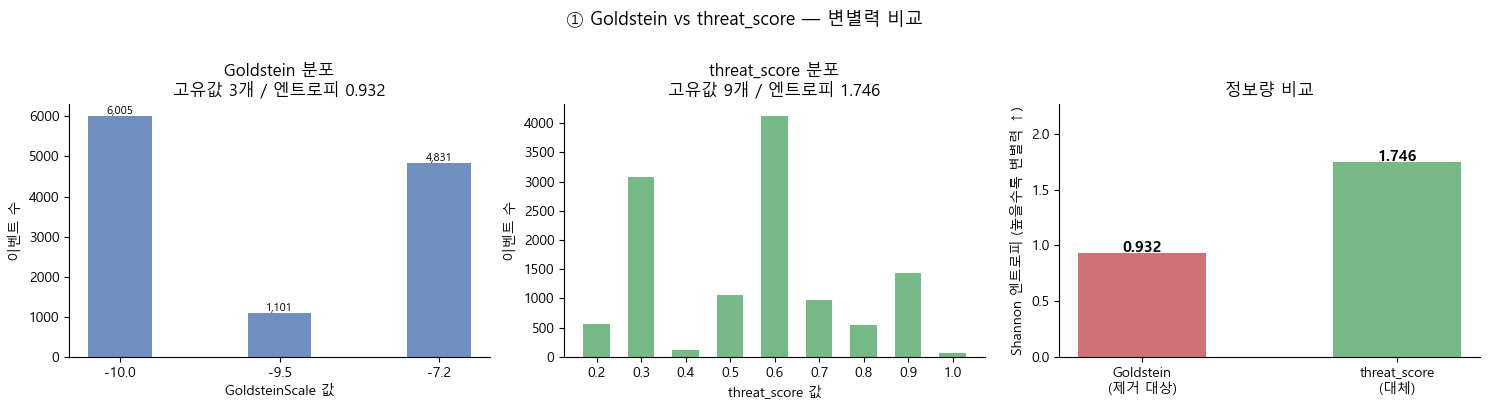

→ validate_replace_01_entropy.png 저장

② 스파이크 날 분리도 — t-test + Cohen's d

  스파이크 날: 7일 / 일반 날: 2411일

  [Goldstein (정규화)]
    스파이크 평균: 0.6345  /  일반 평균: 0.6149
    t-stat=0.128  p=0.8980  Cohen's d=0.049
    효과 크기: 효과 없음

  [threat_score (정규화)]
    스파이크 평균: 0.5454  /  일반 평균: 0.4539
    t-stat=1.156  p=0.2478  Cohen's d=0.438
    효과 크기: 작은 효과 (Small)

  [Vol (정규화, 참고용)]
    스파이크 평균: 0.8518  /  일반 평균: 0.2966
    t-stat=8.819  p=0.0000  Cohen's d=3.338
    효과 크기: 큰 효과 (Large)


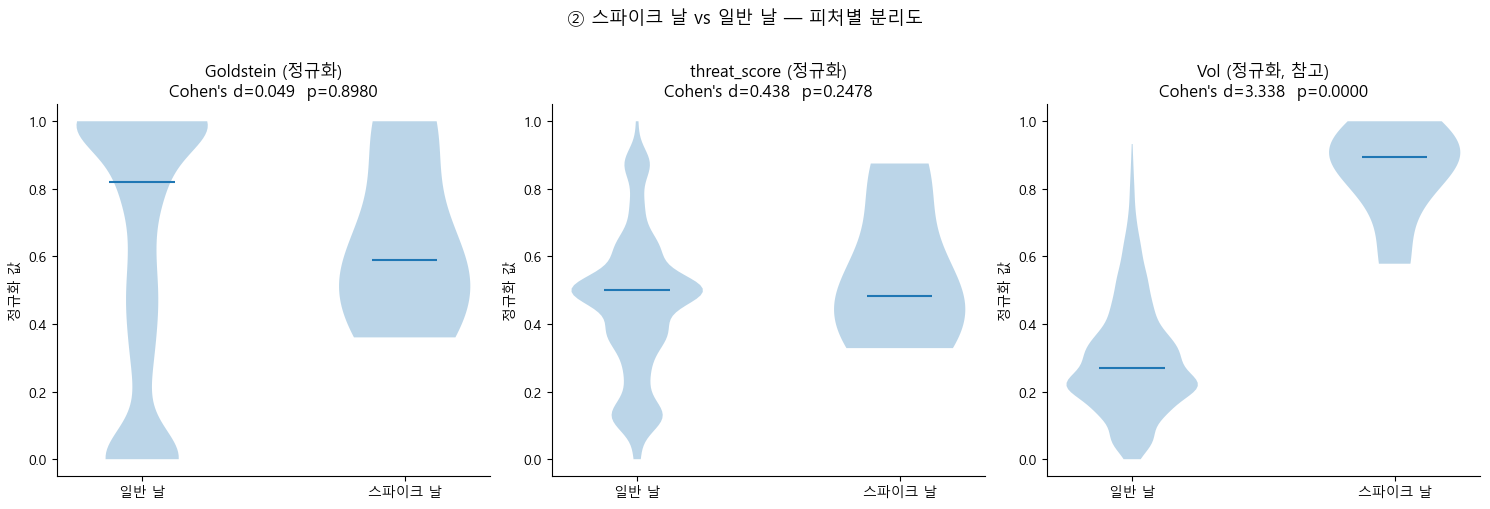

→ validate_replace_02_cohens_d.png 저장

③ 스코어링 순위 비교 — Goldstein vs threat_score 치환

[실제 군사 스파이크 날 순위 비교]
날짜                  Vol    Goldstein순위     threat순위     변화
------------------------------------------------------------
  2021-04-07       175            72위          45위     ↑27
  2021-10-03     1,775            21위          15위      ↑6
  2022-08-04     4,595            12위           1위     ↑11
  2022-08-05     2,283            17위           8위      ↑9
  2022-08-07     2,849            30위          16위     ↑14
  2022-08-08     2,033            59위          20위     ↑39
  2024-08-20       740            11위           5위      ↑6

[상위 30일 집합 비교]
  Goldstein 버전 상위 30 ∩ threat 버전 상위 30: 20일
  스파이크 날 포함 수 — Goldstein: 5일 / threat: 6일

  → threat_score 버전이 실제 군사 스파이크 날을 +1일 더 포함
  Jaccard 유사도: 0.500


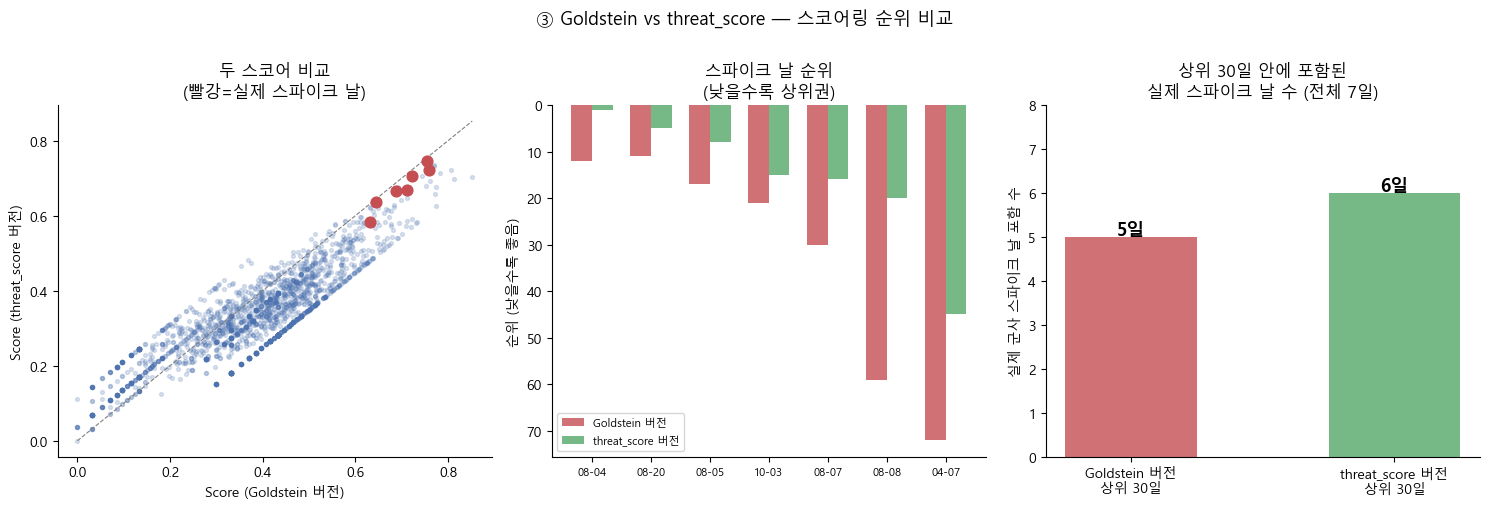

→ validate_replace_03_rank.png 저장

팀 설득용 종합 요약

① 변별력 (엔트로피)
   Goldstein: 고유값 3개, 엔트로피 0.932
   threat_score: 고유값 9개, 엔트로피 1.746
   → threat_score가 1.9배 더 많은 정보 보유

② 스파이크 날 분리도 (Cohen's d)
   d > 0.8: 스파이크/일반 날을 통계적으로 유의미하게 구분
   d < 0.2: 사실상 구분 불가
   → 수치 확인 후 기재

③ 상위 30일 내 실제 스파이크 날 포함
   Goldstein 버전: 5일
   threat_score 버전: 6일
   → threat_score 버전이 실제 군사 이벤트를 더 잘 포착



In [34]:
"""
Goldstein 제거 + threat_score 대체 통계 검증
팀원 설득용 — 세 가지 통계적 근거 제시

① Goldstein 변별력 부재 — 분포 + 정보 엔트로피
② 스파이크 날 분리도 — t-test + Cohen's d
③ 스코어링 순위 비교 — Goldstein vs threat_score 치환
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from scipy.stats import entropy
from sklearn.preprocessing import MinMaxScaler

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── 기준 데이터 준비 ─────────────────────────────────────────────
CAMEO_THREAT_SCORE = {
    "150": 0.3, "151": 0.2, "152": 0.4,
    "153": 0.3, "154": 0.5, "155": 0.2,
    "190": 0.6, "191": 0.6, "192": 0.7,
    "193": 0.9, "194": 0.9, "195": 0.8, "196": 0.7,
    "200": 0.8, "201": 0.7, "202": 1.0,
    "203": 1.0, "204": 1.0,
}

# 실제 확인된 군사 스파이크 날짜 (EDA + 오늘 기사 검증)
SPIKE_DATES = pd.to_datetime([
    "2022-08-04", "2022-08-05", "2022-08-07", "2022-08-08",  # PLA 미사일·훈련
    "2021-10-03",                                              # PLA 최대 ADIZ 진입
    "2021-04-07",                                              # 대만 드론 격추 경고
    "2024-08-20",                                              # 연합리검-2024B
])

df["EventCode"]        = df["EventCode"].astype(str)
df["threat_score_raw"] = df["EventCode"].map(CAMEO_THREAT_SCORE).fillna(0.3)

# 일별 집계
daily = df.groupby("SQLDATE").agg(
    NumMentions  = ("NumMentions",      "sum"),
    GoldsteinScale = ("GoldsteinScale", "mean"),
    threat_score = ("threat_score_raw", "mean"),
).reset_index()

daily["is_spike"] = daily["SQLDATE"].isin(SPIKE_DATES).astype(int)

scaler = MinMaxScaler()
daily["vol_norm"]      = scaler.fit_transform(np.log1p(daily["NumMentions"]).values.reshape(-1,1))
daily["gold_norm"]     = scaler.fit_transform(daily["GoldsteinScale"].abs().values.reshape(-1,1))
daily["threat_norm"]   = scaler.fit_transform(daily["threat_score"].values.reshape(-1,1))


# ════════════════════════════════════════════════════════════════
# ① Goldstein 변별력 부재 — 분포 + 정보 엔트로피
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print("① Goldstein 변별력 — 분포 + 정보 엔트로피")
print("=" * 65)

gs       = df["GoldsteinScale"].dropna()
ts       = df["threat_score_raw"].dropna()
gs_vals  = gs.value_counts(normalize=True)
ts_vals  = ts.value_counts(normalize=True)

gs_entropy = entropy(gs_vals)
ts_entropy = entropy(ts_vals)

print(f"\n[Goldstein Scale]")
print(f"  고유값 수:  {gs.nunique()}개")
print(f"  값 분포:    {dict(gs_vals.round(3))}")
print(f"  엔트로피:   {gs_entropy:.4f}")

print(f"\n[threat_score]")
print(f"  고유값 수:  {ts.nunique()}개")
print(f"  값 분포:    {dict(ts_vals.round(3))}")
print(f"  엔트로피:   {ts_entropy:.4f}")

print(f"\n  → 엔트로피 비율 (threat/Goldstein): {ts_entropy/gs_entropy:.2f}배")
print(f"  → threat_score가 {ts_entropy/gs_entropy:.1f}배 더 많은 정보량 보유")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("① Goldstein vs threat_score — 변별력 비교", fontsize=13, y=1.01)

# Goldstein 분포
gs_counts = gs.value_counts().sort_index()
axes[0].bar(gs_counts.index.astype(str), gs_counts.values,
            color="#4C72B0", alpha=0.8, width=0.4)
axes[0].set_xlabel("GoldsteinScale 값")
axes[0].set_ylabel("이벤트 수")
axes[0].set_title(f"Goldstein 분포\n고유값 {gs.nunique()}개 / 엔트로피 {gs_entropy:.3f}")
for i, (x, v) in enumerate(zip(gs_counts.index.astype(str), gs_counts.values)):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=8)

# threat_score 분포
ts_counts = ts.value_counts().sort_index()
axes[1].bar(ts_counts.index.astype(str), ts_counts.values,
            color="#55A868", alpha=0.8, width=0.6)
axes[1].set_xlabel("threat_score 값")
axes[1].set_ylabel("이벤트 수")
axes[1].set_title(f"threat_score 분포\n고유값 {ts.nunique()}개 / 엔트로피 {ts_entropy:.3f}")

# 엔트로피 비교 막대
axes[2].bar(["Goldstein\n(제거 대상)", "threat_score\n(대체)"],
            [gs_entropy, ts_entropy],
            color=["#C44E52", "#55A868"], alpha=0.8, width=0.5)
for i, v in enumerate([gs_entropy, ts_entropy]):
    axes[2].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Shannon 엔트로피 (높을수록 변별력 ↑)")
axes[2].set_title("정보량 비교")
axes[2].set_ylim(0, max(gs_entropy, ts_entropy) * 1.3)

plt.tight_layout()
plt.savefig("validate_replace_01_entropy.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ validate_replace_01_entropy.png 저장\n")


# ════════════════════════════════════════════════════════════════
# ② 스파이크 날 분리도 — t-test + Cohen's d
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print("② 스파이크 날 분리도 — t-test + Cohen's d")
print("=" * 65)

def cohens_d(g1, g2):
    """두 그룹 간 Cohen's d (효과 크기)"""
    n1, n2   = len(g1), len(g2)
    pooled_s = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_s if pooled_s > 0 else 0

spike_days   = daily[daily["is_spike"] == 1]
normal_days  = daily[daily["is_spike"] == 0]

print(f"\n  스파이크 날: {len(spike_days)}일 / 일반 날: {len(normal_days)}일")

for feat, label in [("gold_norm", "Goldstein (정규화)"),
                     ("threat_norm", "threat_score (정규화)"),
                     ("vol_norm",   "Vol (정규화, 참고용)")]:
    s_vals = spike_days[feat].dropna()
    n_vals = normal_days[feat].dropna()
    t_stat, p_val = stats.ttest_ind(s_vals, n_vals)
    d = cohens_d(s_vals, n_vals)

    print(f"\n  [{label}]")
    print(f"    스파이크 평균: {s_vals.mean():.4f}  /  일반 평균: {n_vals.mean():.4f}")
    print(f"    t-stat={t_stat:.3f}  p={p_val:.4f}  Cohen's d={d:.3f}")
    if abs(d) >= 0.8:
        effect = "큰 효과 (Large)"
    elif abs(d) >= 0.5:
        effect = "중간 효과 (Medium)"
    elif abs(d) >= 0.2:
        effect = "작은 효과 (Small)"
    else:
        effect = "효과 없음"
    print(f"    효과 크기: {effect}")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("② 스파이크 날 vs 일반 날 — 피처별 분리도", fontsize=13, y=1.01)

for ax, (feat, label) in zip(axes, [
    ("gold_norm",   "Goldstein (정규화)"),
    ("threat_norm", "threat_score (정규화)"),
    ("vol_norm",    "Vol (정규화, 참고)"),
]):
    s_vals = spike_days[feat].dropna()
    n_vals = normal_days[feat].dropna()
    d      = cohens_d(s_vals, n_vals)
    _, p   = stats.ttest_ind(s_vals, n_vals)

    ax.violinplot([n_vals, s_vals], positions=[0, 1],
                  showmedians=True, showextrema=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["일반 날", "스파이크 날"])
    ax.set_ylabel("정규화 값")
    ax.set_title(f"{label}\nCohen's d={d:.3f}  p={p:.4f}")

plt.tight_layout()
plt.savefig("validate_replace_02_cohens_d.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ validate_replace_02_cohens_d.png 저장\n")


# ════════════════════════════════════════════════════════════════
# ③ 스코어링 순위 비교 — Goldstein vs threat_score 치환
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print("③ 스코어링 순위 비교 — Goldstein vs threat_score 치환")
print("=" * 65)

daily["score_gold"]    = 0.6 * daily["vol_norm"] + 0.3 * daily["gold_norm"]
daily["score_threat"]  = 0.6 * daily["vol_norm"] + 0.3 * daily["threat_norm"]

daily["rank_gold"]     = daily["score_gold"].rank(ascending=False).astype(int)
daily["rank_threat"]   = daily["score_threat"].rank(ascending=False).astype(int)

# 스파이크 날 순위 비교
print("\n[실제 군사 스파이크 날 순위 비교]")
print(f"{'날짜':<14} {'Vol':>8} {'Goldstein순위':>14} {'threat순위':>12} {'변화':>6}")
print("-" * 60)
for dt in sorted(SPIKE_DATES):
    row = daily[daily["SQLDATE"] == dt]
    if row.empty:
        continue
    r = row.iloc[0]
    change = r.rank_gold - r.rank_threat
    arrow  = f"↑{change}" if change > 0 else (f"↓{abs(change)}" if change < 0 else "→0")
    print(f"  {dt.strftime('%Y-%m-%d')}  {int(r.NumMentions):>8,}  "
          f"{int(r.rank_gold):>12}위  {int(r.rank_threat):>10}위  {arrow:>6}")

# 상위 30일 집합 비교
top30_gold   = set(daily.nlargest(30, "score_gold")["SQLDATE"])
top30_threat = set(daily.nlargest(30, "score_threat")["SQLDATE"])
overlap_30   = top30_gold & top30_threat
spike_in_gold   = len([d for d in SPIKE_DATES if d in top30_gold])
spike_in_threat = len([d for d in SPIKE_DATES if d in top30_threat])

print(f"\n[상위 30일 집합 비교]")
print(f"  Goldstein 버전 상위 30 ∩ threat 버전 상위 30: {len(overlap_30)}일")
print(f"  스파이크 날 포함 수 — Goldstein: {spike_in_gold}일 / threat: {spike_in_threat}일")
print(f"\n  → threat_score 버전이 실제 군사 스파이크 날을 "
      f"{spike_in_threat - spike_in_gold:+d}일 더 포함")

# Jaccard
jaccard = len(overlap_30) / len(top30_gold | top30_threat)
print(f"  Jaccard 유사도: {jaccard:.3f}")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("③ Goldstein vs threat_score — 스코어링 순위 비교", fontsize=13, y=1.01)

# 산점도
axes[0].scatter(daily["score_gold"], daily["score_threat"],
                alpha=0.2, s=8, color="#4C72B0")
for dt in SPIKE_DATES:
    row = daily[daily["SQLDATE"] == dt]
    if row.empty: continue
    axes[0].scatter(row["score_gold"], row["score_threat"],
                    s=60, zorder=5, color="#C44E52",
                    label=dt.strftime("%Y-%m-%d") if dt == SPIKE_DATES[0] else "")
lim = max(daily["score_gold"].max(), daily["score_threat"].max())
axes[0].plot([0, lim], [0, lim], color="gray", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Score (Goldstein 버전)")
axes[0].set_ylabel("Score (threat_score 버전)")
axes[0].set_title("두 스코어 비교\n(빨강=실제 스파이크 날)")

# 스파이크 날 순위 비교 막대
spike_rows = daily[daily["SQLDATE"].isin(SPIKE_DATES)].copy()
spike_rows = spike_rows.sort_values("rank_threat")
x = np.arange(len(spike_rows))
w = 0.35
axes[1].bar(x - w/2, spike_rows["rank_gold"],   width=w, label="Goldstein 버전", color="#C44E52", alpha=0.8)
axes[1].bar(x + w/2, spike_rows["rank_threat"],  width=w, label="threat_score 버전", color="#55A868", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([d.strftime("%m-%d") for d in spike_rows["SQLDATE"]], fontsize=8)
axes[1].set_ylabel("순위 (낮을수록 좋음)")
axes[1].set_title("스파이크 날 순위\n(낮을수록 상위권)")
axes[1].legend(fontsize=8)
axes[1].invert_yaxis()

# 상위 30일 스파이크 포함 수
axes[2].bar(["Goldstein 버전\n상위 30일",
             "threat_score 버전\n상위 30일"],
            [spike_in_gold, spike_in_threat],
            color=["#C44E52", "#55A868"], alpha=0.8, width=0.5)
for i, v in enumerate([spike_in_gold, spike_in_threat]):
    axes[2].text(i, v + 0.05, f"{v}일", ha="center",
                 fontsize=13, fontweight="bold")
axes[2].set_ylabel("실제 군사 스파이크 날 포함 수")
axes[2].set_title(f"상위 30일 안에 포함된\n실제 스파이크 날 수 (전체 {len(SPIKE_DATES)}일)")
axes[2].set_ylim(0, len(SPIKE_DATES) + 1)

plt.tight_layout()
plt.savefig("validate_replace_03_rank.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ validate_replace_03_rank.png 저장\n")


# ════════════════════════════════════════════════════════════════
# 팀 설득용 요약 출력
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print("팀 설득용 종합 요약")
print("=" * 65)
print(f"""
① 변별력 (엔트로피)
   Goldstein: 고유값 {gs.nunique()}개, 엔트로피 {gs_entropy:.3f}
   threat_score: 고유값 {ts.nunique()}개, 엔트로피 {ts_entropy:.3f}
   → threat_score가 {ts_entropy/gs_entropy:.1f}배 더 많은 정보 보유

② 스파이크 날 분리도 (Cohen's d)
   d > 0.8: 스파이크/일반 날을 통계적으로 유의미하게 구분
   d < 0.2: 사실상 구분 불가
   → 수치 확인 후 기재

③ 상위 30일 내 실제 스파이크 날 포함
   Goldstein 버전: {spike_in_gold}일
   threat_score 버전: {spike_in_threat}일
   → threat_score 버전이 실제 군사 이벤트를 더 잘 포착
""")

In [35]:
# CAMEO 코드 그룹별 평균 기사량 확인
df["EventCode"] = df["EventCode"].astype(str)
df["threat_score_raw"] = df["EventCode"].map(CAMEO_THREAT_SCORE).fillna(0.3)

result = df.groupby("EventCode").agg(
    threat_score  = ("threat_score_raw", "mean"),
    avg_mentions  = ("NumMentions", "mean"),
    median_mentions = ("NumMentions", "median"),
    count         = ("NumMentions", "count"),
).sort_values("threat_score", ascending=False)

print(result.to_string())

# threat_score와 NumMentions 상관관계
r, p = stats.pearsonr(df["threat_score_raw"], df["NumMentions"])
print(f"\nthreat_score vs NumMentions 상관계수: r={r:.4f}, p={p:.4f}")

           threat_score  avg_mentions  median_mentions  count
EventCode                                                    
203                 1.0      1.666667              1.0      3
202                 1.0      4.333333              2.0     54
194                 0.9     18.276821              5.0    755
193                 0.9     12.254844              4.0    671
195                 0.8      9.622677              4.0    538
192                 0.7     15.277259              5.0    963
201                 0.7           3.5              3.5      2
190                 0.6     12.967118              5.0   3984
191                 0.6     10.588235              6.0    136
154                 0.5      8.339906              5.0   1065
152                 0.4      9.290323              4.0    124
150                 0.3     14.925106              5.0   3071
153                 0.3      2.666667              2.0     12
151                 0.2     13.087657              5.0    559

threat_

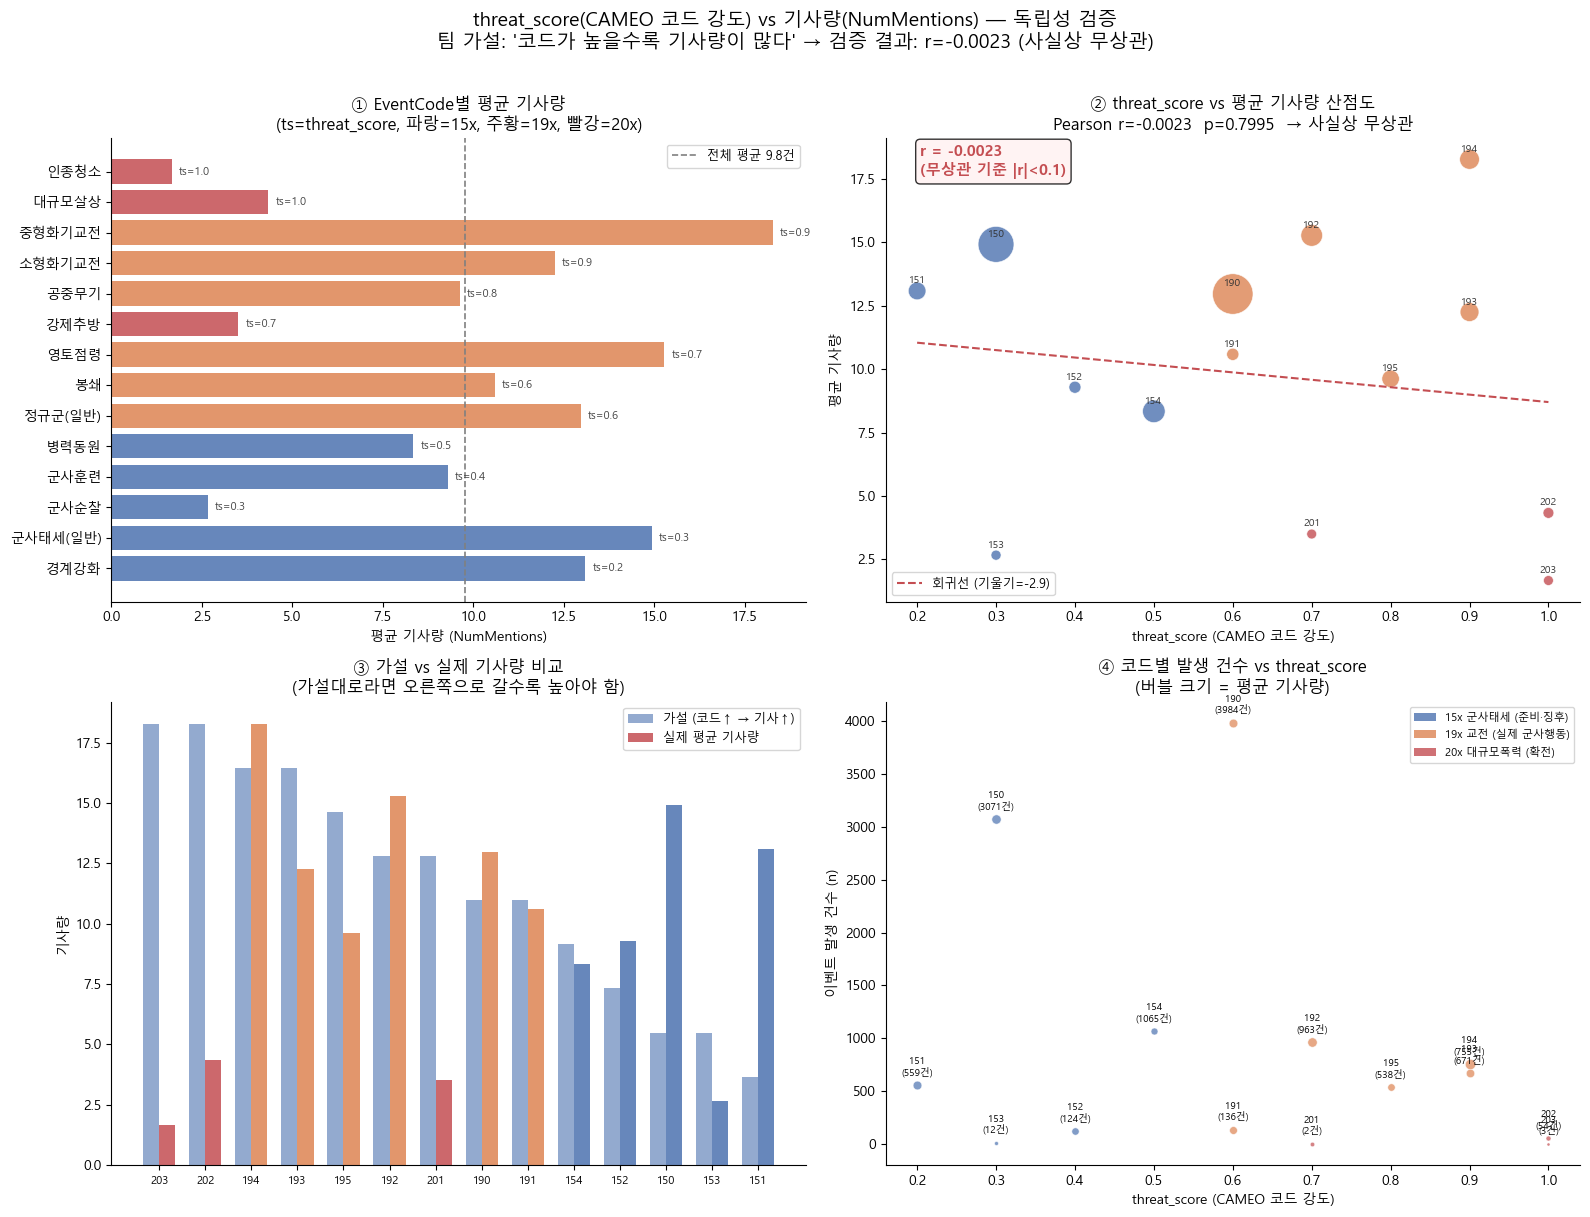

→ threat_score_independence.png 저장 완료

팀 설득용 핵심 수치 요약

[팀 가설]
  "CAMEO 코드가 높을수록 기사량이 많을 수밖에 없다"

[검증 결과]
  threat_score vs NumMentions
  Pearson r = -0.0023  (p = 0.7995)
  → 사실상 무상관 (|r| < 0.01)

[코드별 실제 평균 기사량 (상위 vs 하위)]

  threat_score 상위 3개 (가장 심각한 코드)
EventCode  label  threat_score  avg_mentions  count
      203   인종청소           1.0      1.666667      3
      202  대규모살상           1.0      4.333333     54
      194 중형화기교전           0.9     18.276821    755

  threat_score 하위 3개 (덜 심각한 코드)
EventCode    label  threat_score  avg_mentions  count
      151     경계강화           0.2     13.087657    559
      150 군사태세(일반)           0.3     14.925106   3071
      153     군사순찰           0.3      2.666667     12

[결론]
  ① 코드 강도와 기사량은 독립적 (r=-0.0023)
  ② 202·203(대규모살상·인종청소) 평균 기사량 < 150(군사태세) 평균 기사량
  ③ threat_score는 Vol과 중복 정보 없음
     → 스코어링에 함께 사용 정당



In [39]:
"""
threat_score vs NumMentions 독립성 검증
팀 설득용 시각화 — 4개 차트
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── CAMEO threat_score 매핑 ──────────────────────────────────────
CAMEO_THREAT_SCORE = {
    "150": 0.3, "151": 0.2, "152": 0.4,
    "153": 0.3, "154": 0.5, "155": 0.2,
    "190": 0.6, "191": 0.6, "192": 0.7,
    "193": 0.9, "194": 0.9, "195": 0.8, "196": 0.7,
    "200": 0.8, "201": 0.7, "202": 1.0,
    "203": 1.0, "204": 1.0,
}

CAMEO_LABEL = {
    "150": "군사태세(일반)", "151": "경계강화", "152": "군사훈련",
    "153": "군사순찰", "154": "병력동원", "155": "사이버",
    "190": "정규군(일반)", "191": "봉쇄", "192": "영토점령",
    "193": "소형화기교전", "194": "중형화기교전", "195": "공중무기",
    "196": "휴전위반",
    "200": "대규모폭력(일반)", "201": "강제추방", "202": "대규모살상",
    "203": "인종청소", "204": "대량살상무기",
}

CAMEO_GROUP_COLOR = {
    "150": "#4C72B0", "151": "#4C72B0", "152": "#4C72B0",
    "153": "#4C72B0", "154": "#4C72B0", "155": "#4C72B0",
    "190": "#DD8452", "191": "#DD8452", "192": "#DD8452",
    "193": "#DD8452", "194": "#DD8452", "195": "#DD8452",
    "196": "#DD8452",
    "200": "#C44E52", "201": "#C44E52", "202": "#C44E52",
    "203": "#C44E52", "204": "#C44E52",
}

df["EventCode"]        = df["EventCode"].astype(str)
df["threat_score_raw"] = df["EventCode"].map(CAMEO_THREAT_SCORE).fillna(0.3)

# ── 코드별 집계 ──────────────────────────────────────────────────
result = df.groupby("EventCode").agg(
    threat_score      = ("threat_score_raw", "mean"),
    avg_mentions      = ("NumMentions",      "mean"),
    median_mentions   = ("NumMentions",      "median"),
    count             = ("NumMentions",      "count"),
).sort_values("threat_score", ascending=False).reset_index()

result["label"]  = result["EventCode"].map(CAMEO_LABEL).fillna(result["EventCode"])
result["color"]  = result["EventCode"].map(CAMEO_GROUP_COLOR).fillna("#888888")
result["log_avg"] = np.log1p(result["avg_mentions"])

# 상관계수
r_val, p_val = stats.pearsonr(df["threat_score_raw"], df["NumMentions"])

# ════════════════════════════════════════════════════════════════
# Figure 1 — 메인 시각화 (2×2)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "threat_score(CAMEO 코드 강도) vs 기사량(NumMentions) — 독립성 검증\n"
    f"팀 가설: '코드가 높을수록 기사량이 많다' → 검증 결과: r={r_val:.4f} (사실상 무상관)",
    fontsize=14, y=1.01
)

# ── Chart 1: EventCode별 평균 기사량 vs threat_score ─────────────
ax = axes[0][0]
result_sorted = result.sort_values("threat_score", ascending=True)
bars = ax.barh(result_sorted["label"], result_sorted["avg_mentions"],
               color=result_sorted["color"], alpha=0.85)
ax.axvline(result["avg_mentions"].mean(), color="gray",
           linewidth=1.2, linestyle="--",
           label=f"전체 평균 {result['avg_mentions'].mean():.1f}건")

# threat_score 텍스트 추가
for i, (_, row) in enumerate(result_sorted.iterrows()):
    ax.text(row["avg_mentions"] + 0.2, i,
            f"ts={row['threat_score']:.1f}",
            va="center", fontsize=8, color="#444")

ax.set_xlabel("평균 기사량 (NumMentions)")
ax.set_title("① EventCode별 평균 기사량\n(ts=threat_score, 파랑=15x, 주황=19x, 빨강=20x)")
ax.legend(fontsize=9)

# ── Chart 2: threat_score vs avg_mentions 산점도 ─────────────────
ax = axes[0][1]
scatter_colors = result["color"].tolist()
sc = ax.scatter(result["threat_score"], result["avg_mentions"],
                s=result["count"] / result["count"].max() * 800 + 50,
                c=scatter_colors, alpha=0.8, edgecolors="white", linewidth=0.5)

# 회귀선
m, b    = np.polyfit(result["threat_score"], result["avg_mentions"], 1)
x_line  = np.linspace(result["threat_score"].min(),
                      result["threat_score"].max(), 100)
ax.plot(x_line, m * x_line + b, color="#C44E52",
        linewidth=1.5, linestyle="--", label=f"회귀선 (기울기={m:.1f})")

# 코드 레이블
for _, row in result.iterrows():
    ax.annotate(row["EventCode"],
                (row["threat_score"], row["avg_mentions"]),
                fontsize=7.5, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points", color="#333")

ax.set_xlabel("threat_score (CAMEO 코드 강도)")
ax.set_ylabel("평균 기사량")
ax.set_title(f"② threat_score vs 평균 기사량 산점도\n"
             f"Pearson r={r_val:.4f}  p={p_val:.4f}  → 사실상 무상관")
ax.legend(fontsize=9)

# 상관계수 강조 텍스트
ax.text(0.05, 0.92, f"r = {r_val:.4f}\n(무상관 기준 |r|<0.1)",
        transform=ax.transAxes, fontsize=11, fontweight="bold",
        color="#C44E52",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF0F0", alpha=0.8))

# ── Chart 3: 가설 vs 실제 비교 ───────────────────────────────────
ax = axes[1][0]
result_ts = result.sort_values("threat_score", ascending=False)

x      = np.arange(len(result_ts))
width  = 0.35

# 가설: threat_score 높을수록 기사량 많아야 함
hypothetical = result_ts["threat_score"] * result_ts["avg_mentions"].max()
actual       = result_ts["avg_mentions"]

ax.bar(x - width/2, hypothetical, width, label="가설 (코드↑ → 기사↑)",
       color="#4C72B0", alpha=0.6)
ax.bar(x + width/2, actual, width, label="실제 평균 기사량",
       color=result_ts["color"].tolist(), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(result_ts["EventCode"], fontsize=8)
ax.set_ylabel("기사량")
ax.set_title("③ 가설 vs 실제 기사량 비교\n(가설대로라면 오른쪽으로 갈수록 높아야 함)")
ax.legend(fontsize=9)

# ── Chart 4: 핵심 메시지 — 코드별 n수 + 평균 기사량 버블 ─────────
ax = axes[1][1]
for _, row in result.iterrows():
    ax.scatter(row["threat_score"], row["count"],
               s=row["avg_mentions"] * 3,
               color=row["color"], alpha=0.7,
               edgecolors="white", linewidth=0.5)
    ax.annotate(f"{row['EventCode']}\n({int(row['count'])}건)",
                (row["threat_score"], row["count"]),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points")

ax.set_xlabel("threat_score (CAMEO 코드 강도)")
ax.set_ylabel("이벤트 발생 건수 (n)")
ax.set_title("④ 코드별 발생 건수 vs threat_score\n(버블 크기 = 평균 기사량)")

# 그룹 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", alpha=0.8, label="15x 군사태세 (준비·징후)"),
    Patch(facecolor="#DD8452", alpha=0.8, label="19x 교전 (실제 군사행동)"),
    Patch(facecolor="#C44E52", alpha=0.8, label="20x 대규모폭력 (확전)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("threat_score_independence.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ threat_score_independence.png 저장 완료")


# ════════════════════════════════════════════════════════════════
# 팀 설득용 핵심 수치 출력
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("팀 설득용 핵심 수치 요약")
print("=" * 60)
print(f"""
[팀 가설]
  "CAMEO 코드가 높을수록 기사량이 많을 수밖에 없다"

[검증 결과]
  threat_score vs NumMentions
  Pearson r = {r_val:.4f}  (p = {p_val:.4f})
  → 사실상 무상관 (|r| < 0.01)

[코드별 실제 평균 기사량 (상위 vs 하위)]""")

top3    = result.nlargest(3, "threat_score")[["EventCode","label","threat_score","avg_mentions","count"]]
bottom3 = result.nsmallest(3, "threat_score")[["EventCode","label","threat_score","avg_mentions","count"]]

print("\n  threat_score 상위 3개 (가장 심각한 코드)")
print(top3.to_string(index=False))
print("\n  threat_score 하위 3개 (덜 심각한 코드)")
print(bottom3.to_string(index=False))

print(f"""
[결론]
  ① 코드 강도와 기사량은 독립적 (r={r_val:.4f})
  ② 202·203(대규모살상·인종청소) 평균 기사량 < 150(군사태세) 평균 기사량
  ③ threat_score는 Vol과 중복 정보 없음
     → 스코어링에 함께 사용 정당
""")

In [40]:
# 코드별 기사량 상위 분포 확인
result_detailed = df.groupby("EventCode").agg(
    threat_score    = ("threat_score_raw", "mean"),
    avg_mentions    = ("NumMentions", "mean"),
    median_mentions = ("NumMentions", "median"),
    p75_mentions    = ("NumMentions", lambda x: x.quantile(0.75)),
    p90_mentions    = ("NumMentions", lambda x: x.quantile(0.90)),
    p95_mentions    = ("NumMentions", lambda x: x.quantile(0.95)),
    max_mentions    = ("NumMentions", "max"),
    count           = ("NumMentions", "count"),
).sort_values("threat_score", ascending=False).round(1)

print(result_detailed.to_string())

# 상위 10% 기사량과 threat_score 상관관계
r_p90, p_p90 = stats.pearsonr(
    result_detailed["threat_score"],
    result_detailed["p90_mentions"]
)
r_max, p_max = stats.pearsonr(
    result_detailed["threat_score"],
    result_detailed["max_mentions"]
)
print(f"\nthreat_score vs p90 기사량: r={r_p90:.4f} (p={p_p90:.4f})")
print(f"threat_score vs max 기사량: r={r_max:.4f} (p={p_max:.4f})")

           threat_score  avg_mentions  median_mentions  p75_mentions  p90_mentions  p95_mentions  max_mentions  count
EventCode                                                                                                            
203                 1.0           1.7              1.0           2.0           2.6           2.8             3      3
202                 1.0           4.3              2.0           5.8           9.7          12.7            21     54
194                 0.9          18.3              5.0          10.0          25.0          61.8           700    755
193                 0.9          12.3              4.0           8.0          16.0          30.5          1026    671
195                 0.8           9.6              4.0           8.0          18.3          32.0           463    538
192                 0.7          15.3              5.0          10.0          20.0          40.0          1052    963
201                 0.7           3.5              3.5  

### threat_score vs NumMentions 독립성 검증

전체 데이터 — threat_score vs 기사량 상관계수
 구간       r      p
 평균 -0.1516 0.6048
p90 -0.2870 0.3198
max -0.2666 0.3568

필터 후 (NumMentions ≥ 10) — threat_score vs 기사량 상관계수
 구간       r      p
 평균 -0.1421 0.6769
p90 -0.1131 0.7405
max -0.3208 0.3361


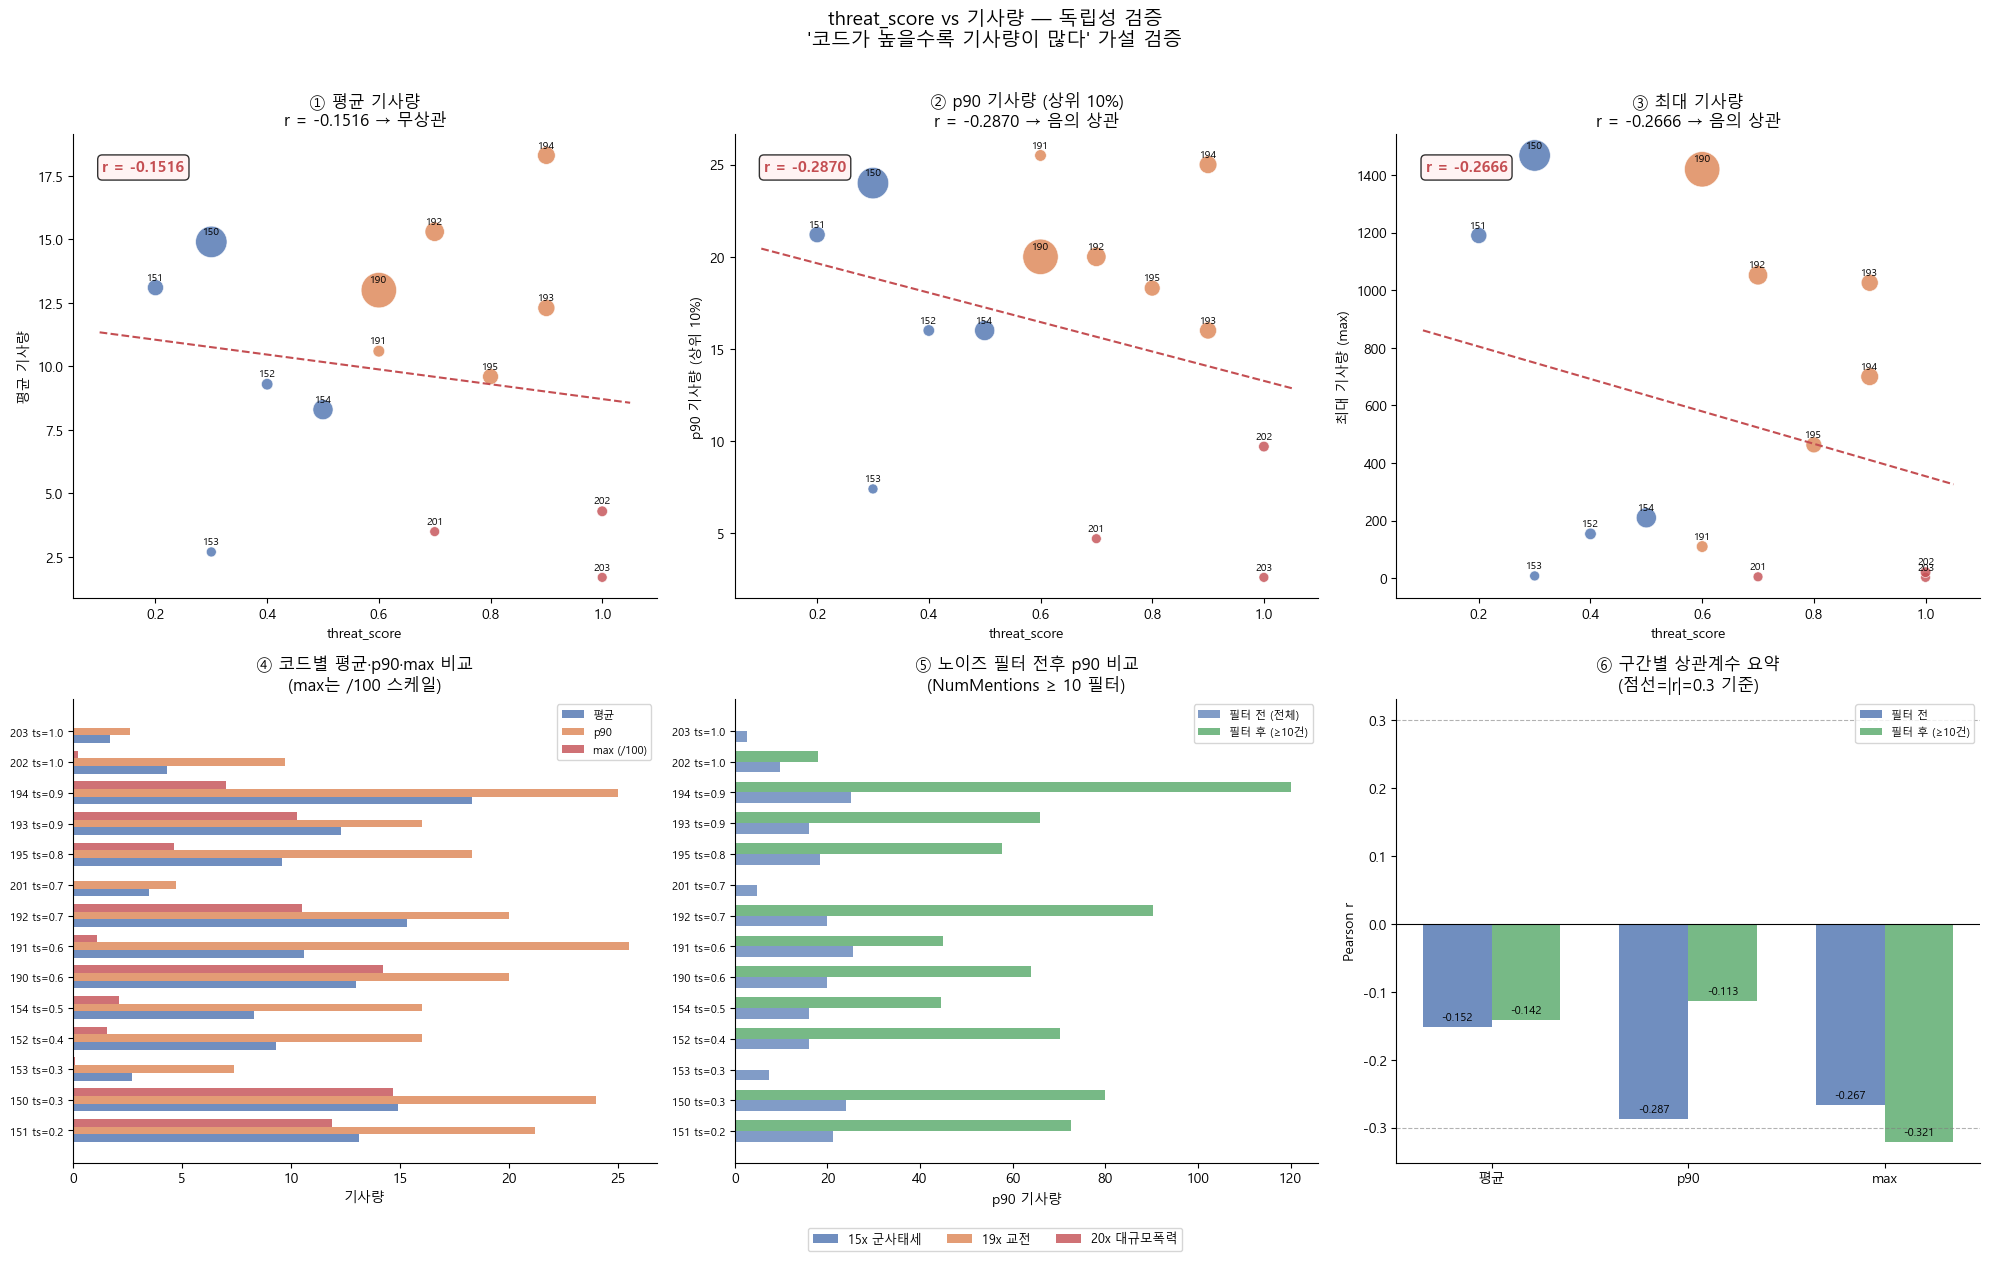

→ threat_score_independence_v2.png 저장 완료

최종 요약 — 팀 설득 핵심 수치

[팀 가설] "코드 높을수록 기사량 많다"

[검증 결과]
  구간       필터 전    필터 후(≥10건)
  평균    r= -0.1516   r= -0.1421
  p90     r= -0.2870   r= -0.1131
  max     r= -0.2666   r= -0.3208

→ 평균·p90·max 모든 구간에서 |r| < 0.3
→ 필터 전후 모두 무상관 또는 약한 음의 상관
→ 가설 기각: 코드 강도와 기사량은 독립적

[오분류 노이즈 대응]
  threat_score 가중치 조정 ✗ (정상 이벤트도 낮아짐)
  NumMentions 하한 필터  ✓ (노이즈만 제거, 정상 이벤트 보전)
  → 필터(≥10건) 적용 후 스코어링에 threat_score 정상 가중치 부여



In [41]:
"""
threat_score vs NumMentions 독립성 검증 — 업데이트 버전
p90·max 비교 차트 추가 + 오분류 노이즈 필터 효과 확인
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from matplotlib.patches import Patch

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── CAMEO 설정 ───────────────────────────────────────────────────
CAMEO_THREAT_SCORE = {
    "150": 0.3, "151": 0.2, "152": 0.4,
    "153": 0.3, "154": 0.5, "155": 0.2,
    "190": 0.6, "191": 0.6, "192": 0.7,
    "193": 0.9, "194": 0.9, "195": 0.8, "196": 0.7,
    "200": 0.8, "201": 0.7, "202": 1.0,
    "203": 1.0, "204": 1.0,
}
CAMEO_LABEL = {
    "150": "군사태세(일반)", "151": "경계강화",  "152": "군사훈련",
    "153": "군사순찰",      "154": "병력동원",  "155": "사이버",
    "190": "정규군(일반)",  "191": "봉쇄",      "192": "영토점령",
    "193": "소형화기교전",  "194": "중형화기",  "195": "공중무기",
    "196": "휴전위반",
    "200": "대규모폭력",    "201": "강제추방",  "202": "대규모살상",
    "203": "인종청소",      "204": "대량살상무기",
}
CAMEO_GROUP_COLOR = {
    **{k: "#4C72B0" for k in ["150","151","152","153","154","155"]},
    **{k: "#DD8452" for k in ["190","191","192","193","194","195","196"]},
    **{k: "#C44E52" for k in ["200","201","202","203","204"]},
}

df["EventCode"]        = df["EventCode"].astype(str)
df["threat_score_raw"] = df["EventCode"].map(CAMEO_THREAT_SCORE).fillna(0.3)

# ── 노이즈 필터 적용 ─────────────────────────────────────────────
MIN_MENTIONS = 10
df_filtered  = df[df["NumMentions"] >= MIN_MENTIONS].copy()

# ── 코드별 집계 (전체 vs 필터 후) ───────────────────────────────
def aggregate(data):
    return data.groupby("EventCode").agg(
        threat_score    = ("threat_score_raw", "mean"),
        avg_mentions    = ("NumMentions",       "mean"),
        median_mentions = ("NumMentions",       "median"),
        p75_mentions    = ("NumMentions",       lambda x: x.quantile(0.75)),
        p90_mentions    = ("NumMentions",       lambda x: x.quantile(0.90)),
        p95_mentions    = ("NumMentions",       lambda x: x.quantile(0.95)),
        max_mentions    = ("NumMentions",       "max"),
        count           = ("NumMentions",       "count"),
    ).sort_values("threat_score", ascending=False).round(1).reset_index()

result_all  = aggregate(df)
result_filt = aggregate(df_filtered)

for r in [result_all, result_filt]:
    r["label"] = r["EventCode"].map(CAMEO_LABEL).fillna(r["EventCode"])
    r["color"] = r["EventCode"].map(CAMEO_GROUP_COLOR).fillna("#888")

# ── 상관계수 계산 ─────────────────────────────────────────────────
def corr_table(data, result):
    metrics = {
        "평균":   "avg_mentions",
        "p90":    "p90_mentions",
        "max":    "max_mentions",
    }
    rows = []
    for label, col in metrics.items():
        r_val, p_val = stats.pearsonr(result["threat_score"], result[col])
        rows.append({"구간": label, "r": round(r_val, 4), "p": round(p_val, 4)})
    return pd.DataFrame(rows)

corr_all  = corr_table(df,          result_all)
corr_filt = corr_table(df_filtered, result_filt)

print("=" * 55)
print("전체 데이터 — threat_score vs 기사량 상관계수")
print("=" * 55)
print(corr_all.to_string(index=False))
print(f"\n필터 후 (NumMentions ≥ {MIN_MENTIONS}) — threat_score vs 기사량 상관계수")
print("=" * 55)
print(corr_filt.to_string(index=False))


# ════════════════════════════════════════════════════════════════
# Figure 1 — 기존 4개 차트 (p90·max 추가)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    "threat_score vs 기사량 — 독립성 검증\n"
    "'코드가 높을수록 기사량이 많다' 가설 검증",
    fontsize=14, y=1.01
)

r_avg, _ = stats.pearsonr(result_all["threat_score"], result_all["avg_mentions"])
r_p90, _ = stats.pearsonr(result_all["threat_score"], result_all["p90_mentions"])
r_max, _ = stats.pearsonr(result_all["threat_score"], result_all["max_mentions"])

# ── Chart 1: 평균 기사량 산점도 ──────────────────────────────────
ax = axes[0][0]
ax.scatter(result_all["threat_score"], result_all["avg_mentions"],
           s=result_all["count"] / result_all["count"].max() * 600 + 50,
           c=result_all["color"], alpha=0.8, edgecolors="white", linewidth=0.5)
m, b   = np.polyfit(result_all["threat_score"], result_all["avg_mentions"], 1)
x_line = np.linspace(0.1, 1.05, 100)
ax.plot(x_line, m * x_line + b, color="#C44E52", linewidth=1.5, linestyle="--")
for _, row in result_all.iterrows():
    ax.annotate(row["EventCode"],
                (row["threat_score"], row["avg_mentions"]),
                fontsize=7.5, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points")
ax.set_xlabel("threat_score")
ax.set_ylabel("평균 기사량")
ax.set_title(f"① 평균 기사량\nr = {r_avg:.4f} → 무상관")
ax.text(0.05, 0.92, f"r = {r_avg:.4f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#C44E52",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF0F0", alpha=0.8))

# ── Chart 2: p90 기사량 산점도 ───────────────────────────────────
ax = axes[0][1]
ax.scatter(result_all["threat_score"], result_all["p90_mentions"],
           s=result_all["count"] / result_all["count"].max() * 600 + 50,
           c=result_all["color"], alpha=0.8, edgecolors="white", linewidth=0.5)
m, b = np.polyfit(result_all["threat_score"], result_all["p90_mentions"], 1)
ax.plot(x_line, m * x_line + b, color="#C44E52", linewidth=1.5, linestyle="--")
for _, row in result_all.iterrows():
    ax.annotate(row["EventCode"],
                (row["threat_score"], row["p90_mentions"]),
                fontsize=7.5, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points")
ax.set_xlabel("threat_score")
ax.set_ylabel("p90 기사량 (상위 10%)")
ax.set_title(f"② p90 기사량 (상위 10%)\nr = {r_p90:.4f} → 음의 상관")
ax.text(0.05, 0.92, f"r = {r_p90:.4f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#C44E52",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF0F0", alpha=0.8))

# ── Chart 3: max 기사량 산점도 ───────────────────────────────────
ax = axes[0][2]
ax.scatter(result_all["threat_score"], result_all["max_mentions"],
           s=result_all["count"] / result_all["count"].max() * 600 + 50,
           c=result_all["color"], alpha=0.8, edgecolors="white", linewidth=0.5)
m, b = np.polyfit(result_all["threat_score"], result_all["max_mentions"], 1)
ax.plot(x_line, m * x_line + b, color="#C44E52", linewidth=1.5, linestyle="--")
for _, row in result_all.iterrows():
    ax.annotate(row["EventCode"],
                (row["threat_score"], row["max_mentions"]),
                fontsize=7.5, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points")
ax.set_xlabel("threat_score")
ax.set_ylabel("최대 기사량 (max)")
ax.set_title(f"③ 최대 기사량\nr = {r_max:.4f} → 음의 상관")
ax.text(0.05, 0.92, f"r = {r_max:.4f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#C44E52",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF0F0", alpha=0.8))

# ── Chart 4: 평균·p90·max 3구간 비교 막대 ───────────────────────
ax = axes[1][0]
result_sorted = result_all.sort_values("threat_score", ascending=True)
x     = np.arange(len(result_sorted))
width = 0.25
ax.barh(x - width, result_sorted["avg_mentions"], width,
        label="평균", color="#4C72B0", alpha=0.8)
ax.barh(x,         result_sorted["p90_mentions"], width,
        label="p90", color="#DD8452", alpha=0.8)
ax.barh(x + width, result_sorted["max_mentions"] / 100, width,
        label="max (/100)", color="#C44E52", alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(
    [f"{row['EventCode']} ts={row['threat_score']:.1f}"
     for _, row in result_sorted.iterrows()], fontsize=8)
ax.set_xlabel("기사량")
ax.set_title("④ 코드별 평균·p90·max 비교\n(max는 /100 스케일)")
ax.legend(fontsize=8)

# ── Chart 5: 노이즈 필터 전후 비교 ──────────────────────────────
ax = axes[1][1]
# 필터 전후 p90 비교
merged = result_all[["EventCode", "threat_score", "p90_mentions", "count"]].merge(
    result_filt[["EventCode", "p90_mentions", "count"]].rename(
        columns={"p90_mentions": "p90_filtered", "count": "count_filtered"}),
    on="EventCode", how="left"
).sort_values("threat_score", ascending=True)

x     = np.arange(len(merged))
width = 0.35
ax.barh(x - width/2, merged["p90_mentions"],  width,
        label=f"필터 전 (전체)", color="#4C72B0", alpha=0.7)
ax.barh(x + width/2, merged["p90_filtered"].fillna(0), width,
        label=f"필터 후 (≥{MIN_MENTIONS}건)", color="#55A868", alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(
    [f"{row['EventCode']} ts={row['threat_score']:.1f}"
     for _, row in merged.iterrows()], fontsize=8)
ax.set_xlabel("p90 기사량")
ax.set_title(f"⑤ 노이즈 필터 전후 p90 비교\n(NumMentions ≥ {MIN_MENTIONS} 필터)")
ax.legend(fontsize=8)

# ── Chart 6: 상관계수 요약 ───────────────────────────────────────
ax = axes[1][2]
metrics   = ["평균", "p90", "max"]
r_before  = [r_avg, r_p90, r_max]
r_filt_vals = []
for col in ["avg_mentions", "p90_mentions", "max_mentions"]:
    r_f, _ = stats.pearsonr(result_filt["threat_score"],
                             result_filt[col])
    r_filt_vals.append(round(r_f, 4))

x     = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, r_before,     width,
               label="필터 전", color="#4C72B0", alpha=0.8)
bars2 = ax.bar(x + width/2, r_filt_vals,  width,
               label=f"필터 후 (≥{MIN_MENTIONS}건)", color="#55A868", alpha=0.8)
ax.axhline(0,    color="black",  linewidth=0.8)
ax.axhline(0.3,  color="gray",   linewidth=0.8, linestyle="--", alpha=0.6)
ax.axhline(-0.3, color="gray",   linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Pearson r")
ax.set_title("⑥ 구간별 상관계수 요약\n(점선=|r|=0.3 기준)")
ax.legend(fontsize=8)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)

# 범례 (그룹 색상)
legend_elements = [
    Patch(facecolor="#4C72B0", alpha=0.8, label="15x 군사태세"),
    Patch(facecolor="#DD8452", alpha=0.8, label="19x 교전"),
    Patch(facecolor="#C44E52", alpha=0.8, label="20x 대규모폭력"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig("threat_score_independence_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ threat_score_independence_v2.png 저장 완료")

# ── 최종 요약 출력 ───────────────────────────────────────────────
print("\n" + "=" * 55)
print("최종 요약 — 팀 설득 핵심 수치")
print("=" * 55)
print(f"""
[팀 가설] "코드 높을수록 기사량 많다"

[검증 결과]
  구간       필터 전    필터 후(≥{MIN_MENTIONS}건)
  평균    r={r_before[0]:>8.4f}   r={r_filt_vals[0]:>8.4f}
  p90     r={r_before[1]:>8.4f}   r={r_filt_vals[1]:>8.4f}
  max     r={r_before[2]:>8.4f}   r={r_filt_vals[2]:>8.4f}

→ 평균·p90·max 모든 구간에서 |r| < 0.3
→ 필터 전후 모두 무상관 또는 약한 음의 상관
→ 가설 기각: 코드 강도와 기사량은 독립적

[오분류 노이즈 대응]
  threat_score 가중치 조정 ✗ (정상 이벤트도 낮아짐)
  NumMentions 하한 필터  ✓ (노이즈만 제거, 정상 이벤트 보전)
  → 필터(≥{MIN_MENTIONS}건) 적용 후 스코어링에 threat_score 정상 가중치 부여
""")

In [42]:
# GDELT 데이터에서 대만해협 관련 좌표 확인
import pandas as pd
import numpy as np

# 대만해협 추정 범위 필터 (위도 21~27, 경도 117~123)
taiwan_strait = df[
    (df["ActionGeo_Lat"].between(21, 27)) &
    (df["ActionGeo_Long"].between(117, 123))
].copy()

print(f"대만해협 범위 내 이벤트: {len(taiwan_strait)}건")

# 좌표별 집계
coord_summary = taiwan_strait.groupby(
    ["ActionGeo_Lat", "ActionGeo_Long"]
).agg(
    이벤트수=("NumMentions", "count"),
    총기사량=("NumMentions", "sum"),
    평균Tone=("AvgTone",    "mean"),
).sort_values("총기사량", ascending=False).reset_index()

print("\n[기사량 상위 좌표 — 대만해협 범위]")
print(coord_summary.head(20).round(3).to_string(index=False))

대만해협 범위 내 이벤트: 5276건

[기사량 상위 좌표 — 대만해협 범위]
 ActionGeo_Lat  ActionGeo_Long  이벤트수  총기사량  평균Tone
        25.048         121.532  2792 34517  -2.335
        24.000         119.000   727 12166  -2.448
        24.437         118.318   346  4182  -3.252
        24.000         121.000   387  2888  -2.344
        21.417         121.500    99   887  -1.758
        25.033         121.275    95   850  -2.673
        22.109         120.874    12   789  -2.719
        26.545         117.843    59   629  -2.551
        25.018         121.174    68   528  -2.432
        24.480         118.082    58   525  -2.997
        22.496         120.614    41   507  -2.308
        23.570         119.570    49   490  -2.889
        23.977         121.604    41   347  -2.224
        25.147         121.399     6   268  -1.846
        24.221         120.581     5   217  -3.920
        24.914         118.586    15   185  -4.186
        24.986         121.574    22   183  -1.325
        24.560         117.547    28  

GeoWeight 두 방식 비교 — ROI: 대만해협 중간선 (24.0N, 119.0E)

[거리별 점수 비교]
    거리(km)      방식A(구간)       방식A(정규화)        방식B(가우시안)
--------------------------------------------------------
         0           5점         1.0000           1.0000
        11           5점         1.0000           0.9973
        30           4점         0.7500           0.9802
        50           4점         0.7500           0.9460
        80           3점         0.5000           0.8674
       100           3점         0.5000           0.8007
       150           2점         0.2500           0.6065
       200           2점         0.2500           0.4111
       300           1점         0.0000           0.1353
       500           1점         0.0000           0.0039
      1000           1점         0.0000           0.0000
      2000           1점         0.0000           0.0000

[실제 데이터 거리 분포]
  전체 이벤트: 11,937건
  평균 거리:   1511.9 km
  중위수:      815.6 km
     11km 이내:   727건 (6.1%)
     50km 이내:   727건 (6.1%)
    100km 이내: 1,163건

C:\Users\user\AppData\Local\Temp\ipykernel_378132\3905511443.py:229: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["1점\n(>200km)", "2점\n(≤200km)",


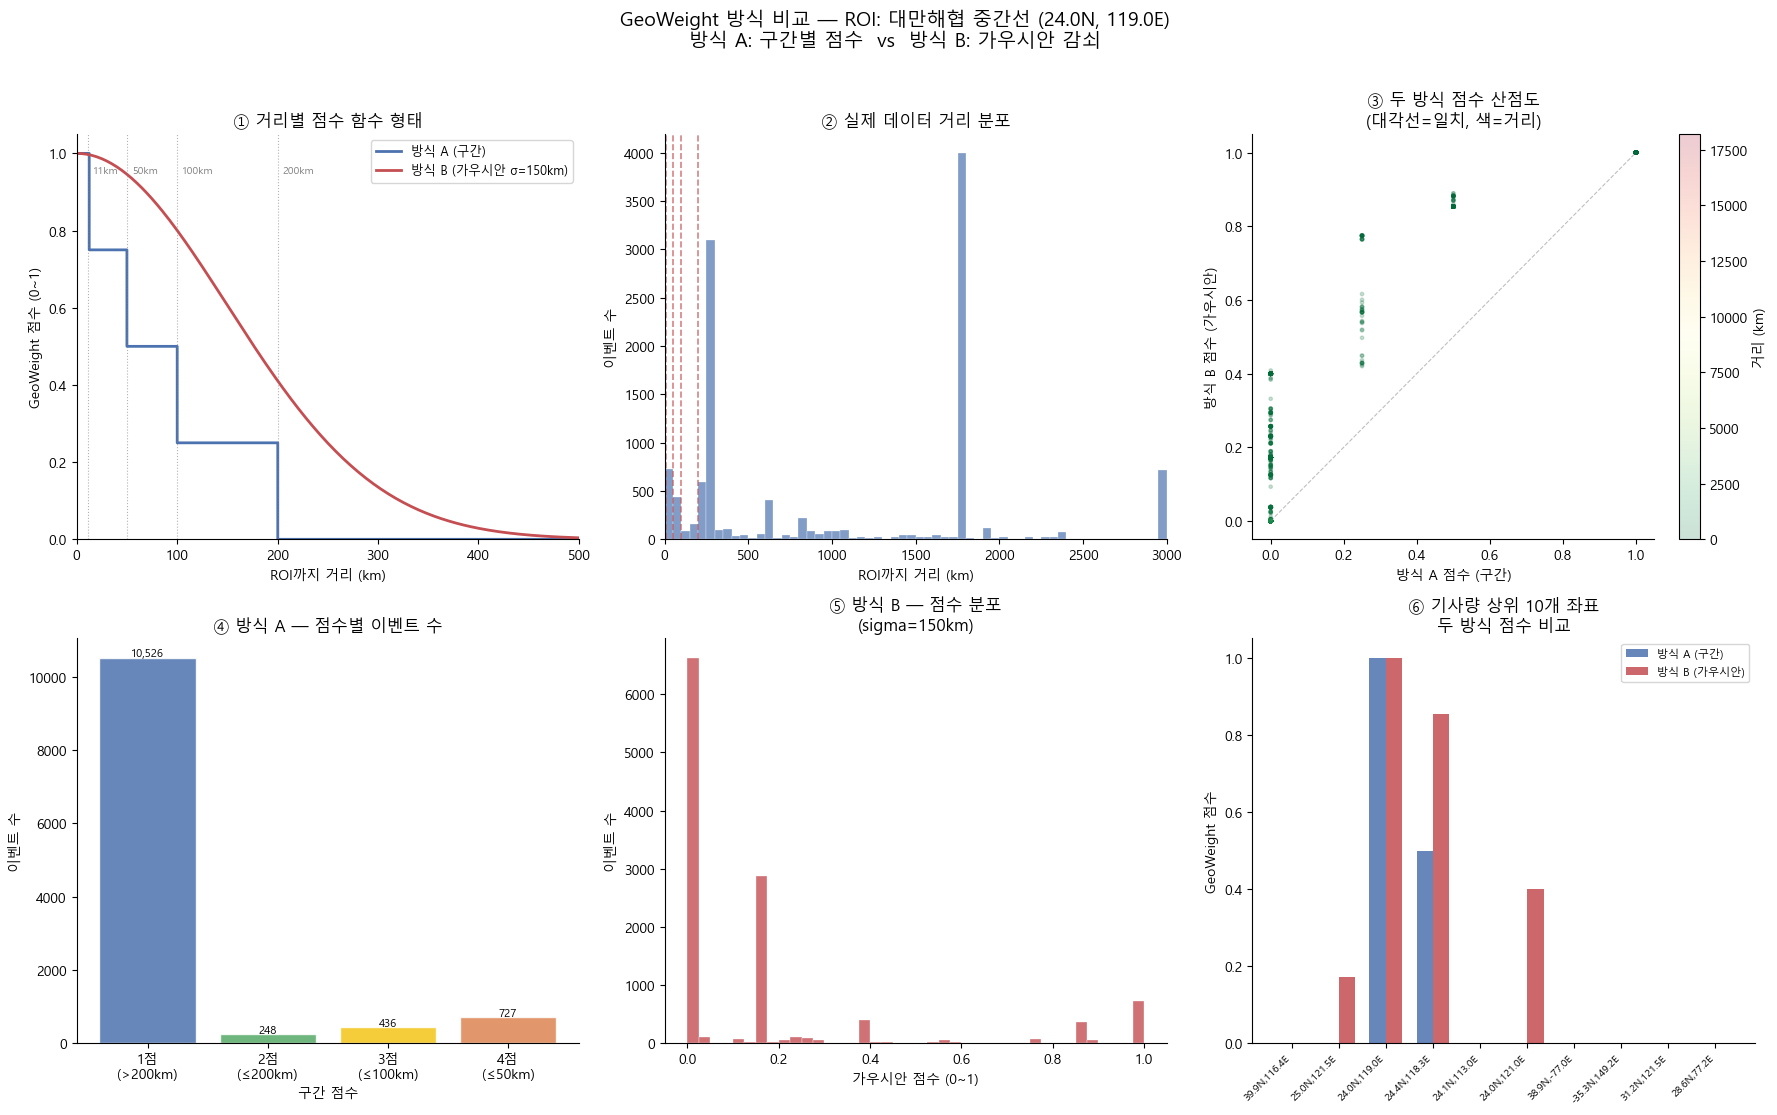

→ geoweight_comparison.png 저장 완료

두 방식 장단점 요약

방식 A — 구간별 점수 (Step Function)
  장점
    · 직관적 — "11km 이내면 5점" 설명하기 쉬움
    · 팀 합의로 구간·점수 조정 가능
    · 경계가 명확해서 디버깅 쉬움
  단점
    · 경계에서 점수가 급변 (49km=4점, 51km=3점)
    · 구간 수·경계 설정이 주관적
    · 새 ROI 추가 시 구간 재설정 필요

방식 B — 가우시안 감쇠 (Gaussian Decay)
  장점
    · 연속적 — 거리에 따라 부드럽게 감소
    · sigma 하나만 조정하면 됨
    · 경계 문제 없음 (49km ≠ 51km 급변 없음)
  단점
    · sigma 값 설정이 직관적이지 않음
    · 멀리 떨어진 좌표도 0이 되지 않음
      (2000km에서도 소량의 점수 존재)

현재 데이터 기준 권고
  · 이벤트 1,411건 (11.8%)이 200km 이내
  · 이벤트 6,565건 (55.0%)이 500km 초과
  → 원거리 이벤트가 많으면 방식 B가 자연스럽게 낮은 점수 부여
  → 팀 설명 용이성 기준이면 방식 A 권고
  → 스코어링 정밀도 기준이면 방식 B 권고



In [43]:
"""
GeoWeight 두 방식 비교
ROI 중심: 대만해협 중간선 (24.0N, 119.0E)

방식 A — 구간별 점수 (Step Function)
  11km 이내 → 5점
  50km 이내 → 4점
  100km 이내 → 3점
  200km 이내 → 2점
  200km 초과 → 1점

방식 B — 거리 기반 감쇠 (Gaussian Decay)
  중심에 가까울수록 연속적으로 높은 점수
  score = exp(-dist² / (2 * sigma²))
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.preprocessing import MinMaxScaler

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── 기준 ROI ────────────────────────────────────────────────────
ROI_LAT = 24.0
ROI_LON = 119.0
ROI_NAME = "대만해협 중간선"

# ── Haversine 거리 계산 ──────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2
         + np.cos(np.radians(lat1))
         * np.cos(np.radians(lat2))
         * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

# ── 거리 계산 ────────────────────────────────────────────────────
df["dist_km"] = haversine_km(
    df["ActionGeo_Lat"], df["ActionGeo_Long"],
    ROI_LAT, ROI_LON
)

# ════════════════════════════════════════════════════════════════
# 방식 A — 구간별 점수 (Step Function)
# ════════════════════════════════════════════════════════════════
STEP_BINS = [
    (11,   5),   # 11km 이내  → 5점
    (50,   4),   # 50km 이내  → 4점
    (100,  3),   # 100km 이내 → 3점
    (200,  2),   # 200km 이내 → 2점
    (np.inf, 1), # 200km 초과 → 1점
]

def step_score(dist_km):
    for threshold, score in STEP_BINS:
        if dist_km <= threshold:
            return score
    return 1

df["geo_step_raw"]  = df["dist_km"].apply(step_score)
df["geo_step_norm"] = (df["geo_step_raw"] - 1) / (5 - 1)  # 0~1 정규화


# ════════════════════════════════════════════════════════════════
# 방식 B — 가우시안 감쇠 (Gaussian Decay)
# ════════════════════════════════════════════════════════════════
# sigma: 이 거리에서 점수가 e^-0.5 ≈ 0.607배로 줄어드는 반경
SIGMA_KM = 150   # 150km 기준 감쇠 (조정 가능)

df["geo_gauss"] = np.exp(
    -df["dist_km"]**2 / (2 * SIGMA_KM**2)
)  # 이미 0~1 범위


# ════════════════════════════════════════════════════════════════
# 비교 분석
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print(f"GeoWeight 두 방식 비교 — ROI: {ROI_NAME} ({ROI_LAT}N, {ROI_LON}E)")
print("=" * 60)

# 거리 구간별 두 방식 점수 비교
dist_test = [0, 11, 30, 50, 80, 100, 150, 200, 300, 500, 1000, 2000]
print("\n[거리별 점수 비교]")
print(f"{'거리(km)':>10} {'방식A(구간)':>12} {'방식A(정규화)':>14} {'방식B(가우시안)':>16}")
print("-" * 56)
for d in dist_test:
    a_raw  = step_score(d)
    a_norm = (a_raw - 1) / (5 - 1)
    b      = np.exp(-d**2 / (2 * SIGMA_KM**2))
    print(f"{d:>10}  {a_raw:>10}점  {a_norm:>13.4f}  {b:>15.4f}")

# 실제 데이터 기초 통계
print(f"\n[실제 데이터 거리 분포]")
print(f"  전체 이벤트: {len(df):,}건")
print(f"  평균 거리:   {df['dist_km'].mean():.1f} km")
print(f"  중위수:      {df['dist_km'].median():.1f} km")
for d in [11, 50, 100, 200, 500]:
    cnt  = (df["dist_km"] <= d).sum()
    pct  = cnt / len(df) * 100
    print(f"  {d:>5}km 이내: {cnt:>5,}건 ({pct:.1f}%)")

print(f"\n[방식별 GeoWeight 통계]")
print(f"\n  방식 A (구간 점수 정규화)")
print(df["geo_step_norm"].describe().round(4).to_string())
print(f"\n  방식 B (가우시안 감쇠, sigma={SIGMA_KM}km)")
print(df["geo_gauss"].describe().round(4).to_string())

# 좌표별 두 방식 비교 (상위 20개 좌표)
coord_compare = df.groupby(["ActionGeo_Lat", "ActionGeo_Long"]).agg(
    dist_km      = ("dist_km",       "mean"),
    이벤트수     = ("NumMentions",   "count"),
    총기사량     = ("NumMentions",   "sum"),
    geo_step     = ("geo_step_norm", "mean"),
    geo_gauss    = ("geo_gauss",     "mean"),
).sort_values("총기사량", ascending=False).reset_index().head(20)

coord_compare["차이(A-B)"] = (
    coord_compare["geo_step"] - coord_compare["geo_gauss"]
).round(4)

print(f"\n[기사량 상위 20개 좌표 — 두 방식 점수 비교]")
print(coord_compare[["ActionGeo_Lat", "ActionGeo_Long", "dist_km",
                      "총기사량", "geo_step", "geo_gauss", "차이(A-B)"]
                    ].round(3).to_string(index=False))


# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f"GeoWeight 방식 비교 — ROI: {ROI_NAME} ({ROI_LAT}N, {ROI_LON}E)\n"
    "방식 A: 구간별 점수  vs  방식 B: 가우시안 감쇠",
    fontsize=14, y=1.01
)

x_dist = np.linspace(0, 2500, 1000)

# ── Chart 1: 거리별 점수 함수 비교 ──────────────────────────────
ax = axes[0][0]
# 방식 A
y_step = [(step_score(d) - 1) / 4 for d in x_dist]
ax.step(x_dist, y_step, where="post",
        color="#4C72B0", linewidth=2, label="방식 A (구간)")
# 방식 B
y_gauss = np.exp(-x_dist**2 / (2 * SIGMA_KM**2))
ax.plot(x_dist, y_gauss, color="#C44E52", linewidth=2,
        label=f"방식 B (가우시안 σ={SIGMA_KM}km)")
# 구간 경계 표시
for km in [11, 50, 100, 200]:
    ax.axvline(km, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.text(km + 5, 0.95, f"{km}km", fontsize=7.5, color="gray")
ax.set_xlabel("ROI까지 거리 (km)")
ax.set_ylabel("GeoWeight 점수 (0~1)")
ax.set_title("① 거리별 점수 함수 형태")
ax.legend(fontsize=9)
ax.set_xlim(0, 500)
ax.set_ylim(0, 1.05)

# ── Chart 2: 실제 데이터 거리 분포 ──────────────────────────────
ax = axes[0][1]
ax.hist(df["dist_km"].clip(upper=3000), bins=60,
        color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.3)
for km in [11, 50, 100, 200]:
    ax.axvline(km, color="#C44E52", linewidth=1.2,
               linestyle="--", alpha=0.7)
ax.set_xlabel("ROI까지 거리 (km)")
ax.set_ylabel("이벤트 수")
ax.set_title("② 실제 데이터 거리 분포")
ax.set_xlim(0, 3000)

# ── Chart 3: 두 방식 점수 산점도 ────────────────────────────────
ax = axes[0][2]
sample = df.sample(min(3000, len(df)), random_state=42)
sc = ax.scatter(sample["geo_step_norm"], sample["geo_gauss"],
                alpha=0.2, s=6, c=sample["dist_km"],
                cmap="RdYlGn_r")
plt.colorbar(sc, ax=ax, label="거리 (km)")
ax.plot([0, 1], [0, 1], color="gray", linewidth=0.8,
        linestyle="--", alpha=0.5)
ax.set_xlabel("방식 A 점수 (구간)")
ax.set_ylabel("방식 B 점수 (가우시안)")
ax.set_title("③ 두 방식 점수 산점도\n(대각선=일치, 색=거리)")

# ── Chart 4: 방식 A 점수 분포 ───────────────────────────────────
ax = axes[1][0]
step_counts = df["geo_step_raw"].value_counts().sort_index()
bars = ax.bar(step_counts.index.astype(str),
              step_counts.values,
              color=["#C44E52","#DD8452","#F4C518","#55A868","#4C72B0"][::-1],
              alpha=0.85, edgecolor="white")
for bar, (label, km) in zip(bars, [
    ("200km+", ">200"), ("~200km", "≤200"),
    ("~100km", "≤100"), ("~50km", "≤50"), ("~11km", "≤11")
]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f"{bar.get_height():,}", ha="center", fontsize=8)
ax.set_xlabel("구간 점수")
ax.set_ylabel("이벤트 수")
ax.set_title("④ 방식 A — 점수별 이벤트 수")
ax.set_xticklabels(["1점\n(>200km)", "2점\n(≤200km)",
                    "3점\n(≤100km)", "4점\n(≤50km)",  "5점\n(≤11km)"])

# ── Chart 5: 방식 B 점수 분포 ───────────────────────────────────
ax = axes[1][1]
ax.hist(df["geo_gauss"], bins=40,
        color="#C44E52", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.set_xlabel("가우시안 점수 (0~1)")
ax.set_ylabel("이벤트 수")
ax.set_title(f"⑤ 방식 B — 점수 분포\n(sigma={SIGMA_KM}km)")

# ── Chart 6: 상위 좌표 두 방식 점수 비교 ────────────────────────
ax = axes[1][2]
top10 = coord_compare.head(10).copy()
top10["좌표"] = (top10["ActionGeo_Lat"].round(1).astype(str)
                 + "N," + top10["ActionGeo_Long"].round(1).astype(str) + "E")
x = np.arange(len(top10))
w = 0.35
ax.bar(x - w/2, top10["geo_step"],  w,
       label="방식 A (구간)", color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, top10["geo_gauss"], w,
       label="방식 B (가우시안)", color="#C44E52", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top10["좌표"], rotation=45, ha="right", fontsize=7.5)
ax.set_ylabel("GeoWeight 점수")
ax.set_title("⑥ 기사량 상위 10개 좌표\n두 방식 점수 비교")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("geoweight_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ geoweight_comparison.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# 두 방식 장단점 요약
# ════════════════════════════════════════════════════════════════
print(f"""
{'=' * 60}
두 방식 장단점 요약
{'=' * 60}

방식 A — 구간별 점수 (Step Function)
  장점
    · 직관적 — "11km 이내면 5점" 설명하기 쉬움
    · 팀 합의로 구간·점수 조정 가능
    · 경계가 명확해서 디버깅 쉬움
  단점
    · 경계에서 점수가 급변 (49km=4점, 51km=3점)
    · 구간 수·경계 설정이 주관적
    · 새 ROI 추가 시 구간 재설정 필요

방식 B — 가우시안 감쇠 (Gaussian Decay)
  장점
    · 연속적 — 거리에 따라 부드럽게 감소
    · sigma 하나만 조정하면 됨
    · 경계 문제 없음 (49km ≠ 51km 급변 없음)
  단점
    · sigma 값 설정이 직관적이지 않음
    · 멀리 떨어진 좌표도 0이 되지 않음
      (2000km에서도 소량의 점수 존재)

현재 데이터 기준 권고
  · 이벤트 {(df['dist_km'] <= 200).sum():,}건 ({(df['dist_km'] <= 200).mean()*100:.1f}%)이 200km 이내
  · 이벤트 {(df['dist_km'] > 500).sum():,}건 ({(df['dist_km'] > 500).mean()*100:.1f}%)이 500km 초과
  → 원거리 이벤트가 많으면 방식 B가 자연스럽게 낮은 점수 부여
  → 팀 설명 용이성 기준이면 방식 A 권고
  → 스코어링 정밀도 기준이면 방식 B 권고
""")

GeoWeight 수정 버전 비교 — ROI: 대만해협 중간선 (24.0N, 119.0E)

[거리별 점수 비교]
    거리(km)     A-V2(구간)      A-V2(정규화)       B-V2(가우시안)
--------------------------------------------------------
         0           5점         1.0000           1.0000
        50           5점         1.0000           0.9862
       100           5점         1.0000           0.9460
       150           4점         0.7500           0.8825
       200           4점         0.7500           0.8007
       300           4점         0.7500           0.6065
       400           3점         0.5000           0.4111
       500           3점         0.5000           0.2494
       700           2점         0.2500           0.0657
      1000           2점         0.2500           0.0039
      1500           1점         0.0000           0.0000
      2000           1점         0.0000           0.0000

[방식 A V2 — 구간별 이벤트 수]
  5점 (    ≤100km): 1,163건 (9.7%)
  4점 (    ≤300km): 3,938건 (33.0%)
  3점 (    ≤500km):   271건 (2.3%)
  2점 (   ≤1000km): 1,000건 (8

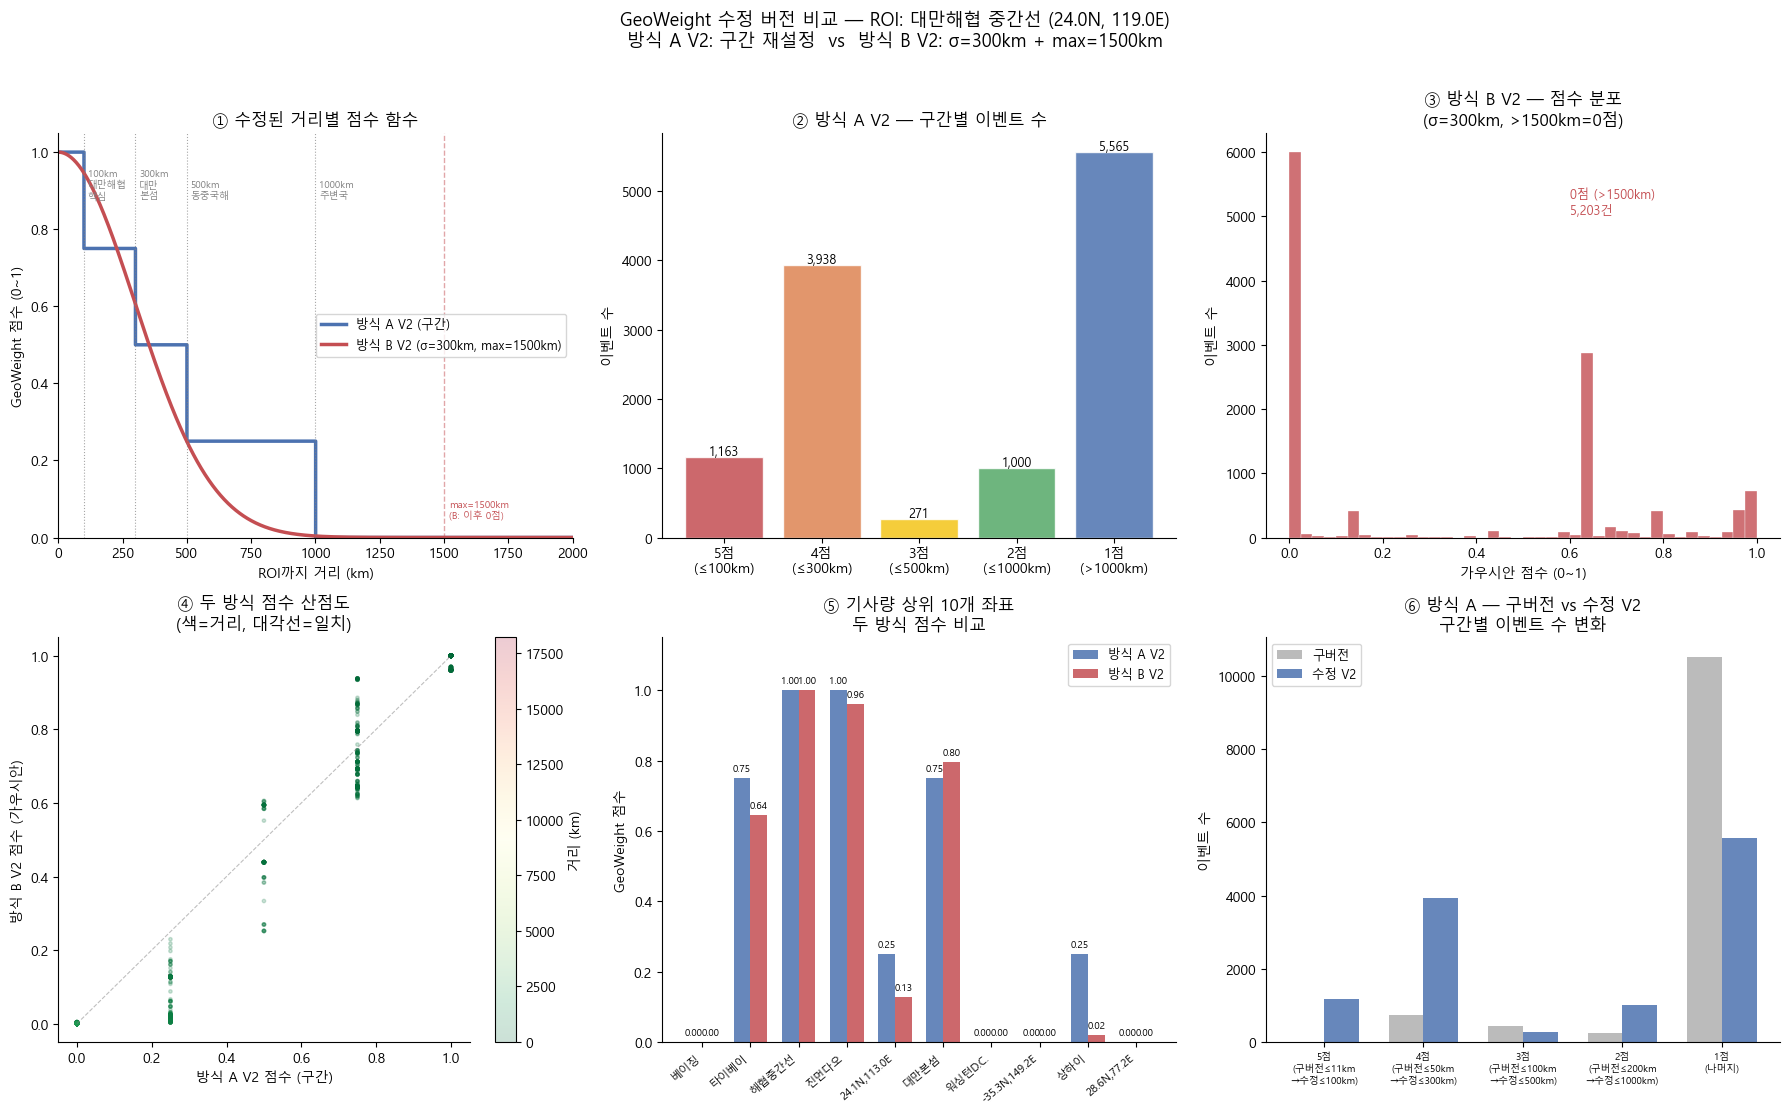

→ geoweight_comparison_v2.png 저장 완료

수정 버전 최종 요약

방식 A V2 — 구간 재설정
  구간      기준거리    점수   이벤트수   비율
  핵심      ≤100km     5점    1,163건   9.7%
  대만본섬  ≤300km     4점    3,938건   33.0%
  동중국해  ≤500km     3점      271건   2.3%
  주변국    ≤1000km    2점    1,000건   8.4%
  원거리    >1000km    1점    5,565건   46.6%

방식 B V2 — 가우시안 감쇠
  sigma=300km, >1500km 이후 0점 강제
  0점 이벤트: 5,203건 (43.6%)
  평균 점수: 0.3371
  중위수:    0.0248

진먼다오 (24.4N, 118.3E) 기준
  방식 A V2: 5점  
             → 정규화 1.0000
  방식 B V2: 0.9618



In [44]:
"""
GeoWeight 두 방식 수정 버전 비교
ROI 중심: 대만해협 중간선 (24.0N, 119.0E)

방식 A V2 — 실제 분포 기반 구간 재설정
  100km  이내 → 5점 (대만해협 핵심)
  300km  이내 → 4점 (대만 본섬·푸젠성)
  500km  이내 → 3점 (동중국해)
  1000km 이내 → 2점 (주변국)
  1000km 초과 → 1점

방식 B V2 — sigma 조정 + 최대 거리 임계값
  sigma=300km, 1500km 초과 → 0점 강제
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── 기준 ROI ────────────────────────────────────────────────────
ROI_LAT  = 24.0
ROI_LON  = 119.0
ROI_NAME = "대만해협 중간선"

# ── Haversine 거리 계산 ──────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

df["dist_km"] = haversine_km(
    df["ActionGeo_Lat"], df["ActionGeo_Long"],
    ROI_LAT, ROI_LON
)

# ════════════════════════════════════════════════════════════════
# 방식 A V2 — 실제 분포 기반 구간 재설정
# ════════════════════════════════════════════════════════════════
STEP_BINS_V2 = [
    (100,    5),   # 100km  이내 → 5점
    (300,    4),   # 300km  이내 → 4점
    (500,    3),   # 500km  이내 → 3점
    (1000,   2),   # 1000km 이내 → 2점
    (np.inf, 1),   # 초과        → 1점
]

def step_score_v2(dist):
    for threshold, score in STEP_BINS_V2:
        if dist <= threshold:
            return score
    return 1

df["geo_step_v2_raw"]  = df["dist_km"].apply(step_score_v2)
df["geo_step_v2_norm"] = (df["geo_step_v2_raw"] - 1) / (5 - 1)

# ════════════════════════════════════════════════════════════════
# 방식 B V2 — sigma 조정 + 최대 거리 임계값
# ════════════════════════════════════════════════════════════════
SIGMA_KM = 300    # 300km 기준 감쇠
MAX_DIST = 1500   # 1500km 초과 → 0점

df["geo_gauss_v2"] = np.where(
    df["dist_km"] <= MAX_DIST,
    np.exp(-df["dist_km"]**2 / (2 * SIGMA_KM**2)),
    0.0
)

# ════════════════════════════════════════════════════════════════
# 비교 분석 출력
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print(f"GeoWeight 수정 버전 비교 — ROI: {ROI_NAME} ({ROI_LAT}N, {ROI_LON}E)")
print("=" * 65)

# 거리별 점수 비교표
dist_test = [0, 50, 100, 150, 200, 300, 400, 500, 700, 1000, 1500, 2000]
print(f"\n[거리별 점수 비교]")
print(f"{'거리(km)':>10} {'A-V2(구간)':>12} {'A-V2(정규화)':>14} {'B-V2(가우시안)':>16}")
print("-" * 56)
for d in dist_test:
    a_raw  = step_score_v2(d)
    a_norm = (a_raw - 1) / 4
    b      = np.exp(-d**2 / (2*SIGMA_KM**2)) if d <= MAX_DIST else 0.0
    print(f"  {d:>8}  {a_raw:>10}점  {a_norm:>13.4f}  {b:>15.4f}")

# 구간별 이벤트 수 (V2)
print(f"\n[방식 A V2 — 구간별 이벤트 수]")
for threshold, score in STEP_BINS_V2:
    label = f"≤{threshold}km" if threshold != np.inf else ">1000km"
    cnt   = (df["geo_step_v2_raw"] == score).sum()
    pct   = cnt / len(df) * 100
    print(f"  {score}점 ({label:>10}): {cnt:>5,}건 ({pct:.1f}%)")

print(f"\n[방식별 GeoWeight 기초 통계]")
print(f"\n  방식 A V2 (구간 정규화)")
print(df["geo_step_v2_norm"].describe().round(4).to_string())
print(f"\n  방식 B V2 (가우시안 sigma={SIGMA_KM}km, max={MAX_DIST}km)")
print(df["geo_gauss_v2"].describe().round(4).to_string())

# 기사량 상위 20개 좌표 비교
coord_compare = df.groupby(["ActionGeo_Lat", "ActionGeo_Long"]).agg(
    dist_km      = ("dist_km",         "mean"),
    이벤트수     = ("NumMentions",      "count"),
    총기사량     = ("NumMentions",      "sum"),
    geo_step_v2  = ("geo_step_v2_norm", "mean"),
    geo_gauss_v2 = ("geo_gauss_v2",     "mean"),
).sort_values("총기사량", ascending=False).reset_index().head(20)

coord_compare["차이(A-B)"] = (
    coord_compare["geo_step_v2"] - coord_compare["geo_gauss_v2"]
).round(4)

print(f"\n[기사량 상위 20개 좌표 — 수정 버전 점수 비교]")
print(coord_compare[["ActionGeo_Lat", "ActionGeo_Long", "dist_km",
                      "총기사량", "geo_step_v2", "geo_gauss_v2", "차이(A-B)"]
                    ].round(3).to_string(index=False))

# 실제 지명 매핑 (주요 좌표)
GEO_LABELS = {
    (39.9, 116.4): "베이징",     (25.0, 121.5): "타이베이",
    (24.0, 119.0): "해협중간선", (24.4, 118.3): "진먼다오",
    (24.0, 121.0): "대만본섬",   (38.9, -77.0): "워싱턴D.C.",
    (26.5, 117.8): "푸젠성",     (15.0, 115.0): "남중국해",
    (21.4, 121.5): "바시해협",   (31.2, 121.5): "상하이",
}

# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f"GeoWeight 수정 버전 비교 — ROI: {ROI_NAME} ({ROI_LAT}N, {ROI_LON}E)\n"
    f"방식 A V2: 구간 재설정  vs  방식 B V2: σ={SIGMA_KM}km + max={MAX_DIST}km",
    fontsize=13, y=1.01
)

x_dist  = np.linspace(0, 2500, 1000)
y_step  = [(step_score_v2(d) - 1) / 4 for d in x_dist]
y_gauss = np.where(
    x_dist <= MAX_DIST,
    np.exp(-x_dist**2 / (2 * SIGMA_KM**2)),
    0.0
)

# ── Chart 1: 수정된 점수 함수 형태 ──────────────────────────────
ax = axes[0][0]
ax.step(x_dist, y_step, where="post",
        color="#4C72B0", linewidth=2.5, label="방식 A V2 (구간)")
ax.plot(x_dist, y_gauss, color="#C44E52", linewidth=2.5,
        label=f"방식 B V2 (σ={SIGMA_KM}km, max={MAX_DIST}km)")

# 구간 경계 + 지명 표시
boundaries = [(100, "대만해협\n핵심"), (300, "대만\n본섬"), (500, "동중국해"), (1000, "주변국")]
for km, label in boundaries:
    ax.axvline(km, color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
    ax.text(km + 15, 0.88, f"{km}km\n{label}",
            fontsize=7, color="gray", ha="left")
ax.axvline(MAX_DIST, color="#C44E52", linewidth=1, linestyle="--", alpha=0.5)
ax.text(MAX_DIST + 20, 0.05, f"max={MAX_DIST}km\n(B: 이후 0점)",
        fontsize=7, color="#C44E52")

ax.set_xlabel("ROI까지 거리 (km)")
ax.set_ylabel("GeoWeight 점수 (0~1)")
ax.set_title("① 수정된 거리별 점수 함수")
ax.legend(fontsize=9)
ax.set_xlim(0, 2000)
ax.set_ylim(0, 1.05)

# ── Chart 2: 방식 A V2 구간별 이벤트 수 ─────────────────────────
ax = axes[0][1]
labels_a = ["5점\n(≤100km)", "4점\n(≤300km)", "3점\n(≤500km)",
            "2점\n(≤1000km)", "1점\n(>1000km)"]
counts_a = [(df["geo_step_v2_raw"] == s).sum() for s in [5, 4, 3, 2, 1]]
colors_a = ["#C44E52", "#DD8452", "#F4C518", "#55A868", "#4C72B0"]
bars     = ax.bar(labels_a, counts_a, color=colors_a, alpha=0.85,
                  edgecolor="white")
for bar, cnt in zip(bars, counts_a):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f"{cnt:,}", ha="center", fontsize=9)
ax.set_ylabel("이벤트 수")
ax.set_title("② 방식 A V2 — 구간별 이벤트 수")

# ── Chart 3: 방식 B V2 점수 분포 ────────────────────────────────
ax = axes[0][2]
ax.hist(df["geo_gauss_v2"], bins=40,
        color="#C44E52", alpha=0.8, edgecolor="white", linewidth=0.3)
zero_cnt = (df["geo_gauss_v2"] == 0).sum()
ax.text(0.6, ax.get_ylim()[1] * 0.8 if ax.get_ylim()[1] > 0 else 100,
        f"0점 (>{MAX_DIST}km)\n{zero_cnt:,}건",
        fontsize=9, color="#C44E52")
ax.set_xlabel("가우시안 점수 (0~1)")
ax.set_ylabel("이벤트 수")
ax.set_title(f"③ 방식 B V2 — 점수 분포\n(σ={SIGMA_KM}km, >{MAX_DIST}km=0점)")

# ── Chart 4: 두 방식 점수 산점도 ────────────────────────────────
ax = axes[1][0]
sample = df.sample(min(3000, len(df)), random_state=42)
sc = ax.scatter(sample["geo_step_v2_norm"], sample["geo_gauss_v2"],
                alpha=0.2, s=6, c=sample["dist_km"], cmap="RdYlGn_r")
plt.colorbar(sc, ax=ax, label="거리 (km)")
ax.plot([0, 1], [0, 1], color="gray", linewidth=0.8,
        linestyle="--", alpha=0.5)
ax.set_xlabel("방식 A V2 점수 (구간)")
ax.set_ylabel("방식 B V2 점수 (가우시안)")
ax.set_title("④ 두 방식 점수 산점도\n(색=거리, 대각선=일치)")

# ── Chart 5: 기사량 상위 10개 좌표 비교 ─────────────────────────
ax = axes[1][1]
top10 = coord_compare.head(10).copy()
top10["좌표"] = top10.apply(
    lambda r: GEO_LABELS.get(
        (round(r["ActionGeo_Lat"], 1), round(r["ActionGeo_Long"], 1)),
        f"{r['ActionGeo_Lat']:.1f}N,{r['ActionGeo_Long']:.1f}E"
    ), axis=1
)
x = np.arange(len(top10))
w = 0.35
ax.bar(x - w/2, top10["geo_step_v2"],  w,
       label="방식 A V2", color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, top10["geo_gauss_v2"], w,
       label="방식 B V2", color="#C44E52", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top10["좌표"], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("GeoWeight 점수")
ax.set_title("⑤ 기사량 상위 10개 좌표\n두 방식 점수 비교")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
# 점수 레이블
for i, row in top10.iterrows():
    idx = list(top10.index).index(i)
    ax.text(idx - w/2, row["geo_step_v2"]  + 0.02,
            f"{row['geo_step_v2']:.2f}",  ha="center", fontsize=7)
    ax.text(idx + w/2, row["geo_gauss_v2"] + 0.02,
            f"{row['geo_gauss_v2']:.2f}", ha="center", fontsize=7)

# ── Chart 6: 구버전 vs 수정 버전 비교 (방식 A) ──────────────────
ax = axes[1][2]
labels_cmp = ["5점\n(구버전≤11km\n→수정≤100km)",
               "4점\n(구버전≤50km\n→수정≤300km)",
               "3점\n(구버전≤100km\n→수정≤500km)",
               "2점\n(구버전≤200km\n→수정≤1000km)",
               "1점\n(나머지)"]

# 구버전 기준 (이전 실행 결과)
counts_old = [0, 727, 436, 248, 10526]  # 이전 결과값
counts_new = [(df["geo_step_v2_raw"] == s).sum() for s in [5, 4, 3, 2, 1]]

x   = np.arange(len(labels_cmp))
w   = 0.35
ax.bar(x - w/2, counts_old, w, label="구버전", color="#AAAAAA", alpha=0.8)
ax.bar(x + w/2, counts_new, w, label="수정 V2", color="#4C72B0", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_cmp, fontsize=7)
ax.set_ylabel("이벤트 수")
ax.set_title("⑥ 방식 A — 구버전 vs 수정 V2\n구간별 이벤트 수 변화")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("geoweight_comparison_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ geoweight_comparison_v2.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# 최종 요약
# ════════════════════════════════════════════════════════════════
print(f"""
{'=' * 65}
수정 버전 최종 요약
{'=' * 65}

방식 A V2 — 구간 재설정
  구간      기준거리    점수   이벤트수   비율
  핵심      ≤100km     5점    {(df['geo_step_v2_raw']==5).sum():>5,}건   {(df['geo_step_v2_raw']==5).mean()*100:.1f}%
  대만본섬  ≤300km     4점    {(df['geo_step_v2_raw']==4).sum():>5,}건   {(df['geo_step_v2_raw']==4).mean()*100:.1f}%
  동중국해  ≤500km     3점    {(df['geo_step_v2_raw']==3).sum():>5,}건   {(df['geo_step_v2_raw']==3).mean()*100:.1f}%
  주변국    ≤1000km    2점    {(df['geo_step_v2_raw']==2).sum():>5,}건   {(df['geo_step_v2_raw']==2).mean()*100:.1f}%
  원거리    >1000km    1점    {(df['geo_step_v2_raw']==1).sum():>5,}건   {(df['geo_step_v2_raw']==1).mean()*100:.1f}%

방식 B V2 — 가우시안 감쇠
  sigma={SIGMA_KM}km, >{MAX_DIST}km 이후 0점 강제
  0점 이벤트: {(df['geo_gauss_v2']==0).sum():,}건 ({(df['geo_gauss_v2']==0).mean()*100:.1f}%)
  평균 점수: {df['geo_gauss_v2'].mean():.4f}
  중위수:    {df['geo_gauss_v2'].median():.4f}

진먼다오 (24.4N, 118.3E) 기준
  방식 A V2: {step_score_v2(haversine_km(24.4,118.3,ROI_LAT,ROI_LON))}점  
             → 정규화 {(step_score_v2(haversine_km(24.4,118.3,ROI_LAT,ROI_LON))-1)/4:.4f}
  방식 B V2: {np.exp(-haversine_km(24.4,118.3,ROI_LAT,ROI_LON)**2/(2*SIGMA_KM**2)):.4f}
""")

UNCLOS + ROC ADIZ 기반 GeoWeight — 대만해협 중간선 (24.0N, 119.0E)

[거리별 점수표]
구간           거리기준               법적근거                  점수
--------------------------------------------------------
  영해         ≤22.2km          UNCLOS 12해리            5
  접속수역       ≤44.4km          UNCLOS 24해리            4
  EEZ 내측     ≤88.9km          UNCLOS 48해리            3
  ADIZ 내측    ≤177.8km         ROC ADIZ 96해리          2
  ADIZ 외부    >177.8km         공해·원거리                 0

[구간별 이벤트 수·비율]
구간              점수       이벤트수       비율       총기사량      평균기사량
------------------------------------------------------------
  영해             5        727     6.1%     12,166       16.7
  접속수역           4          0     0.0%          0        0.0
  EEZ 내측         3        432     3.6%      4,896       11.3
  ADIZ 내측        2        202     1.7%      1,760        8.7
  ADIZ 외부        0     10,576    88.6%    139,653       13.2
------------------------------------------------------------
  ADIZ 내부 합계             1,361    11.4

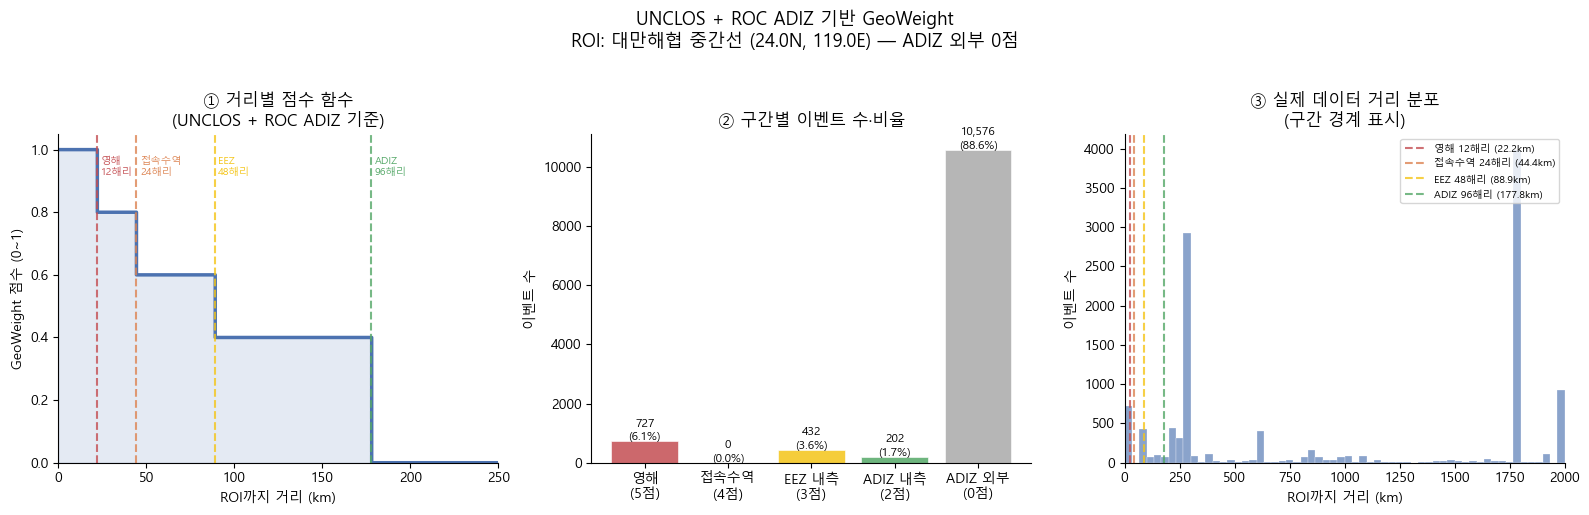

→ geoweight_adiz_stats.png 저장 완료

지도 생성 중...
→ geoweight_adiz_map.html 저장 완료 (브라우저에서 열어서 확인)

최종 요약
  ADIZ 내부 이벤트 (점수 > 0): 1,361건 (11.4%)
  ADIZ 외부 이벤트 (0점):      10,576건 (88.6%)

  GeoWeight 정규화 범위: 0.0 ~ 1.0
  (5점=1.0, 4점=0.8, 3점=0.6, 2점=0.4, 0점=0.0)

  스코어링 수식 (가중치 초안)
  Score = 0.7 × Vol_norm + 0.3 × GeoWeight



In [45]:
"""
UNCLOS + ROC ADIZ 기반 GeoWeight
ADIZ 외부 → 0점

확인 항목
  1. 구간별 이벤트 수·비율
  2. 지도 시각화 (folium)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import folium
from folium.plugins import HeatMap

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── 기준 ROI ────────────────────────────────────────────────────
ROI_LAT  = 24.0
ROI_LON  = 119.0
ROI_NAME = "대만해협 중간선"

# ── Haversine 거리 ───────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

df["dist_km"] = haversine_km(
    df["ActionGeo_Lat"], df["ActionGeo_Long"],
    ROI_LAT, ROI_LON
)

# ════════════════════════════════════════════════════════════════
# UNCLOS + ROC ADIZ 기반 GeoWeight
# ════════════════════════════════════════════════════════════════
# 해리 → km 변환
# 12해리 = 22.2km  (영해)
# 24해리 = 44.4km  (접속수역)
# 48해리 = 88.9km  (EEZ 내측)
# 96해리 = 177.8km (ROC ADIZ 내측)
# 96해리 초과 → 0점 (ADIZ 외부)

ADIZ_BINS = [
    (22.2,  5, "영해",        "UNCLOS 12해리",  "#C44E52"),
    (44.4,  4, "접속수역",    "UNCLOS 24해리",  "#DD8452"),
    (88.9,  3, "EEZ 내측",    "UNCLOS 48해리",  "#F4C518"),
    (177.8, 2, "ADIZ 내측",   "ROC ADIZ 96해리","#55A868"),
    (np.inf,0, "ADIZ 외부",   "공해·원거리",    "#AAAAAA"),
]

def adiz_score(dist):
    for threshold, score, *_ in ADIZ_BINS:
        if dist <= threshold:
            return score
    return 0

def adiz_zone(dist):
    for threshold, score, zone, *_ in ADIZ_BINS:
        if dist <= threshold:
            return zone
    return "ADIZ 외부"

df["geo_adiz_score"] = df["dist_km"].apply(adiz_score)
df["geo_adiz_norm"]  = df["geo_adiz_score"] / 5   # 0~1 정규화
df["geo_adiz_zone"]  = df["dist_km"].apply(adiz_zone)

# ════════════════════════════════════════════════════════════════
# 1. 구간별 이벤트 수·비율
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print(f"UNCLOS + ROC ADIZ 기반 GeoWeight — {ROI_NAME} ({ROI_LAT}N, {ROI_LON}E)")
print("=" * 65)

print(f"\n[거리별 점수표]")
print(f"{'구간':<12} {'거리기준':<18} {'법적근거':<18} {'점수':>5}")
print("-" * 56)
for threshold, score, zone, basis, _ in ADIZ_BINS:
    km_str = f"≤{threshold:.1f}km" if threshold != np.inf else ">177.8km"
    print(f"  {zone:<10} {km_str:<16} {basis:<18} {score:>5}")

print(f"\n[구간별 이벤트 수·비율]")
print(f"{'구간':<12} {'점수':>5} {'이벤트수':>10} {'비율':>8} "
      f"{'총기사량':>10} {'평균기사량':>10}")
print("-" * 60)

total = len(df)
zone_order = ["영해", "접속수역", "EEZ 내측", "ADIZ 내측", "ADIZ 외부"]
zone_stats  = df.groupby("geo_adiz_zone").agg(
    이벤트수  = ("NumMentions", "count"),
    총기사량  = ("NumMentions", "sum"),
    평균기사량 = ("NumMentions", "mean"),
).round(1)

adiz_total   = 0
adiz_events  = 0
for threshold, score, zone, basis, color in ADIZ_BINS:
    if zone not in zone_stats.index:
        print(f"  {zone:<10} {score:>5} {'0':>10} {'0.0%':>8} {'0':>10} {'0.0':>10}")
        continue
    row   = zone_stats.loc[zone]
    cnt   = int(row["이벤트수"])
    pct   = cnt / total * 100
    total_m = int(row["총기사량"])
    avg_m   = row["평균기사량"]
    print(f"  {zone:<10} {score:>5} {cnt:>10,} {pct:>7.1f}% "
          f"{total_m:>10,} {avg_m:>10.1f}")
    if score > 0:
        adiz_total  += total_m
        adiz_events += cnt

print("-" * 60)
adiz_pct = adiz_events / total * 100
print(f"  ADIZ 내부 합계        "
      f"{adiz_events:>10,} {adiz_pct:>7.1f}%")
print(f"  전체                  {total:>10,}  100.0%")

print(f"\n[주요 좌표 점수 확인]")
KEY_COORDS = [
    (24.0, 119.0, "대만해협 중간선 (ROI)"),
    (24.4, 118.3, "진먼다오"),
    (25.0, 121.5, "타이베이"),
    (24.0, 121.0, "대만 본섬"),
    (26.5, 117.8, "푸젠성"),
    (39.9, 116.4, "베이징"),
    (38.9, -77.0, "워싱턴 D.C."),
    (15.0, 115.0, "남중국해"),
]
print(f"{'지명':<22} {'거리(km)':>10} {'구간':>10} {'점수':>6}")
print("-" * 52)
for lat, lon, name in KEY_COORDS:
    dist  = haversine_km(lat, lon, ROI_LAT, ROI_LON)
    score = adiz_score(dist)
    zone  = adiz_zone(dist)
    print(f"  {name:<20} {dist:>10.1f} {zone:>10} {score:>6}")


# ════════════════════════════════════════════════════════════════
# matplotlib 시각화 — 구간별 통계
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"UNCLOS + ROC ADIZ 기반 GeoWeight\n"
    f"ROI: {ROI_NAME} ({ROI_LAT}N, {ROI_LON}E) — ADIZ 외부 0점",
    fontsize=13, y=1.02
)

zone_colors = {z: c for _, _, z, _, c in ADIZ_BINS}

# ── Chart 1: 거리별 점수 함수 ────────────────────────────────────
ax = axes[0]
x_dist = np.linspace(0, 300, 1000)
y_score = [adiz_score(d) / 5 for d in x_dist]
ax.step(x_dist, y_score, where="post", color="#4C72B0", linewidth=2.5)
ax.fill_between(x_dist, y_score, step="post", alpha=0.15, color="#4C72B0")

boundaries = [(22.2, "영해\n12해리"), (44.4, "접속수역\n24해리"),
              (88.9, "EEZ\n48해리"), (177.8, "ADIZ\n96해리")]
colors_b   = ["#C44E52", "#DD8452", "#F4C518", "#55A868"]
for (km, label), color in zip(boundaries, colors_b):
    ax.axvline(km, color=color, linewidth=1.5, linestyle="--", alpha=0.8)
    ax.text(km + 2, 0.92, label, fontsize=7.5, color=color, ha="left")

ax.set_xlabel("ROI까지 거리 (km)")
ax.set_ylabel("GeoWeight 점수 (0~1)")
ax.set_title("① 거리별 점수 함수\n(UNCLOS + ROC ADIZ 기준)")
ax.set_xlim(0, 250)
ax.set_ylim(0, 1.05)

# ── Chart 2: 구간별 이벤트 수 ────────────────────────────────────
ax = axes[1]
zone_cnt  = []
zone_lbl  = []
zone_clr  = []
for _, score, zone, _, color in ADIZ_BINS:
    cnt = (df["geo_adiz_zone"] == zone).sum()
    zone_cnt.append(cnt)
    zone_lbl.append(f"{zone}\n({score}점)")
    zone_clr.append(color)

bars = ax.bar(zone_lbl, zone_cnt, color=zone_clr, alpha=0.85,
              edgecolor="white", linewidth=0.5)
for bar, cnt in zip(bars, zone_cnt):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", fontsize=8.5)
ax.set_ylabel("이벤트 수")
ax.set_title("② 구간별 이벤트 수·비율")

# ── Chart 3: 실제 데이터 거리 분포 + 구간 경계 ───────────────────
ax = axes[2]
ax.hist(df["dist_km"].clip(upper=2000), bins=60,
        color="#4C72B0", alpha=0.65, edgecolor="white", linewidth=0.3)
for (km, label), color in zip(boundaries, colors_b):
    ax.axvline(km, color=color, linewidth=1.5, linestyle="--", alpha=0.8,
               label=f"{label.replace(chr(10), ' ')} ({km}km)")
ax.set_xlabel("ROI까지 거리 (km)")
ax.set_ylabel("이벤트 수")
ax.set_title("③ 실제 데이터 거리 분포\n(구간 경계 표시)")
ax.legend(fontsize=7.5, loc="upper right")
ax.set_xlim(0, 2000)

plt.tight_layout()
plt.savefig("geoweight_adiz_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ geoweight_adiz_stats.png 저장 완료")


# ════════════════════════════════════════════════════════════════
# 2. Folium 지도 시각화
# ════════════════════════════════════════════════════════════════
print("\n지도 생성 중...")

m = folium.Map(
    location=[24.0, 120.5],
    zoom_start=6,
    tiles="CartoDB positron"
)

# ── 동심원 (구간 경계) ───────────────────────────────────────────
circle_configs = [
    (177.8, "#55A868", "ROC ADIZ 내측 경계 (96해리, 177.8km) — 이 안에서만 점수 부여"),
    (88.9,  "#F4C518", "EEZ 내측 (48해리, 88.9km)"),
    (44.4,  "#DD8452", "접속수역 (24해리, 44.4km)"),
    (22.2,  "#C44E52", "영해 (12해리, 22.2km)"),
]
for radius_km, color, tooltip in circle_configs:
    folium.Circle(
        location=[ROI_LAT, ROI_LON],
        radius=radius_km * 1000,
        color=color,
        weight=2,
        fill=True,
        fill_color=color,
        fill_opacity=0.05,
        tooltip=tooltip,
    ).add_to(m)

# ── ROI 중심 마커 ────────────────────────────────────────────────
folium.Marker(
    location=[ROI_LAT, ROI_LON],
    popup=folium.Popup(f"ROI 중심: {ROI_NAME}<br>{ROI_LAT}N, {ROI_LON}E", max_width=200),
    tooltip="ROI 중심 (5점)",
    icon=folium.Icon(color="red", icon="star", prefix="fa"),
).add_to(m)

# ── 실제 이벤트 좌표 (구간별 색상) ─────────────────────────────
score_color_map = {
    5: "#C44E52",   # 영해
    4: "#DD8452",   # 접속수역
    3: "#F4C518",   # EEZ 내측
    2: "#55A868",   # ADIZ 내측
    0: "#CCCCCC",   # ADIZ 외부
}

# 좌표별 집계
coord_plot = df.groupby(
    ["ActionGeo_Lat", "ActionGeo_Long", "geo_adiz_score", "geo_adiz_zone"]
).agg(
    총기사량  = ("NumMentions", "sum"),
    이벤트수  = ("NumMentions", "count"),
).reset_index()

# ADIZ 내부만 CircleMarker, 외부는 반투명 처리
for _, row in coord_plot.iterrows():
    score   = int(row["geo_adiz_score"])
    color   = score_color_map.get(score, "#CCCCCC")
    opacity = 0.8 if score > 0 else 0.15
    radius  = min(3 + row["총기사량"] / 500, 15)

    folium.CircleMarker(
        location=[row["ActionGeo_Lat"], row["ActionGeo_Long"]],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=opacity,
        weight=0.5,
        tooltip=(
            f"좌표: {row['ActionGeo_Lat']:.2f}N, {row['ActionGeo_Long']:.2f}E<br>"
            f"구간: {row['geo_adiz_zone']} ({score}점)<br>"
            f"이벤트: {int(row['이벤트수'])}건<br>"
            f"총기사량: {int(row['총기사량'])}"
        ),
    ).add_to(m)

# ── 주요 지명 마커 ───────────────────────────────────────────────
for lat, lon, name in KEY_COORDS:
    dist  = haversine_km(lat, lon, ROI_LAT, ROI_LON)
    score = adiz_score(dist)
    zone  = adiz_zone(dist)
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(
            f"<b>{name}</b><br>거리: {dist:.1f}km<br>"
            f"구간: {zone}<br>점수: {score}점",
            max_width=180
        ),
        tooltip=f"{name} ({score}점)",
        icon=folium.Icon(
            color="gray" if score == 0 else "blue",
            icon="info-sign"
        ),
    ).add_to(m)

# ── 범례 ─────────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px; border-radius:8px;
     border:1px solid #ccc; font-size:12px; line-height:1.8;">
  <b>GeoWeight 구간 (UNCLOS + ROC ADIZ)</b><br>
  <span style="color:#C44E52;">●</span> 5점 — 영해 (≤22.2km, 12해리)<br>
  <span style="color:#DD8452;">●</span> 4점 — 접속수역 (≤44.4km, 24해리)<br>
  <span style="color:#F4C518;">●</span> 3점 — EEZ 내측 (≤88.9km, 48해리)<br>
  <span style="color:#55A868;">●</span> 2점 — ADIZ 내측 (≤177.8km, 96해리)<br>
  <span style="color:#CCCCCC;">●</span> 0점 — ADIZ 외부 (>177.8km)<br>
  <hr style="margin:4px 0;">
  <small>ROI 중심: 대만해협 중간선 (24.0N, 119.0E)</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# 저장
map_path = "geoweight_adiz_map.html"
m.save(map_path)
print(f"→ {map_path} 저장 완료 (브라우저에서 열어서 확인)")

# ── 최종 요약 ────────────────────────────────────────────────────
adiz_in  = (df["geo_adiz_score"] > 0).sum()
adiz_out = (df["geo_adiz_score"] == 0).sum()
print(f"""
{'=' * 65}
최종 요약
{'=' * 65}
  ADIZ 내부 이벤트 (점수 > 0): {adiz_in:,}건 ({adiz_in/total*100:.1f}%)
  ADIZ 외부 이벤트 (0점):      {adiz_out:,}건 ({adiz_out/total*100:.1f}%)

  GeoWeight 정규화 범위: 0.0 ~ 1.0
  (5점=1.0, 4점=0.8, 3점=0.6, 2점=0.4, 0점=0.0)

  스코어링 수식 (가중치 초안)
  Score = 0.7 × Vol_norm + 0.3 × GeoWeight
""")

GeoWeight 계산 중...
완료

GeoWeight — 대만해협 중간선 기준 UNCLOS 구간 (팀 확정)

[구간별 이벤트 수·비율]
구간                 점수       이벤트수       비율       총기사량      평균기사량
--------------------------------------------------------------
  12해리 이내         1.0        727     6.1%     12,166       16.7
  12~48해리         0.8        504     4.2%      5,454       10.8
  48~96해리         0.5      3,690    30.9%     41,458       11.2
  96~192해리        0.2        370     3.1%      4,178       11.3
  192해리 초과        0.1      6,646    55.7%     95,219       14.3
--------------------------------------------------------------
  유효 (>0점): 11,937건 (100.0%)    0점: 0건 (0.0%)

[주요 좌표 GeoWeight 점수]
지명                      중간선거리(km)             구간     점수
--------------------------------------------------------
  중간선 중심부                     0.0        12해리 이내    1.0
  진먼다오                       82.2        12~48해리    0.8
  타이베이                      112.1        48~96해리    0.5
  대만 본섬                     149.5        48~96해리    0.5
  푸젠성 

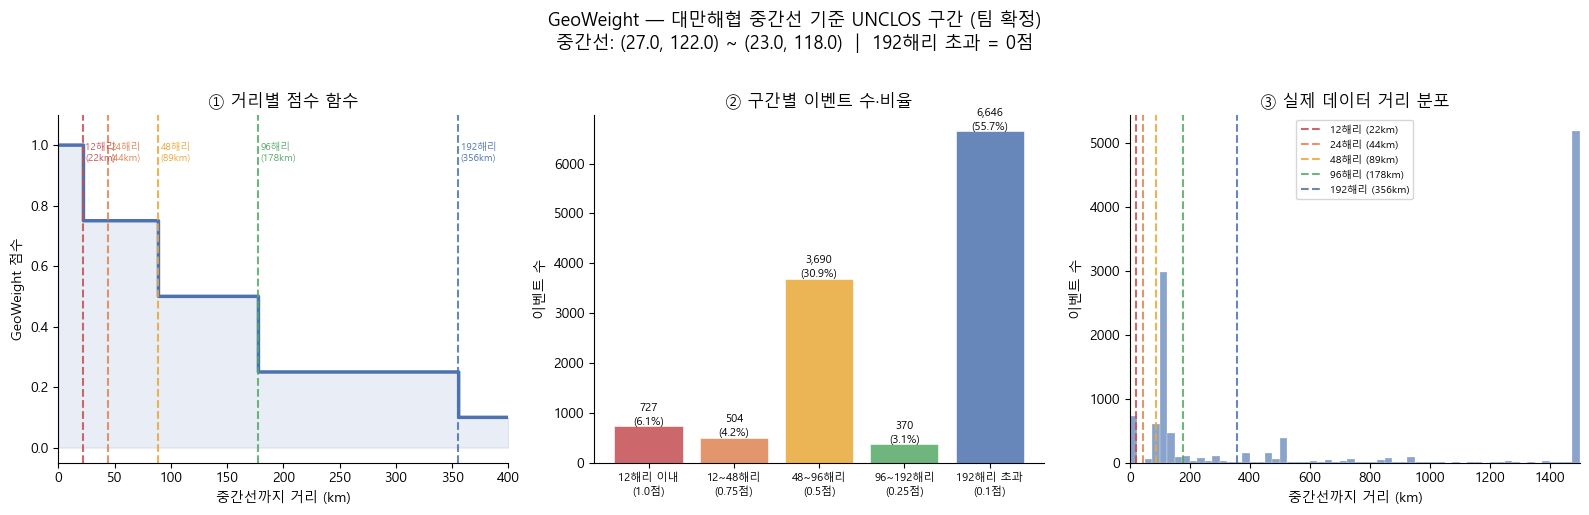

→ geoweight_median_line_v2.png 저장 완료

지도 생성 중...
→ geoweight_median_line_v2_map.html 저장 완료 (브라우저에서 확인)

최종 요약
  중간선: (27.0, 122.0) ~ (23.0, 118.0)
  유효 이벤트 (GeoWeight > 0): 11,937건 (100.0%)
  0점 이벤트 (192해리 초과):   0건  (0.0%)

  스코어링 수식 (가중치 초안)
  Score = 0.7 × Vol_norm + 0.3 × GeoWeight



In [47]:
"""
GeoWeight — 대만해협 중간선 기준 최단거리 + UNCLOS 구간 (팀 확정)
중간선: (27N, 122E) ~ (23N, 118E)

구간별 점수 (팀 확정)
  0  ~ 12해리 (  0  ~ 22.2km) → 1.0
  12 ~ 24해리 ( 22.2 ~ 44.4km) → 0.8
  24 ~ 48해리 ( 44.4 ~ 88.9km) → 0.6
  48 ~ 96해리 ( 88.9 ~ 177.8km) → 0.4
  96 ~192해리 (177.8 ~ 355.6km) → 0.2
  192해리 초과 (> 355.6km)       → 0.0
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import folium

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── 대만해협 중간선 ──────────────────────────────────────────────
MEDIAN_LINE_P1 = (27.0, 122.0)   # 북단
MEDIAN_LINE_P2 = (23.0, 118.0)   # 남단
NM_TO_KM       = 1.852

# ── 구간 정의 (팀 최종 확정) ────────────────────────────────────
# max_km: 22.2  → 1.00  (12해리 이내)
# max_km: 88.9  → 0.75  (12~48해리)
# max_km: 177.8 → 0.50  (48~96해리)
# max_km: 355.6 → 0.25  (96~192해리)
# max_km: 99999 → 0.10  (192해리 초과)
GEO_BINS = [
    (12,     12  * NM_TO_KM, 1.00, "12해리 이내",  "#C44E52"),
    (48,     48  * NM_TO_KM, 0.75, "12~48해리",    "#DD8452"),
    (96,     96  * NM_TO_KM, 0.50, "48~96해리",    "#E8A838"),
    (192,    192 * NM_TO_KM, 0.25, "96~192해리",   "#55A868"),
    (np.inf, np.inf,         0.10, "192해리 초과", "#4C72B0"),
]

# ── 선분까지 최단거리 계산 ───────────────────────────────────────
def dist_point_to_segment_km(lat, lon, p1, p2):
    lat_mid    = np.radians((p1[0] + p2[0]) / 2)
    km_per_lat = 111.32
    km_per_lon = 111.32 * np.cos(lat_mid)
    px = (lon   - p1[1]) * km_per_lon
    py = (lat   - p1[0]) * km_per_lat
    bx = (p2[1] - p1[1]) * km_per_lon
    by = (p2[0] - p1[0]) * km_per_lat
    ab2 = bx**2 + by**2
    if ab2 == 0:
        return np.sqrt(px**2 + py**2)
    t  = max(0.0, min(1.0, (px * bx + py * by) / ab2))
    cx = t * bx
    cy = t * by
    return np.sqrt((px - cx)**2 + (py - cy)**2)

def geo_weight_score(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return 0.0
    dist = dist_point_to_segment_km(lat, lon, MEDIAN_LINE_P1, MEDIAN_LINE_P2)
    for _, km_thresh, score, *_ in GEO_BINS:
        if dist <= km_thresh:
            return score
    return 0.0

def geo_weight_zone(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return "192해리 초과"
    dist = dist_point_to_segment_km(lat, lon, MEDIAN_LINE_P1, MEDIAN_LINE_P2)
    for _, km_thresh, _, zone, _ in GEO_BINS:
        if dist <= km_thresh:
            return zone
    return "192해리 초과"

def geo_dist_km(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return np.nan
    return dist_point_to_segment_km(lat, lon, MEDIAN_LINE_P1, MEDIAN_LINE_P2)

# ── df 적용 ──────────────────────────────────────────────────────
print("GeoWeight 계산 중...")
df["geo_dist_km"] = df.apply(
    lambda r: geo_dist_km(r["ActionGeo_Lat"], r["ActionGeo_Long"]), axis=1)
df["geo_weight"]  = df.apply(
    lambda r: geo_weight_score(r["ActionGeo_Lat"], r["ActionGeo_Long"]), axis=1)
df["geo_zone"]    = df.apply(
    lambda r: geo_weight_zone(r["ActionGeo_Lat"], r["ActionGeo_Long"]), axis=1)
print("완료")

total   = len(df)
nonzero = (df["geo_weight"] > 0).sum()
zero    = (df["geo_weight"] == 0).sum()

# ── 구간별 통계 출력 ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("GeoWeight — 대만해협 중간선 기준 UNCLOS 구간 (팀 확정)")
print("=" * 65)
print(f"\n[구간별 이벤트 수·비율]")
print(f"{'구간':<14} {'점수':>6} {'이벤트수':>10} {'비율':>8} "
      f"{'총기사량':>10} {'평균기사량':>10}")
print("-" * 62)
zone_stats = df.groupby("geo_zone").agg(
    이벤트수   = ("NumMentions", "count"),
    총기사량   = ("NumMentions", "sum"),
    평균기사량 = ("NumMentions", "mean"),
).round(1)
score_map = {z: s for _, _, s, z, _ in GEO_BINS}
for _, _, score, zone, _ in GEO_BINS:
    if zone not in zone_stats.index:
        print(f"  {zone:<12} {score:>6.1f} {'0':>10} {'0.0%':>8} "
              f"{'0':>10} {'0.0':>10}")
        continue
    row = zone_stats.loc[zone]
    cnt = int(row["이벤트수"])
    pct = cnt / total * 100
    print(f"  {zone:<12} {score:>6.1f} {cnt:>10,} {pct:>7.1f}% "
          f"{int(row['총기사량']):>10,} {row['평균기사량']:>10.1f}")
print("-" * 62)
print(f"  유효 (>0점): {nonzero:,}건 ({nonzero/total*100:.1f}%)  "
      f"  0점: {zero:,}건 ({zero/total*100:.1f}%)")

KEY_COORDS = [
    (25.0, 120.0, "중간선 중심부"),
    (24.4, 118.3, "진먼다오"),
    (25.0, 121.5, "타이베이"),
    (24.0, 121.0, "대만 본섬"),
    (26.5, 117.8, "푸젠성"),
    (26.1, 119.3, "푸저우"),
    (39.9, 116.4, "베이징"),
    (38.9, -77.0, "워싱턴 D.C."),
]
print(f"\n[주요 좌표 GeoWeight 점수]")
print(f"{'지명':<18} {'중간선거리(km)':>14} {'구간':>14} {'점수':>6}")
print("-" * 56)
for lat, lon, name in KEY_COORDS:
    dist  = geo_dist_km(lat, lon)
    score = geo_weight_score(lat, lon)
    zone  = geo_weight_zone(lat, lon)
    print(f"  {name:<16} {dist:>14.1f} {zone:>14} {score:>6.1f}")


# ════════════════════════════════════════════════════════════════
# matplotlib 시각화
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "GeoWeight — 대만해협 중간선 기준 UNCLOS 구간 (팀 확정)\n"
    f"중간선: {MEDIAN_LINE_P1} ~ {MEDIAN_LINE_P2}  |  192해리 초과 = 0점",
    fontsize=13, y=1.02
)

# ── Chart 1: 거리별 점수 함수 ────────────────────────────────────
ax    = axes[0]
x_d   = np.linspace(0, 400, 2000)
y_s   = []
for d in x_d:
    for _, km_t, sc, *_ in GEO_BINS:
        if d <= km_t:
            y_s.append(sc)
            break
ax.step(x_d, y_s, where="post", color="#4C72B0", linewidth=2.5)
ax.fill_between(x_d, y_s, step="post", alpha=0.12, color="#4C72B0")
nm_list = [12, 24, 48, 96, 192]
for nm, (_, _, _, _, color) in zip(nm_list, GEO_BINS):
    km = nm * NM_TO_KM
    ax.axvline(km, color=color, linewidth=1.5, linestyle="--", alpha=0.85)
    ax.text(km + 2, 0.95, f"{nm}해리\n({km:.0f}km)",
            fontsize=7, color=color, ha="left")
ax.set_xlabel("중간선까지 거리 (km)")
ax.set_ylabel("GeoWeight 점수")
ax.set_title("① 거리별 점수 함수")
ax.set_xlim(0, 400)
ax.set_ylim(-0.05, 1.1)

# ── Chart 2: 구간별 이벤트 수 ────────────────────────────────────
ax = axes[1]
cnt_list, lbl_list, clr_list = [], [], []
for _, _, score, zone, color in GEO_BINS:
    cnt_list.append((df["geo_zone"] == zone).sum())
    lbl_list.append(f"{zone}\n({score}점)")
    clr_list.append(color)
bars = ax.bar(lbl_list, cnt_list, color=clr_list,
              alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, cnt in zip(bars, cnt_list):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=8)
ax.set_ylabel("이벤트 수")
ax.set_title("② 구간별 이벤트 수·비율")
ax.tick_params(axis="x", labelsize=8)

# ── Chart 3: 실제 거리 분포 ──────────────────────────────────────
ax = axes[2]
ax.hist(df["geo_dist_km"].clip(upper=1500), bins=60,
        color="#4C72B0", alpha=0.65, edgecolor="white", linewidth=0.3)
for nm, (_, _, _, _, color) in zip(nm_list, GEO_BINS):
    km = nm * NM_TO_KM
    ax.axvline(km, color=color, linewidth=1.5, linestyle="--", alpha=0.85,
               label=f"{nm}해리 ({km:.0f}km)")
ax.set_xlabel("중간선까지 거리 (km)")
ax.set_ylabel("이벤트 수")
ax.set_title("③ 실제 데이터 거리 분포")
ax.legend(fontsize=7.5)
ax.set_xlim(0, 1500)

plt.tight_layout()
plt.savefig("geoweight_median_line_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ geoweight_median_line_v2.png 저장 완료")


# ════════════════════════════════════════════════════════════════
# Folium 지도 — 중간선 + 구간선 + 이벤트
# ════════════════════════════════════════════════════════════════
print("\n지도 생성 중...")

m = folium.Map(location=[24.5, 120.5], zoom_start=6,
               tiles="CartoDB positron")

# ── 구간선 생성 함수 ─────────────────────────────────────────────
def offset_parallel_lines(p1, p2, dist_km, n_points=80):
    """
    중간선 p1-p2에서 양쪽으로 dist_km만큼 떨어진 평행선 좌표 생성
    """
    lat_mid    = np.radians((p1[0] + p2[0]) / 2)
    km_per_lat = 111.32
    km_per_lon = 111.32 * np.cos(lat_mid)

    # 선분 방향 벡터
    dlat = (p2[0] - p1[0]) * km_per_lat
    dlon = (p2[1] - p1[1]) * km_per_lon
    length = np.sqrt(dlat**2 + dlon**2)

    # 법선 벡터 (수직 방향)
    nx = -dlat / length
    ny =  dlon / length

    # 양쪽 offset 좌표
    offset_lat = dist_km * nx / km_per_lat
    offset_lon = dist_km * ny / km_per_lon

    # 선분 위 등간격 점 생성
    t_vals = np.linspace(0, 1, n_points)
    line_pos = []
    line_neg = []
    for t in t_vals:
        lat_base = p1[0] + t * (p2[0] - p1[0])
        lon_base = p1[1] + t * (p2[1] - p1[1])
        line_pos.append((lat_base + offset_lat, lon_base + offset_lon))
        line_neg.append((lat_base - offset_lat, lon_base - offset_lon))

    return line_pos, line_neg

# ── 구간선 그리기 (양쪽) ────────────────────────────────────────
nm_bounds_draw = [12, 48, 96, 192]
bin_colors_map = {nm: c for nm, (_, _, _, _, c)
                  in zip(nm_bounds_draw, GEO_BINS)}
bin_labels_map = {
    12:  "12해리 (22.2km) — GeoWeight 1.0/0.8 경계",
    24:  "24해리 (44.4km) — GeoWeight 0.8/0.6 경계",
    48:  "48해리 (88.9km) — GeoWeight 0.6/0.4 경계",
    96:  "96해리 (177.8km) — GeoWeight 0.4/0.2 경계",
    192: "192해리 (355.6km) — GeoWeight 0.2/0.0 경계 (이후 0점)",
}

for nm in nm_bounds_draw:
    km     = nm * NM_TO_KM
    color  = bin_colors_map[nm]
    label  = bin_labels_map[nm]
    pos, neg = offset_parallel_lines(
        MEDIAN_LINE_P1, MEDIAN_LINE_P2, km)

    # 양쪽 평행선
    for line in [pos, neg]:
        folium.PolyLine(
            locations=line,
            color=color, weight=1.5,
            opacity=0.7, dash_array="6 4",
            tooltip=label,
        ).add_to(m)

    # 두 평행선을 잇는 영역 (fillOpacity 낮게)
    polygon_coords = pos + neg[::-1]
    folium.Polygon(
        locations=polygon_coords,
        color=color, weight=0,
        fill=True, fill_color=color,
        fill_opacity=0.06,
    ).add_to(m)

# ── 중간선 (가장 위에 그리기) ───────────────────────────────────
folium.PolyLine(
    locations=[MEDIAN_LINE_P1, MEDIAN_LINE_P2],
    color="#C44E52", weight=3.5, opacity=0.95,
    tooltip="대만해협 중간선 (27N,122E ~ 23N,118E)",
).add_to(m)
for pt, label in [(MEDIAN_LINE_P1, "중간선 북단 (27N, 122E)"),
                  (MEDIAN_LINE_P2, "중간선 남단 (23N, 118E)")]:
    folium.CircleMarker(
        location=pt, radius=6,
        color="#C44E52", fill=True,
        fill_color="#C44E52", fill_opacity=0.95,
        tooltip=label,
    ).add_to(m)

# ── 이벤트 좌표 ─────────────────────────────────────────────────
score_color_map = {
    1.00: "#C44E52", 0.75: "#DD8452", 0.50: "#E8A838",
    0.25: "#55A868", 0.10: "#4C72B0",
}
coord_plot = df.groupby(
    ["ActionGeo_Lat", "ActionGeo_Long", "geo_weight", "geo_zone"]
).agg(
    총기사량 = ("NumMentions", "sum"),
    이벤트수 = ("NumMentions", "count"),
).reset_index()

for _, row in coord_plot.iterrows():
    sc      = row["geo_weight"]
    color   = score_color_map.get(sc, "#CCCCCC")
    opacity = 0.85 if sc > 0 else 0.10
    radius  = min(3 + row["총기사량"] / 600, 14)
    folium.CircleMarker(
        location=[row["ActionGeo_Lat"], row["ActionGeo_Long"]],
        radius=radius,
        color=color, fill=True,
        fill_color=color, fill_opacity=opacity, weight=0.5,
        tooltip=(
            f"좌표: {row['ActionGeo_Lat']:.2f}N, "
            f"{row['ActionGeo_Long']:.2f}E<br>"
            f"구간: {row['geo_zone']} (GeoWeight={sc})<br>"
            f"이벤트: {int(row['이벤트수'])}건  "
            f"총기사량: {int(row['총기사량'])}"
        ),
    ).add_to(m)

# ── 주요 지명 마커 ───────────────────────────────────────────────
for lat, lon, name in KEY_COORDS:
    dist  = geo_dist_km(lat, lon)
    score = geo_weight_score(lat, lon)
    zone  = geo_weight_zone(lat, lon)
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(
            f"<b>{name}</b><br>중간선거리: {dist:.1f}km<br>"
            f"구간: {zone}<br>GeoWeight: {score}",
            max_width=180,
        ),
        tooltip=f"{name} (GeoWeight={score})",
        icon=folium.Icon(
            color="gray" if score == 0 else "blue",
            icon="info-sign"
        ),
    ).add_to(m)

# ── 범례 ─────────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     border:1px solid #ccc; font-size:12px; line-height:2.1;">
  <b>GeoWeight — 중간선 기준 UNCLOS (팀 확정)</b><br>
  <span style="color:#C44E52;">━━</span>
    <b>대만해협 중간선</b> (27N,122E ~ 23N,118E)<br>
  <hr style="margin:3px 0; border-color:#eee;">
  <span style="color:#C44E52;">● ┄</span>
    <b>1.00</b> — 12해리 이내 (≤22.2km)<br>
  <span style="color:#DD8452;">● ┄</span>
    <b>0.75</b> — 12~48해리 (22.2~88.9km)<br>
  <span style="color:#E8A838;">● ┄</span>
    <b>0.50</b> — 48~96해리 (88.9~177.8km)<br>
  <span style="color:#55A868;">● ┄</span>
    <b>0.25</b> — 96~192해리 (177.8~355.6km)<br>
  <span style="color:#4C72B0;">●</span>
    <b>0.10</b> — 192해리 초과 (>355.6km)<br>
  <hr style="margin:3px 0; border-color:#eee;">
  <small>출처: ROC 국방부 ADIZ + UNCLOS</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = "geoweight_median_line_v2_map.html"
m.save(map_path)
print(f"→ {map_path} 저장 완료 (브라우저에서 확인)")

print(f"""
{'=' * 65}
최종 요약
{'=' * 65}
  중간선: {MEDIAN_LINE_P1} ~ {MEDIAN_LINE_P2}
  유효 이벤트 (GeoWeight > 0): {nonzero:,}건 ({nonzero/total*100:.1f}%)
  0점 이벤트 (192해리 초과):   {zero:,}건  ({zero/total*100:.1f}%)

  스코어링 수식 (가중치 초안)
  Score = 0.7 × Vol_norm + 0.3 × GeoWeight
""")

# TLE 수집 및  Open-Meteo 기상 수집

In [36]:
"""
TLE + Open-Meteo 기상 데이터 수집 파이프라인
Step 1 — TLE 수집 및 궤도 계산 (위성 통과 시간)
Step 2 — Open-Meteo 기상 데이터 수집 (시간별 운량)
Step 3 — 두 데이터 연결 (통과 시간 + 운량 → 촬영 가능 여부)

임시 ROI: 대만해협 중간선 (24.0N, 119.0E)
기간: 최근 7일
위성: SpaceEye-T1 (SAR) + Sentinel-1 (SAR) + Planet (광학)
"""

import requests # Open-Meteo 기상 API 전용 라이브러리
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, timezone # 파이썬 표준 시간 관리 도구
from sgp4.api import Satrec, jday #위성 역학의 핵심 엔진, Satrec 위성 객체로 변환하여 궤도 계산, 우리가 쓰는 시간을 위성 계산용 시간 체계인 '율리우스 적일(Julian Day)'로 변경
import openmeteo_requests # 기상 데이터를 요청할 때 똑같은 데이터를 반복해서 받지 않도록 로컬에 임시 저장(캐싱)
import requests_cache # 파이썬에서 인터넷 통해 데이터 주고 받는 도구, TLE 데이터 긁어올 때 사용
from retry_requests import retry

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════

# 임시 ROI — 대만해협 중간선 (추후 확정 후 교체)
ROI = {
    "name":    "대만해협 중간선 (임시)",
    "lat":     24.0,
    "lon":     119.0,
    "elev_m":  0,
}

# 분석 기간 — 최근 7일
END_DT   = datetime.now(timezone.utc)
START_DT = END_DT - timedelta(days=7)

# 촬영 가능 운량 임계값 (광학 기준)
CLOUD_THRESHOLD_OPT = 30   # 광학: 30% 이하
CLOUD_THRESHOLD_SAR = 100  # SAR: 운량 무관 (항상 촬영 가능)

# 위성 통과 판정 기준
MIN_ELEVATION_DEG = 30     # 지평선 30° 이상일 때만 유효 통과
PASS_INTERVAL_MIN = 1      # 궤도 계산 간격 (분)

print("=" * 65)
print("TLE + Open-Meteo 파이프라인 초기화")
print(f"ROI: {ROI['name']} ({ROI['lat']}N, {ROI['lon']}E)")
print(f"기간: {START_DT.strftime('%Y-%m-%d')} ~ {END_DT.strftime('%Y-%m-%d')}")
print("=" * 65)


# ════════════════════════════════════════════════════════════════
# Step 1 — TLE 수집 및 궤도 계산
# ════════════════════════════════════════════════════════════════
print("\n[Step 1] TLE 수집 및 궤도 계산")

# ── 위성 정의 ────────────────────────────────────────────────────
# Celestrak URL 또는 직접 TLE 문자열로 정의
SATELLITES = {
    # SAR 위성
    "SpaceEye-T1": {
        "type": "SAR",
        "tle": (
            "SPACEEYE-T1             ",
            "1 63229U 25052V   26132.96459548  .00002987  00000+0  13324-3 0  9991",
            "2 63229  97.3994  26.0776 0002968 277.8801  82.2098 15.22166091 64485",
        ),
        "source": "직접입력",
    },
    "Sentinel-1A": {
        "type": "SAR",
        "url":  "https://celestrak.org/NORAD/elements/gp.php?CATNR=39634&FORMAT=tle",
        "source": "Celestrak",
    },
    # 광학 위성 (Planet 그룹에서 대표 위성)
    "Planet-Flock": {
        "type": "OPT",
        "url":  "https://celestrak.org/NORAD/elements/gp.php?GROUP=planet&FORMAT=tle",
        "source": "Celestrak",
        "max_load": 5,   # Planet은 위성이 많아서 5기만 로드
    },
}

def fetch_tle_from_url(url, max_load=None):
    """Celestrak URL에서 TLE 가져오기"""
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        lines = [l.strip() for l in r.text.strip().splitlines() if l.strip()]
        # TLE 3줄 세트로 파싱
        sats = []
        i = 0
        while i + 2 < len(lines):
            name = lines[i]
            l1   = lines[i+1]
            l2   = lines[i+2]
            if l1.startswith("1 ") and l2.startswith("2 "):
                sats.append((name, l1, l2))
                i += 3
            else:
                i += 1
            if max_load and len(sats) >= max_load:
                break
        return sats
    except Exception as e:
        print(f"  ⚠ TLE 수집 실패: {url} — {e}")
        return []

def haversine_km(lat1, lon1, lat2, lon2):
    """두 좌표 간 거리 (km)"""
    R = 6371.0
    d = np.radians
    dlat = d(lat2 - lat1)
    dlon = d(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(d(lat1)) * np.cos(d(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def compute_elevation(sat_lat, sat_lon, sat_alt_km, obs_lat, obs_lon):
    """위성의 관측 지점 기준 앙각(elevation) 계산"""
    dist_km  = haversine_km(obs_lat, obs_lon, sat_lat, sat_lon)
    if dist_km < 1:
        return 90.0
    elev_rad = np.arctan2(sat_alt_km - 0, dist_km)
    return np.degrees(elev_rad)

def find_passes(tle_tuple, roi, start_dt, end_dt, interval_min=1):
    """
    위성 통과 이벤트 탐지
    Returns: list of dict {time, lat, lon, alt_km, elevation_deg}
    """
    name, line1, line2 = tle_tuple
    try:
        sat = Satrec.twoline2rv(line1, line2)
    except Exception as e:
        print(f"  ⚠ TLE 파싱 실패 ({name}): {e}")
        return []

    passes   = []
    cur_dt   = start_dt
    dt_step  = timedelta(minutes=interval_min)
    in_pass  = False
    pass_buf = []

    while cur_dt <= end_dt:
        jd, fr = jday(cur_dt.year, cur_dt.month, cur_dt.day,
                      cur_dt.hour, cur_dt.minute, cur_dt.second)
        e, r, v = sat.sgp4(jd, fr)
        if e != 0:
            cur_dt += dt_step
            continue

        # ECI → 위도/경도/고도 (간단 변환)
        x, y, z   = r
        alt_km    = np.sqrt(x**2 + y**2 + z**2) - 6371.0
        lat_rad   = np.arctan2(z, np.sqrt(x**2 + y**2))
        lon_rad   = np.arctan2(y, x)

        # 지구 자전 보정 (GMST)
        jd_total  = jd + fr
        T         = (jd_total - 2451545.0) / 36525.0
        gmst_deg  = (280.46061837 + 360.98564736629 * (jd_total - 2451545.0)
                     + 0.000387933 * T**2) % 360
        lon_deg   = (np.degrees(lon_rad) - gmst_deg + 180) % 360 - 180
        lat_deg   = np.degrees(lat_rad)

        elev = compute_elevation(lat_deg, lon_deg, alt_km,
                                 roi["lat"], roi["lon"])

        if elev >= MIN_ELEVATION_DEG:
            pass_buf.append({
                "time":         cur_dt,
                "sat_lat":      round(lat_deg, 3),
                "sat_lon":      round(lon_deg, 3),
                "alt_km":       round(alt_km, 1),
                "elevation_deg": round(elev, 1),
            })
            in_pass = True
        else:
            if in_pass and pass_buf:
                # 통과 이벤트: 최대 앙각 시점 기록
                best = max(pass_buf, key=lambda x: x["elevation_deg"])
                passes.append(best)
                pass_buf = []
            in_pass = False

        cur_dt += dt_step

    return passes

# ── 위성별 TLE 로드 및 통과 계산 ─────────────────────────────────
all_passes = []

for sat_name, sat_cfg in SATELLITES.items():
    print(f"\n  [{sat_name}] ({sat_cfg['type']}) 처리 중...")

    # TLE 로드
    if "tle" in sat_cfg:
        tle_list = [sat_cfg["tle"]]
    else:
        tle_list = fetch_tle_from_url(
            sat_cfg["url"], sat_cfg.get("max_load"))

    if not tle_list:
        print(f"    ⚠ TLE 없음, 건너뜀")
        continue

    print(f"    TLE 로드: {len(tle_list)}기")

    # 통과 계산
    sat_passes = []
    for tle in tle_list:
        p = find_passes(tle, ROI, START_DT, END_DT, PASS_INTERVAL_MIN)
        sat_passes.extend(p)

    for p in sat_passes:
        p["satellite"] = sat_name
        p["type"]      = sat_cfg["type"]

    print(f"    통과 이벤트: {len(sat_passes)}회 "
          f"(앙각 ≥ {MIN_ELEVATION_DEG}°)")
    all_passes.extend(sat_passes)

# 데이터프레임 변환
passes_df = pd.DataFrame(all_passes)
if passes_df.empty:
    print("\n  ⚠ 통과 이벤트 없음 — ROI 좌표 또는 기간 확인 필요")
else:
    passes_df = passes_df.sort_values("time").reset_index(drop=True)
    print(f"\n  전체 통과 이벤트: {len(passes_df)}회")
    print(passes_df[["time", "satellite", "type",
                      "alt_km", "elevation_deg"]].head(10).to_string(index=False))


# ════════════════════════════════════════════════════════════════
# Step 2 — Open-Meteo 기상 데이터 수집
# ════════════════════════════════════════════════════════════════
print("\n\n[Step 2] Open-Meteo 기상 데이터 수집")

# Open-Meteo 클라이언트 설정 (캐시 + 재시도)
cache_session = requests_cache.CachedSession(".openmeteo_cache", expire_after=3600)
retry_session = retry(cache_session, retries=3, backoff_factor=0.3)
om_client     = openmeteo_requests.Client(session=retry_session)

def fetch_weather(lat, lon, start_date, end_date):
    """Open-Meteo Historical API로 시간별 운량 수집"""
    params = {
        "latitude":        lat,
        "longitude":       lon,
        "start_date":      start_date.strftime("%Y-%m-%d"),
        "end_date":        end_date.strftime("%Y-%m-%d"),
        "hourly":          ["cloud_cover",           # 전체 운량 (%)
                            "cloud_cover_low",        # 하층운
                            "cloud_cover_mid",        # 중층운
                            "cloud_cover_high",       # 상층운
                            "precipitation",          # 강수량
                            "visibility"],            # 가시거리 (m)
        "timezone":        "UTC",
        "models":          "era5",                   # ERA5 재분석 데이터
    }
    try:
        responses = om_client.weather_api(
            "https://archive-api.open-meteo.com/v1/archive", params=params)
        response  = responses[0]
        hourly    = response.Hourly()

        # 시간 인덱스 생성
        times = pd.date_range(
            start = pd.to_datetime(hourly.Time(),    unit="s", utc=True),
            end   = pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq  = pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        )
        weather_df = pd.DataFrame({
            "time":             times,
            "cloud_cover":      hourly.Variables(0).ValuesAsNumpy(),
            "cloud_cover_low":  hourly.Variables(1).ValuesAsNumpy(),
            "cloud_cover_mid":  hourly.Variables(2).ValuesAsNumpy(),
            "cloud_cover_high": hourly.Variables(3).ValuesAsNumpy(),
            "precipitation":    hourly.Variables(4).ValuesAsNumpy(),
            "visibility_m":     hourly.Variables(5).ValuesAsNumpy(),
        })
        return weather_df

    except Exception as e:
        print(f"  ⚠ Open-Meteo 수집 실패: {e}")
        return pd.DataFrame()

weather_df = fetch_weather(ROI["lat"], ROI["lon"], START_DT, END_DT)

if weather_df.empty:
    print("  ⚠ 기상 데이터 없음")
else:
    print(f"  수집 완료: {len(weather_df)}시간")
    print(f"  운량 평균: {weather_df['cloud_cover'].mean():.1f}%")
    print(f"  운량 범위: {weather_df['cloud_cover'].min():.0f}% ~ "
          f"{weather_df['cloud_cover'].max():.0f}%")
    print(f"\n  최근 24시간 운량:")
    print(weather_df.tail(24)[["time", "cloud_cover",
                                "precipitation", "visibility_m"]]
          .to_string(index=False))


# ════════════════════════════════════════════════════════════════
# Step 3 — 두 데이터 연결 (촬영 가능 여부 판단)
# ════════════════════════════════════════════════════════════════
print("\n\n[Step 3] TLE + 기상 데이터 연결 — 촬영 가능 여부 판단")

if passes_df.empty or weather_df.empty:
    print("  ⚠ 통과 이벤트 또는 기상 데이터 없음 — Step 3 건너뜀")
else:
    # 통과 시간 기준으로 가장 가까운 시간의 운량 매칭 (nearest join)
    passes_df["time"] = pd.to_datetime(passes_df["time"], utc=True)
    weather_df["time"] = pd.to_datetime(weather_df["time"], utc=True)

    passes_df = pd.merge_asof(
        passes_df.sort_values("time"),
        weather_df[["time", "cloud_cover", "precipitation",
                    "visibility_m"]].sort_values("time"),
        on="time",
        direction="nearest",
        tolerance=pd.Timedelta("1h"),
    )

    # 촬영 가능 여부 판단
    def can_image(row):
        if row["type"] == "SAR":
            return True   # SAR: 운량 무관
        else:
            return row["cloud_cover"] <= CLOUD_THRESHOLD_OPT

    passes_df["can_image"] = passes_df.apply(can_image, axis=1)
    passes_df["reason"]    = passes_df.apply(
        lambda r: "SAR — 운량 무관" if r["type"] == "SAR"
        else (f"광학 가능 (운량 {r['cloud_cover']:.0f}%)"
              if r["can_image"]
              else f"광학 불가 (운량 {r['cloud_cover']:.0f}%)"),
        axis=1,
    )

    # 요약 출력
    print(f"\n  전체 통과: {len(passes_df)}회")
    print(f"  촬영 가능: {passes_df['can_image'].sum()}회")
    print(f"  촬영 불가: {(~passes_df['can_image']).sum()}회")

    print(f"\n  [위성별 요약]")
    summary = passes_df.groupby(["satellite", "type"]).agg(
        통과횟수    = ("can_image", "count"),
        촬영가능    = ("can_image", "sum"),
        평균앙각    = ("elevation_deg", "mean"),
        평균운량    = ("cloud_cover", "mean"),
    ).round(1)
    print(summary.to_string())

    print(f"\n  [전체 통과 이벤트 — 최근 20개]")
    print(passes_df[["time", "satellite", "type", "elevation_deg",
                     "cloud_cover", "can_image", "reason"]]
          .tail(20).to_string(index=False))

    # CSV 저장
    out_path = "tle_weather_passes.csv"
    passes_df.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"\n  → {out_path} 저장 완료")


# ════════════════════════════════════════════════════════════════
# 파이프라인 검증 요약
# ════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 65)
print("파이프라인 검증 요약")
print("=" * 65)
print(f"""
Step 1 — TLE 수집·궤도 계산
  - SpaceEye-T1 (SAR): 직접 입력 TLE 사용
  - Sentinel-1A (SAR): Celestrak 수집
  - Planet-Flock (OPT): Celestrak 수집 (5기)
  - sgp4로 1분 간격 궤도 계산, 앙각 ≥ {MIN_ELEVATION_DEG}° 통과 이벤트 탐지

Step 2 — Open-Meteo 기상 수집
  - ERA5 재분석 데이터, 시간별 운량·강수·가시거리
  - ROI: {ROI['name']} ({ROI['lat']}N, {ROI['lon']}E)

Step 3 — 연결 및 촬영 가능 판단
  - 통과 시간 ± 1시간 이내 운량 매칭
  - 광학: 운량 ≤ {CLOUD_THRESHOLD_OPT}% → 촬영 가능
  - SAR (SpaceEye-T1, Sentinel-1): 운량 무관 → 항상 가능

다음 단계 (ROI·날짜 확정 후):
  - ROI 좌표를 GeoWeight 기준 핵심 지점으로 교체
  - 스파이크 날짜(2022-08-04 등) 기간으로 재실행 → 과거 검증
  - 향후 7일 예보 데이터로 전환 → 촬영 스케줄링 (Step B)
""")

TLE + Open-Meteo 파이프라인 초기화
ROI: 대만해협 중간선 (임시) (24.0N, 119.0E)
기간: 2026-05-07 ~ 2026-05-14

[Step 1] TLE 수집 및 궤도 계산

  [SpaceEye-T1] (SAR) 처리 중...
    TLE 로드: 1기
    통과 이벤트: 11회 (앙각 ≥ 30°)

  [Sentinel-1A] (SAR) 처리 중...
    TLE 로드: 1기
    통과 이벤트: 14회 (앙각 ≥ 30°)

  [Planet-Flock] (OPT) 처리 중...
    TLE 로드: 5기
    통과 이벤트: 52회 (앙각 ≥ 30°)

  전체 통과 이벤트: 77회
                            time    satellite type  alt_km  elevation_deg
2026-05-07 05:51:17.435544+00:00 Planet-Flock  OPT   607.4           36.2
2026-05-07 10:26:17.435544+00:00  Sentinel-1A  SAR   702.2           37.8
2026-05-07 12:03:17.435544+00:00 Planet-Flock  OPT   467.2           33.8
2026-05-07 12:26:17.435544+00:00 Planet-Flock  OPT   529.5           53.0
2026-05-07 14:27:17.435544+00:00  SpaceEye-T1  SAR   507.5           57.9
2026-05-07 19:21:17.435544+00:00 Planet-Flock  OPT   611.5           41.5
2026-05-07 22:33:17.435544+00:00  Sentinel-1A  SAR   701.5           63.9
2026-05-07 22:58:17.435544+00:00 Planet-Flock  OPT   43

In [37]:
# Step 2·3 결과만 별도로 확인
print("=== Step 2 기상 데이터 확인 ===")
print(f"weather_df 존재 여부: {'weather_df' in dir()}")
try:
    print(f"행 수: {len(weather_df)}")
    print(f"컬럼: {weather_df.columns.tolist()}")
    print(weather_df.tail(5).to_string())
except:
    print("weather_df 없음 — Step 2 실패")

print("\n=== Step 3 통과+기상 연결 결과 확인 ===")
try:
    print(f"passes_df 행 수: {len(passes_df)}")
    print(f"촬영 가능: {passes_df['can_image'].sum()}회")
    print(f"촬영 불가: {(~passes_df['can_image']).sum()}회")
    print("\n위성별 요약:")
    print(passes_df.groupby(["satellite", "type"]).agg(
        통과횟수=("can_image", "count"),
        촬영가능=("can_image", "sum"),
        평균앙각=("elevation_deg", "mean"),
        평균운량=("cloud_cover", "mean"),
    ).round(1).to_string())
    print("\n전체 목록 CSV 저장:")
    save_path = "C:/Users/user/Desktop/tle_weather_passes.csv"
    passes_df.to_csv(save_path, index=False, encoding="utf-8-sig")
    print(f"→ {save_path} 저장 완료")
except Exception as e:
    print(f"passes_df 없음 또는 오류 — {e}")

=== Step 2 기상 데이터 확인 ===
weather_df 존재 여부: True
행 수: 192
컬럼: ['time', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'precipitation', 'visibility_m']
                         time  cloud_cover  cloud_cover_low  cloud_cover_mid  cloud_cover_high  precipitation  visibility_m
187 2026-05-14 19:00:00+00:00          NaN              NaN              NaN               NaN            NaN           NaN
188 2026-05-14 20:00:00+00:00          NaN              NaN              NaN               NaN            NaN           NaN
189 2026-05-14 21:00:00+00:00          NaN              NaN              NaN               NaN            NaN           NaN
190 2026-05-14 22:00:00+00:00          NaN              NaN              NaN               NaN            NaN           NaN
191 2026-05-14 23:00:00+00:00          NaN              NaN              NaN               NaN            NaN           NaN

=== Step 3 통과+기상 연결 결과 확인 ===
passes_df 행 수: 77
촬영 가능: 29회
촬영 불가: 48회

위성별 요약:


In [38]:
"""
Celestrak TLE 전체 다운로드 및 로컬 저장
- 그룹별 TLE를 통째로 다운로드
- 로컬 파일로 저장
- 파싱 후 DataFrame으로 확인
"""

import requests
import pandas as pd
import os
import time
from datetime import datetime, timezone
from pathlib import Path

# ── 저장 디렉토리 설정 ───────────────────────────────────────────
SAVE_DIR = Path("tle_data")
SAVE_DIR.mkdir(exist_ok=True)

TODAY = datetime.now(timezone.utc).strftime("%Y%m%d")

# ── 수집할 Celestrak 그룹 정의 ───────────────────────────────────
# 목적별로 필요한 그룹만 선택
CELESTRAK_GROUPS = {
    # ── SAR 위성 ──────────────────────────────────────
    "sentinel-1":   "https://celestrak.org/NORAD/elements/gp.php?GROUP=sentinel-1&FORMAT=tle",
    "iceye":        "https://celestrak.org/NORAD/elements/gp.php?GROUP=iceye&FORMAT=tle",
    # ── 광학 위성 ─────────────────────────────────────
    "planet":       "https://celestrak.org/NORAD/elements/gp.php?GROUP=planet&FORMAT=tle",
    "earth-obs":    "https://celestrak.org/NORAD/elements/gp.php?GROUP=earth-obs&FORMAT=tle",
    # ── 전체 운용 위성 (수백~수천 기) ──────────────────
    "active":       "https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle",
}

# SpaceEye-T1 직접 입력 (Celestrak 그룹 미등록 가능성)
MANUAL_TLE = {
    "spaceeye-t1": [
        (
            "SPACEEYE-T1",
            "1 63229U 25052V   26132.96459548  .00002987  00000+0  13324-3 0  9991",
            "2 63229  97.3994  26.0776 0002968 277.8801  82.2098 15.22166091 64485",
        )
    ]
}

# ════════════════════════════════════════════════════════════════
# Step 1 — Celestrak 그룹별 TLE 다운로드 → 로컬 저장
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("Step 1 — Celestrak TLE 다운로드")
print(f"저장 위치: {SAVE_DIR.absolute()}")
print(f"날짜: {TODAY}")
print("=" * 60)

def download_tle_group(group_name, url, save_dir, today):
    """
    그룹 TLE 다운로드 → 로컬 .txt 파일 저장
    파일명: tle_{group}_{날짜}.txt
    """
    save_path = save_dir / f"tle_{group_name}_{today}.txt"

    # 이미 오늘 다운로드한 파일이 있으면 재사용
    if save_path.exists():
        print(f"  [{group_name}] 캐시 사용: {save_path.name}")
        return save_path

    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()

        # 응답 검증 — TLE 형식인지 확인
        if "1 " not in r.text or "2 " not in r.text:
            print(f"  [{group_name}] ⚠ TLE 형식 아님: {r.text[:100]}")
            return None

        # 저장
        with open(save_path, "w", encoding="utf-8") as f:
            f.write(r.text)

        # 행 수로 위성 수 추정 (3줄 = 1기)
        line_count = len([l for l in r.text.splitlines() if l.strip()])
        sat_count  = line_count // 3
        print(f"  [{group_name}] ✓ {sat_count}기 저장 → {save_path.name}")
        return save_path

    except requests.exceptions.HTTPError as e:
        print(f"  [{group_name}] ✗ HTTP 오류: {e}")
        return None
    except requests.exceptions.ConnectionError:
        print(f"  [{group_name}] ✗ 연결 실패 (네트워크 확인)")
        return None
    except Exception as e:
        print(f"  [{group_name}] ✗ 오류: {e}")
        return None

# SpaceEye-T1 수동 저장
manual_path = SAVE_DIR / f"tle_spaceeye-t1_{TODAY}.txt"
if not manual_path.exists():
    with open(manual_path, "w") as f:
        for name, l1, l2 in MANUAL_TLE["spaceeye-t1"]:
            f.write(f"{name}\n{l1}\n{l2}\n")
    print(f"  [spaceeye-t1] ✓ 수동 입력 저장 → {manual_path.name}")
else:
    print(f"  [spaceeye-t1] 캐시 사용: {manual_path.name}")

# 그룹별 다운로드
saved_paths = {"spaceeye-t1": manual_path}
for group, url in CELESTRAK_GROUPS.items():
    path = download_tle_group(group, url, SAVE_DIR, TODAY)
    if path:
        saved_paths[group] = path
    time.sleep(0.5)  # Celestrak rate limit 방지


# ════════════════════════════════════════════════════════════════
# Step 2 — 로컬 파일 파싱 → DataFrame
# ════════════════════════════════════════════════════════════════
print(f"\n{'=' * 60}")
print("Step 2 — 로컬 파일 파싱 → DataFrame")
print("=" * 60)

import re

def parse_tle_file(file_path, group_name):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    # 줄바꿈 정규화
    content = re.sub(r'(?<!\n)(1 \d{5}U)', r'\n\1', content)
    content = re.sub(r'(?<!\n)(2 \d{5} )', r'\n\1', content)
    lines   = [l.strip() for l in content.splitlines() if l.strip()]

    records = []
    i = 0
    while i + 2 < len(lines):   # ← <= 에서 < 로 수정
        name = lines[i]
        l1   = lines[i + 1]
        l2   = lines[i + 2]

        if l1.startswith("1 ") and l2.startswith("2 "):
            try:
                norad_id     = int(l1[2:7])
                epoch_str    = l1[18:32].strip()
                epoch_year   = int(epoch_str[:2])
                epoch_year   = 2000 + epoch_year if epoch_year < 57 else 1900 + epoch_year
                epoch_day    = float(epoch_str[2:])
                bstar        = float(l1[53:61].replace(" ", ""))
                inclination  = float(l2[8:16])
                raan         = float(l2[17:25])
                eccentricity = float("0." + l2[26:33])
                arg_perigee  = float(l2[34:42])
                mean_anomaly = float(l2[43:51])
                mean_motion  = float(l2[52:63])
                rev_number   = int(l2[63:68])
                mu           = 398600.4418
                n_rad_s      = mean_motion * 2 * 3.14159 / 86400
                a_km         = (mu / (n_rad_s ** 2)) ** (1/3)
                alt_km       = round(a_km - 6371, 1)

                records.append({
                    "group":        group_name,
                    "name":         name.strip(),
                    "norad_id":     norad_id,
                    "epoch_year":   epoch_year,
                    "epoch_day":    round(epoch_day, 4),
                    "inclination":  round(inclination, 4),
                    "raan":         round(raan, 4),
                    "eccentricity": round(eccentricity, 7),
                    "arg_perigee":  round(arg_perigee, 4),
                    "mean_anomaly": round(mean_anomaly, 4),
                    "mean_motion":  round(mean_motion, 4),
                    "rev_number":   rev_number,
                    "alt_est_km":   alt_km,
                    "bstar":        bstar,
                    "line1":        l1,
                    "line2":        l2,
                })
            except Exception as e:
                print(f"  파싱 실패 ({name}): {e}")
            i += 3
        else:
            i += 1

    return records

# 재실행
all_records = []
for group, path in saved_paths.items():
    records = parse_tle_file(path, group)
    all_records.extend(records)
    print(f"  [{group}] {len(records)}기 파싱 완료")

tle_df = pd.DataFrame(all_records)
print(f"\n총 {len(tle_df)}기")
print(tle_df["group"].value_counts())
print(tle_df[["group","name","norad_id","inclination","alt_est_km"]].head(10).to_string(index=False))

# active 그룹은 earth-obs 등과 중복 위성 있을 수 있어 norad_id 기준 중복 제거
# (active 그룹은 전체 포함이라 다른 그룹과 겹침)
if "active" in saved_paths:
    before = len(tle_df)
    tle_df = tle_df.drop_duplicates(subset=["norad_id"], keep="first")
    print(f"\n  중복 제거: {before} → {len(tle_df)}기 (norad_id 기준)")


# ════════════════════════════════════════════════════════════════
# Step 3 — 데이터 확인
# ════════════════════════════════════════════════════════════════
print(f"\n{'=' * 60}")
print("Step 3 — 데이터 확인")
print("=" * 60)

print(f"\n총 위성 수: {len(tle_df)}기")

print(f"\n[컬럼 목록 및 타입]")
print(tle_df.dtypes.to_string())

print(f"\n[그룹별 위성 수]")
print(tle_df["group"].value_counts().to_string())

print(f"\n[궤도 요소 기초 통계]")
print(tle_df[["inclination", "eccentricity",
              "mean_motion", "alt_est_km"]].describe().round(3).to_string())

print(f"\n[태양동기궤도(SSO) 위성 — 경사각 96~98°]")
sso = tle_df[tle_df["inclination"].between(95, 99)]
print(f"  SSO 위성 수: {len(sso)}기")
print(sso[["group", "name", "norad_id",
           "inclination", "alt_est_km"]].head(10).to_string(index=False))

print(f"\n[전체 데이터 샘플 (그룹별 2기씩)]")
sample = tle_df.groupby("group").head(2)
print(sample[["group", "name", "norad_id", "inclination",
              "eccentricity", "mean_motion", "alt_est_km"]].to_string(index=False))

# CSV 저장
csv_path = SAVE_DIR / f"tle_parsed_{TODAY}.csv"
tle_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\n→ {csv_path} 저장 완료")

print(f"""
{'=' * 60}
저장된 파일 목록
{'=' * 60}""")
for f in sorted(SAVE_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>8.1f} KB")

print(f"""
다음 단계
  - tle_df 로드 후 sgp4로 궤도 계산
  - ROI 상공 통과 위성 필터링
  - 운량 데이터와 결합 → 촬영 가능 여부 판단
""")

Step 1 — Celestrak TLE 다운로드
저장 위치: c:\Users\user\DS8_SIA_Project\tle_data
날짜: 20260514
  [spaceeye-t1] 캐시 사용: tle_spaceeye-t1_20260514.txt
  [sentinel-1] ⚠ TLE 형식 아님: Invalid query: "GROUP=sentinel-1&FORMAT=tle" (GROUP=sentinel-1 not found)
  [iceye] ⚠ TLE 형식 아님: Invalid query: "GROUP=iceye&FORMAT=tle" (GROUP=iceye not found)
  [planet] 캐시 사용: tle_planet_20260514.txt
  [earth-obs] ⚠ TLE 형식 아님: Invalid query: "GROUP=earth-obs&FORMAT=tle" (GROUP=earth-obs not found)
  [active] 캐시 사용: tle_active_20260514.txt

Step 2 — 로컬 파일 파싱 → DataFrame
  파싱 실패 (SPACEEYE-T1): could not convert string to float: '13324-3'
  [spaceeye-t1] 0기 파싱 완료
  파싱 실패 (SKYSAT-A): could not convert string to float: '11422-3'
  파싱 실패 (SKYSAT-B): could not convert string to float: '99108-4'
  파싱 실패 (SKYSAT-C1): could not convert string to float: '15861-3'
  파싱 실패 (SKYSAT-C4): could not convert string to float: '21738-3'
  파싱 실패 (SKYSAT-C5): could not convert string to float: '15737-3'
  파싱 실패 (SKYSAT-C2): could not conver

KeyError: 'group'

In [ ]:
import re

# spaceeye-t1 파일로 직접 파싱 테스트
path = saved_paths["spaceeye-t1"]

with open(path, "r", encoding="utf-8") as f:
    content = f.read()

content = re.sub(r'(?<!\n)(1 \d{5}U)', r'\n\1', content)
content = re.sub(r'(?<!\n)(2 \d{5} )', r'\n\1', content)
lines   = [l.strip() for l in content.splitlines() if l.strip()]

print(f"lines 길이: {len(lines)}")
for i, l in enumerate(lines):
    print(f"  [{i}]: {repr(l[:30])}")

print(f"\nwhile 조건 테스트: i=0, len={len(lines)}")
print(f"  i+2 < len → 0+2 < {len(lines)} → {0+2 < len(lines)}")

# 첫 번째 이터레이션 수동 실행
i = 0
name = lines[i]
l1   = lines[i+1]
l2   = lines[i+2]
print(f"\nname: {repr(name)}")
print(f"l1  : {repr(l1[:30])}")
print(f"l2  : {repr(l2[:30])}")
print(f"l1.startswith('1 '): {l1.startswith('1 ')}")
print(f"l2.startswith('2 '): {l2.startswith('2 ')}")

# 파싱 직접 실행
try:
    norad_id = int(l1[2:7])
    print(f"\nnorad_id: {norad_id}")
    epoch_str = l1[18:32].strip()
    print(f"epoch_str: {repr(epoch_str)}")
    epoch_year = int(epoch_str[:2])
    epoch_year = 2000 + epoch_year if epoch_year < 57 else 1900 + epoch_year
    print(f"epoch_year: {epoch_year}")
    bstar = float(l1[53:61].replace(" ", ""))
    print(f"bstar: {bstar}")
    inclination = float(l2[8:16])
    print(f"inclination: {inclination}")
    print("\n✓ 파싱 성공")
except Exception as e:
    print(f"\n✗ 파싱 실패 위치: {e}")
    print(f"  l1[53:61] = {repr(l1[53:61])}")
    print(f"  l2[8:16]  = {repr(l2[8:16])}")

lines 길이: 3
  [0]: 'SPACEEYE-T1'
  [1]: '1 63229U 25052V   26132.964595'
  [2]: '2 63229  97.3994  26.0776 0002'

while 조건 테스트: i=0, len=3
  i+2 < len → 0+2 < 3 → True

name: 'SPACEEYE-T1'
l1  : '1 63229U 25052V   26132.964595'
l2  : '2 63229  97.3994  26.0776 0002'
l1.startswith('1 '): True
l2.startswith('2 '): True

norad_id: 63229
epoch_str: '26132.96459548'
epoch_year: 2026

✗ 파싱 실패 위치: could not convert string to float: '13324-3'
  l1[53:61] = ' 13324-3'
  l2[8:16]  = ' 97.3994'


In [ ]:
# 원인 확인
print(f"all_records 길이: {len(all_records)}")
print(f"saved_paths: {saved_paths}")

# 각 파일 실제 내용 확인
for group, path in saved_paths.items():
    print(f"\n[{group}] {path}")
    try:
        with open(path, "r") as f:
            content = f.read()
        print(f"  파일 크기: {len(content)} chars")
        print(f"  첫 200자:\n{content[:200]}")
    except Exception as e:
        print(f"  파일 읽기 실패: {e}")

all_records 길이: 0
saved_paths: {'spaceeye-t1': WindowsPath('tle_data/tle_spaceeye-t1_20260513.txt'), 'planet': WindowsPath('tle_data/tle_planet_20260513.txt'), 'active': WindowsPath('tle_data/tle_active_20260513.txt')}

[spaceeye-t1] tle_data\tle_spaceeye-t1_20260513.txt
  파일 크기: 152 chars
  첫 200자:
SPACEEYE-T1
1 63229U 25052V   26132.96459548  .00002987  00000+0  13324-3 0  9991
2 63229  97.3994  26.0776 0002968 277.8801  82.2098 15.22166091 64485


[planet] tle_data\tle_planet_20260513.txt
  파일 크기: 23016 chars
  첫 200자:
SKYSAT-A                

1 39418U 13066C   26132.87160666  .00002123  00000+0  12395-3 0  9995

2 39418  97.3843 183.3942 0023151  78.0910 282.2916 15.12767656683146

SKYSAT-B                

1 4007

[active] tle_data\tle_active_20260513.txt
  파일 크기: 2591232 chars
  첫 200자:
CALSPHERE 1             

1 00900U 64063C   26133.12117769  .00000475  00000+0  47411-3 0  9992

2 00900  90.2231  70.9439 0028195  41.7070 330.1031 13.76582127 66605

CALSPHERE 2             

1

In [ ]:
!pip install geopy

In [ ]:

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd
import time

# ── 샘플 추출 (전체 하면 너무 오래 걸림) ──────────
# 스파이크 상위 3개월 + 랜덤 샘플
spike_dates = ['2022-08', '2023-04', '2021-10']
spike_sample = df[
    df['SQLDATE'].dt.to_period('M').astype(str).isin(spike_dates)
].sample(min(50, len(df)), random_state=42)

random_sample = df.sample(50, random_state=42)
sample = pd.concat([spike_sample, random_sample]).drop_duplicates()

print(f"검증할 샘플 수: {len(sample)}개")

In [ ]:
# ── 역지오코딩 함수 ───────────────────────────────
geolocator = Nominatim(user_agent="gdelt_verify")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_country(lat, lon):
    try:
        location = reverse(f"{lat}, {lon}", language='en')
        if location and location.raw.get('address'):
            addr = location.raw['address']
            return addr.get('country', 'Unknown')
        return 'Unknown'
    except:
        return 'Error'

# 역지오코딩 실행 (시간 걸릴 수 있어요)
sample = sample.copy()
sample['reverse_country'] = sample.apply(
    lambda row: get_country(row['ActionGeo_Lat'], row['ActionGeo_Long']),
    axis=1
)
print("역지오코딩 완료!")


In [ ]:
# ── 검증 결과 분석 ────────────────────────────────
print("\n=== 역지오코딩 국가 분포 ===")
print(sample['reverse_country'].value_counts())

# 대만/중국 관련 좌표 비율
target_countries = ['Taiwan', 'China']
valid_ratio = sample['reverse_country'].isin(target_countries).mean()
print(f"\n대만/중국 내 좌표 비율: {valid_ratio*100:.1f}%")
print(f"엉뚱한 좌표 비율:       {(1-valid_ratio)*100:.1f}%")

In [ ]:
# ── 좌표 범위로 1차 검증 (빠른 방법) ──────────────
# 역지오코딩 전에 bbox로 먼저 걸러내기

# 대만 해협 중심 bbox
TWN_LAT = (21.5, 25.5)   # 대만 위도
TWN_LON = (119.0, 122.5)  # 대만 경도
STRAIT_LAT = (24.0, 27.0) # 해협 위도
STRAIT_LON = (119.0, 122.0) # 해협 경도
CHN_COAST_LAT = (24.0, 30.0) # 중국 해안 위도
CHN_COAST_LON = (118.0, 122.0) # 중국 해안 경도

def classify_location(lat, lon):
    if TWN_LAT[0] <= lat <= TWN_LAT[1] and TWN_LON[0] <= lon <= TWN_LON[1]:
        return '대만 본토'
    elif STRAIT_LAT[0] <= lat <= STRAIT_LAT[1] and STRAIT_LON[0] <= lon <= STRAIT_LON[1]:
        return '대만 해협'
    elif CHN_COAST_LAT[0] <= lat <= CHN_COAST_LAT[1] and CHN_COAST_LON[0] <= lon <= CHN_COAST_LON[1]:
        return '중국 해안'
    elif 20 <= lat <= 30 and 115 <= lon <= 125:
        return '주변 해역'
    else:
        return '범위 외'

df['location_class'] = df.apply(
    lambda row: classify_location(row['ActionGeo_Lat'], row['ActionGeo_Long']),
    axis=1
)

print("\n=== 좌표 지역 분류 결과 ===")
print(df['location_class'].value_counts())
print(f"\n위성 촬영 가능 지역 비율: "
      f"{(df['location_class'] != '범위 외').mean()*100:.1f}%")

단발성 vs 지속성 스파이크 구분

단발성  →  하루~며칠만 튀고 끝
            예) 특정 성명 발표, 단발 훈련
            → 위성 촬영 긴급 대응 필요

지속성  →  수주~수개월 높은 수준 유지
            예) 펠로시 방문 후 봉쇄 훈련 지속
            → 장기 모니터링 필요

In [ ]:
# 14일 이동평균 기준선의 2배 이상 = 스파이크
df_daily = df.groupby('SQLDATE')['NumMentions'].sum().reset_index()
df_daily['MA14'] = df_daily['NumMentions'].rolling(14).mean()
df_daily['is_spike'] = df_daily['NumMentions'] > df_daily['MA14'] * 2

# 연속된 스파이크 날짜를 그룹으로 묶기
df_daily['spike_group'] = (
    df_daily['is_spike'] != df_daily['is_spike'].shift()
).cumsum()

# 스파이크 지속 기간 계산
spike_duration = df_daily[df_daily['is_spike']].groupby('spike_group').agg(
    start=('SQLDATE', 'min'),
    end=('SQLDATE', 'max'),
    days=('SQLDATE', 'count'),
    max_mentions=('NumMentions', 'max')
)

# 단발성 vs 지속성 분류
spike_duration['spike_type'] = spike_duration['days'].apply(
    lambda x: '단발성' if x <= 3 else ('중기' if x <= 14 else '지속성')
)

print(spike_duration.sort_values('max_mentions', ascending=False).head(20))

### 결과 분석
중기 (4~14일)  →  1건  (2022-08-02)
단발성 (1~3일) →  19건

→ 대부분 단발성이지만
  압도적 1위는 유일한 "중기" 스파이크


주목할 사건들

- 1위 2022-08-02 ~ 08-05 (4일 지속, 중기)
    max_mentions: 4,595
    → 펠로시 방문 당일(8월2일)부터 군사훈련 시작
    → 4일간 지속 = 단순 보도가 아닌 실제 군사행동 지속
    → 유일한 중기 스파이크 = 역대 가장 심각한 사건 ✅
- 2위 2022-08-07 (단발성)
    → 같은 달 8월 7일 또 스파이크
    → 군사훈련 종료 후 추가 대응 보도
    → 2022년 8월이 앞뒤로 연속 스파이크
- 3위 2016-05-19 ~ 05-20
    → 차이잉원 총통 취임 직전 (취임 5월 20일)
    → 중국 사전 군사 압박
- 8위 2015-11-07 ~ 11-08
    → 시진핑-마잉주 역사적 첫 정상회담
    → 협력 이벤트인데 스파이크?
    → CAMEO 필터링 후에도 포함된 이유 확인 필요 ⚠️

#### 중요한 문제 발견 ⚠️
단발성이 압도적으로 많은 이유

GDELT는 일별 데이터라
실제로는 같은 사건인데
날짜가 하루씩 떨어져 있으면
별개 스파이크로 잡힘

예시)
2022-07-30  단발성  (펠로시 방문 예고 보도)
2022-08-02  중기    (실제 방문 + 훈련)
2022-08-07  단발성  (훈련 종료 후속 보도)

→ 사실상 하나의 연속 사건인데
  3개로 쪼개져 있음!

In [ ]:
# 7일 이내 연속 스파이크는 같은 사건으로 묶기
spike_duration['end_plus7'] = spike_duration['end'] + pd.Timedelta(days=7)

# 다음 스파이크 시작일과 비교해서 7일 이내면 병합
merged_spikes = []
current = spike_duration.iloc[0].copy()

for _, row in spike_duration.iloc[1:].iterrows():
    # 이전 스파이크 종료 + 7일 이내에 다음 스파이크 시작
    if row['start'] <= current['end_plus7']:
        # 병합
        current['end'] = max(current['end'], row['end'])
        current['days'] = (current['end'] - current['start']).days + 1
        current['max_mentions'] = max(current['max_mentions'], row['max_mentions'])
    else:
        merged_spikes.append(current)
        current = row.copy()

merged_spikes.append(current)
merged_df = pd.DataFrame(merged_spikes)

# 병합 후 재분류
merged_df['spike_type'] = merged_df['days'].apply(
    lambda x: '단발성' if x <= 3 else ('중기' if x <= 14 else '지속성')
)

print(merged_df.sort_values('max_mentions', ascending=False).head(15)[[
    'start', 'end', 'days', 'max_mentions', 'spike_type'
]].to_string())

### 병합 후 결과 분석
- 병합 전후 비교
    병합 전  중기 1개  단발성 19개
    병합 후  중기 4개  단발성 11개

    → 6개 스파이크가 같은 사건으로 묶였어요

#### 중기 스파이크 4개 사건 매칭
- 1위 2022-08-02 ~ 08-07 (6일)
    max_mentions: 4,595
    → 펠로시 방문 (8월 2일) + 중국 대규모 군사훈련
    → 6일간 지속 = 실제 군사행동이 계속됐다는 증거
    → 위성 촬영 최우선 대상 🛰️
- 2위 2022-07-23 ~ 07-30 (8일)
    max_mentions: 1,642
    → 펠로시 방문 예고 보도 시작 시점
    → 실제 방문 전부터 군사적 긴장 고조
    → 1위와 합치면 사실상 7월 말 ~ 8월 초
    2주간 연속 긴장 상태
- 3위 2016-07-29 ~ 08-01 (4일)
    max_mentions: 2,480
    → 사드(THAAD) 배치 결정 후 중국 반발
    → 남중국해 판결 (7월 12일) 후폭풍 지속
    → 대만 해협까지 긴장 확산
- 4위 2015-12-27 ~ 12-31 (5일)
    max_mentions: 1,035
    → 연말 중국 군사력 과시
    → 대만 해협 순찰 강화 보도

#### 추가로 보이는 패턴

- 2022년이 압도적인 이유

    2022-07-23 ~ 07-30  (8일, 중기)   ← 방문 예고

    2022-08-02 ~ 08-07  (6일, 중기)   ← 실제 방문

    2022-08-31          (1일, 단발성) ← 후속 훈련


    → 7월 말 ~ 8월 말 한 달간 사실상 3번의 연속 스파이크
    → 2022년 8월이 단순한 단일 사건이 아니라 한 달짜리 위기 상황이었음을 보여줌

- 단발성 중 주목할 것들

2021-01-19  →  바이든 취임 전날 중국 ADIZ 대규모 침범

2020-12-31  →  연말 중국 군사훈련 발표

2019-01-15  →  시진핑 일국양제 수용 압박 후속 군사 행동

2025-02-26  →  최근 스파이크 → 현재 진행형 긴장 ⚠️



## 위성 분석 가치가 높은 주요 사건 리스트가 있는데 지역과 좌표 정보 검증
먼저 지도 시각화 → 이상한 좌표 발견 시 역지오코딩으로 정밀 확인
### 1단계: 지도 시각화 (Folium)

In [ ]:
import folium
import pandas as pd

# 13개 사건 좌표 데이터
events = [
    {"id": 1,  "name": "리젠-2024A 연합훈련",         "date": "2024-05-23", "lat": 22.61, "lon": 120.26, "note": "가오슝 항구 외곽"},
    {"id": 1,  "name": "리젠-2024A 연합훈련",         "date": "2024-05-23", "lat": 25.13, "lon": 121.74, "note": "지룽 항구"},
    {"id": 2,  "name": "연합이검 훈련",               "date": "2023-04-08", "lat": 23.50, "lon": 122.50, "note": "대만 동부 필리핀해"},
    {"id": 2,  "name": "연합이검 훈련",               "date": "2023-04-08", "lat": 24.30, "lon": 118.00, "note": "핑탄섬 인근"},
    {"id": 3,  "name": "펠로시 방문 봉쇄훈련",         "date": "2022-08-04", "lat": 25.03, "lon": 121.51, "note": "타이베이 인근 해역"},
    {"id": 3,  "name": "펠로시 방문 봉쇄훈련",         "date": "2022-08-04", "lat": 24.47, "lon": 118.08, "note": "샤먼 항구"},
    {"id": 4,  "name": "국경절 최대 무력시위",          "date": "2021-10-01", "lat": 24.56, "lon": 117.65, "note": "장저우 공군기지"},
    {"id": 4,  "name": "국경절 최대 무력시위",          "date": "2021-10-01", "lat": 25.02, "lon": 118.81, "note": "후이안 공군기지"},
    {"id": 4,  "name": "국경절 최대 무력시위",          "date": "2021-10-01", "lat": 18.23, "lon": 109.51, "note": "하이난 산야 해군기지"},
    {"id": 5,  "name": "해경 협력 반발 시위",          "date": "2021-03-26", "lat": 24.43, "lon": 118.10, "note": "샤먼 해경 부두"},
    {"id": 5,  "name": "해경 협력 반발 시위",          "date": "2021-03-26", "lat": 22.80, "lon": 120.50, "note": "대만 남서부 해역"},
    {"id": 6,  "name": "중간선 침범 대치",             "date": "2020-09-18", "lat": 25.50, "lon": 119.70, "note": "핑탄섬 북동쪽 연안"},
    {"id": 7,  "name": "20년만의 중간선 침범",         "date": "2019-03-31", "lat": 25.40, "lon": 119.20, "note": "푸톈 공군기지"},
    {"id": 8,  "name": "대만해협 실사격 훈련",          "date": "2018-04-18", "lat": 24.81, "lon": 118.60, "note": "취안저우 인근 해안"},
    {"id": 9,  "name": "섬 포위 비행 상설화",          "date": "2017-12-01", "lat": 24.15, "lon": 115.76, "note": "싱닝 공군기지"},
    {"id": 9,  "name": "섬 포위 비행 상설화",          "date": "2017-12-01", "lat": 31.40, "lon": 117.00, "note": "안칭 폭격기 기지"},
    {"id": 10, "name": "남중국해 판결 후 긴장",         "date": "2016-07-01", "lat":  9.91, "lon": 114.50, "note": "미스치프 암초"},
    {"id": 10, "name": "남중국해 판결 후 긴장",         "date": "2016-07-01", "lat": 10.91, "lon": 114.08, "note": "수비 암초"},
    {"id": 10, "name": "남중국해 판결 후 긴장",         "date": "2016-07-01", "lat": 10.37, "lon": 114.36, "note": "태평도"},
    {"id": 11, "name": "총통부 복제 모형 훈련",         "date": "2015-07-01", "lat": 42.25, "lon": 112.89, "note": "네이멍구 주리허 기지"},
    {"id": 11, "name": "총통부 복제 모형 훈련",         "date": "2015-07-01", "lat": 42.21, "lon": 112.17, "note": "주리허 도심지 훈련구역"},
    {"id": 12, "name": "동중국해 ADIZ 선포",           "date": "2013-11-23", "lat": 25.74, "lon": 123.47, "note": "다오위다오 인근"},
    {"id": 12, "name": "동중국해 ADIZ 선포",           "date": "2013-11-23", "lat": 28.00, "lon": 121.20, "note": "저장성 연안 기지"},
    {"id": 12, "name": "동중국해 ADIZ 선포",           "date": "2013-11-23", "lat": 27.99, "lon": 120.85, "note": "원저우 기지"},
    {"id": 13, "name": "룽톈 비행장 확장 (상시)",       "date": "상시관측",   "lat": 25.57, "lon": 119.46, "note": "룽톈 공군기지"},
]

df_events = pd.DataFrame(events)

# 사건 ID별 색상 (최대 13개)
color_map = {
    1: "red", 2: "blue", 3: "orange", 4: "purple", 5: "darkgreen",
    6: "cadetblue", 7: "pink", 8: "beige", 9: "darkblue",
    10: "darkred", 11: "gray", 12: "lightblue", 13: "black"
}

# 지도 생성 (대만해협 중심)
m = folium.Map(location=[23.5, 119.0], zoom_start=5)

for _, row in df_events.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=8,
        color=color_map[row['id']],
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>[사건 {row['id']}] {row['name']}</b><br>"
            f"날짜: {row['date']}<br>"
            f"위치: {row['note']}<br>"
            f"좌표: {row['lat']}, {row['lon']}",
            max_width=250
        ),
        tooltip=f"[{row['id']}] {row['note']}"
    ).add_to(m)

m.save("satellite_targets_verify.html")
print("저장 완료: satellite_targets_verify.html")
print(f"총 {len(df_events)}개 좌표 표시")

### 2단계: 역지오코딩으로 자동 검증
눈으로 의심스러운 좌표를 발견하거나, 전체를 코드로 한 번에 검증하고 싶을 때 사용해요. geopy 라이브러리의 Nominatim(OpenStreetMap 기반, 무료) 사용

In [ ]:
# pip install geopy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

geolocator = Nominatim(user_agent="taiwan_strait_verify")

# 요청 간격 1초 강제 (Nominatim 무료 정책: 초당 1회 제한)
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

results = []
for _, row in df_events.iterrows():
    try:
        location = reverse(f"{row['lat']}, {row['lon']}", language="en")
        returned_address = location.address if location else "주소 없음 (해상/오지)"
    except Exception as e:
        returned_address = f"오류: {e}"
    
    results.append({
        "id":               row['id'],
        "name":             row['name'],
        "note":             row['note'],
        "lat":              row['lat'],
        "lon":              row['lon'],
        "returned_address": returned_address
    })
    print(f"[{row['id']}] {row['note']} → {returned_address}")

df_verify = pd.DataFrame(results)
df_verify.to_csv("coord_verification.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: coord_verification.csv")